<a href="https://colab.research.google.com/github/xiyuan1avery/ma2288/blob/research-v3/notebooks/21_faithful_nextlat_reproduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 21 — Scaled Joint NextLat Reproduction on TinyStories

## Objective

This notebook performs a scaled mechanism reproduction of NextLat.

It compares two models with matched architecture, data, optimizer, training
steps, and random seed:

1. a standard next-token GPT baseline;
2. a GPT jointly trained with the NextLat objective.

This is not a full reproduction of the 1.3B-parameter FineWeb-Edu experiment.
The purpose is to test whether joint representation shaping produces more
predictive and recursively consistent hidden states than standard next-token
training.

## Primary hypothesis

Joint NextLat training will improve long-horizon hidden-state predictiveness,
decoder-space consistency, and speculative acceptance relative to a matched GPT
baseline, without substantially degrading next-token validation perplexity.

## Pilot configuration

- Dataset: TinyStories
- Sequence length: 256
- Transformer layers: 4
- Hidden dimension: 256
- Attention heads: 4
- MLP dimension: 1024
- Pilot steps: 5,000
- Seed: 42
- Precision: FP16 or BF16 when supported

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/ma2288_nextlat")
V3_DIR = PROJECT_DIR / "research_v3"

V3_CHECKPOINT_DIR = V3_DIR / "checkpoints"
V3_DATA_DIR = V3_DIR / "data"
V3_RESULTS_DIR = V3_DIR / "results"
V3_LOG_DIR = V3_DIR / "logs"

for directory in [
    V3_CHECKPOINT_DIR,
    V3_DATA_DIR,
    V3_RESULTS_DIR,
    V3_LOG_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Research V3 directory:", V3_DIR)
print()
print("Created directories:")
for directory in [
    V3_CHECKPOINT_DIR,
    V3_DATA_DIR,
    V3_RESULTS_DIR,
    V3_LOG_DIR,
]:
    print("-", directory, "| exists:", directory.exists())

Project directory: /content/drive/MyDrive/ma2288_nextlat
Research V3 directory: /content/drive/MyDrive/ma2288_nextlat/research_v3

Created directories:
- /content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints | exists: True
- /content/drive/MyDrive/ma2288_nextlat/research_v3/data | exists: True
- /content/drive/MyDrive/ma2288_nextlat/research_v3/results | exists: True
- /content/drive/MyDrive/ma2288_nextlat/research_v3/logs | exists: True


In [3]:
import platform
import subprocess
import torch

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is unavailable. Select an L4 GPU from "
        "Runtime → Change runtime type."
    )

device = torch.device("cuda")
gpu_name = torch.cuda.get_device_name(0)
gpu_memory_gb = (
    torch.cuda.get_device_properties(0).total_memory / 1024**3
)
bf16_supported = torch.cuda.is_bf16_supported()

print("GPU:", gpu_name)
print("GPU memory GB:", round(gpu_memory_gb, 2))
print("BF16 supported:", bf16_supported)

if bf16_supported:
    TRAINING_PRECISION = "bf16-mixed"
    MODEL_DTYPE = torch.bfloat16
else:
    TRAINING_PRECISION = "16-mixed"
    MODEL_DTYPE = torch.float16

print("Selected training precision:", TRAINING_PRECISION)
print("Selected model dtype:", MODEL_DTYPE)

print()
print("nvidia-smi:")
subprocess.run(["nvidia-smi"], check=False)

Python: 3.12.13
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA L4
GPU memory GB: 22.03
BF16 supported: True
Selected training precision: bf16-mixed
Selected model dtype: torch.bfloat16

nvidia-smi:


CompletedProcess(args=['nvidia-smi'], returncode=0)

In [4]:
from pathlib import Path
import shutil
import subprocess

OFFICIAL_REPO_DIR = Path("/content/NextLat")

if OFFICIAL_REPO_DIR.exists():
    shutil.rmtree(OFFICIAL_REPO_DIR)

subprocess.run(
    [
        "git",
        "clone",
        "--depth",
        "1",
        "https://github.com/JaydenTeoh/NextLat.git",
        str(OFFICIAL_REPO_DIR),
    ],
    check=True,
)

commit_hash = subprocess.check_output(
    ["git", "-C", str(OFFICIAL_REPO_DIR), "rev-parse", "HEAD"],
    text=True,
).strip()

print("Official repository:", OFFICIAL_REPO_DIR)
print("Official commit:", commit_hash)
print("Clone successful:", OFFICIAL_REPO_DIR.exists())

Official repository: /content/NextLat
Official commit: 3770be6009cea2b3c455a9ce7f2ca88b504bb955
Clone successful: True


In [5]:
import os

print("=" * 90)
print("TOP-LEVEL FILES")
print("=" * 90)

for item in sorted(OFFICIAL_REPO_DIR.iterdir()):
    print(item.name)

print()
print("=" * 90)
print("TINY-STORIES CONFIG CANDIDATES")
print("=" * 90)

config_candidates = sorted(
    path
    for path in (OFFICIAL_REPO_DIR / "config").rglob("*")
    if path.is_file()
    and (
        "tiny" in path.name.lower()
        or "story" in path.name.lower()
        or "tinystories" in str(path).lower()
    )
)

for index, path in enumerate(config_candidates):
    print(f"[{index:02d}] {path.relative_to(OFFICIAL_REPO_DIR)}")

print()
print("Number of candidates:", len(config_candidates))

TOP-LEVEL FILES
.git
.gitattributes
.github
.gitignore
CODE_OF_CONDUCT.md
LICENSE
README.md
SECURITY.md
SUPPORT.md
config
core_train.py
data
defaults.yaml
eval
media
models
requirements.txt
scripts
train.py
train_probe.py
utils

TINY-STORIES CONFIG CANDIDATES
[00] config/tinystories/bst_tinystories.yaml
[01] config/tinystories/gpt_tinystories.yaml
[02] config/tinystories/jtp_tinystories.yaml
[03] config/tinystories/mtp_tinystories.yaml
[04] config/tinystories/nextlat_tinystories.yaml
[05] config/tinystories/probe/bst_probe.yaml
[06] config/tinystories/probe/gpt_probe.yaml
[07] config/tinystories/probe/jtp_probe.yaml
[08] config/tinystories/probe/mtp_probe.yaml
[09] config/tinystories/probe/nextlat_probe.yaml

Number of candidates: 10


In [6]:
model_files = [
    OFFICIAL_REPO_DIR / "models" / "model_gpt.py",
    OFFICIAL_REPO_DIR / "models" / "model_nextlat.py",
    OFFICIAL_REPO_DIR / "defaults.yaml",
    OFFICIAL_REPO_DIR / "requirements.txt",
]

for path in model_files:
    print("=" * 100)
    print("FILE:", path.relative_to(OFFICIAL_REPO_DIR))
    print("=" * 100)

    if not path.exists():
        print("FILE NOT FOUND")
        continue

    text = path.read_text(errors="replace")
    lines = text.splitlines()

    print("Number of lines:", len(lines))
    print()
    print("\n".join(lines[:80]))
    print()

FILE: models/model_gpt.py
Number of lines: 712

"""
Full definition of a GPT Language Model, all of it in this single file.
References:
1) the official GPT-2 TensorFlow implementation released by OpenAI:
https://github.com/openai/gpt-2/blob/master/src/model.py
2) huggingface/transformers PyTorch implementation:
https://github.com/huggingface/transformers/blob/main/src/transformers/models/gpt2/modeling_gpt2.py
"""

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import lightning as L
from dataclasses import dataclass
from lightning.fabric import is_wrapped
from torch.distributed.fsdp import FSDPModule
from typing import Any, Dict, Optional, Tuple, List

from models.model_base import (
    ModelBase,
    DocumentRelativePositions,
    FusedCrossEntropyLoss,
    LayerNorm,
    RotaryPositionEmbedding,
    SwiGLU,
)


@dataclass
class GPTConfig:
    block_size: int = 1024
    # GPT-2 vocab_size of 50257, padded up to nearest multiple of 64 for efficiency
    

In [8]:
from pathlib import Path

config_paths = [
    OFFICIAL_REPO_DIR / "config" / "tinystories" / "gpt_tinystories.yaml",
    OFFICIAL_REPO_DIR / "config" / "tinystories" / "nextlat_tinystories.yaml",
]

for path in config_paths:
    print("=" * 110)
    print("FILE:", path.relative_to(OFFICIAL_REPO_DIR))
    print("=" * 110)

    if not path.exists():
        raise FileNotFoundError(path)

    print(path.read_text(errors="replace"))
    print()

FILE: config/tinystories/gpt_tinystories.yaml

trainer:
  train_batches: 100000
  val_batches: -1
  val_only: false
  val_printsamples: false
  log_interval: 10
  val_interval: 1000
  test_interval: 1000
  save_last_checkpoint: true
  save_best_checkpoint: true
  always_save_checkpoint: false
  save_recovery_checkpoint: -1
  keep_checkpoint_steps: []
  out_dir: output/tinystories
  init_from: scratch
  log_to_file: true
  log_to_wandb: true
  wandb_project: tinystories
  compile: true
  use_fused_kernels: false
  garbage_collect: -1
  sampling_mode: AR
  experiment_name: GPT
data:
  dataset: tinystories
  effective_batch_size: 256
  gradient_accum_steps: 1
  pair_batch_size: 32768
  num_workers: 0
  tokenizer_name_or_path: ''
  tokenizer_eos_id: -1
  stargraph_data_path: ''
  stargraph_max_nodes: 50
  device_batch_size: 256
  micro_batch_size: 256
model:
  n_layer: 8
  n_head: 8
  n_embd: 768
  dropout: 0.0
  bias: false
  vocab_size: 1000
  block_size: 256
  context_length: 0
  bst_pa

In [9]:
data_readme_candidates = sorted(
    path
    for path in (OFFICIAL_REPO_DIR / "data").rglob("*")
    if path.is_file()
    and (
        path.name.lower() == "readme.md"
        or "tinystor" in str(path).lower()
    )
)

print("=" * 110)
print("TINY-STORIES DATA FILES")
print("=" * 110)

for index, path in enumerate(data_readme_candidates):
    print(f"[{index:02d}] {path.relative_to(OFFICIAL_REPO_DIR)}")

print()
print("Total files:", len(data_readme_candidates))

for path in data_readme_candidates:
    if path.suffix.lower() not in {".md", ".py", ".sh", ".yaml", ".yml"}:
        continue

    print()
    print("=" * 110)
    print("FILE:", path.relative_to(OFFICIAL_REPO_DIR))
    print("=" * 110)

    text = path.read_text(errors="replace")
    lines = text.splitlines()

    # 防止某个文件过长，只打印前 200 行
    print("\n".join(lines[:200]))

TINY-STORIES DATA FILES
[00] data/README.md
[01] data/tinystories/prepare.py
[02] data/tinystories/tokenizer.json
[03] data/tinystories.py

Total files: 4

FILE: data/README.md
# Data Generation

> All commands below should be run from the **root of the repository**.

---

## Manhattan Taxi Rides

We use the *random walks* dataset from ["Evaluating the World Model Implicit in a Generative Model"](https://arxiv.org/abs/2406.03689). For convenience, we host a pretokenized version on Hugging Face (tokenized with the custom `SimpleTokenizer` in `data/manhattan_dataset.py`). By default, the scripts in this repository will train using the pretokenized dataset.

For reproducibility, we also provide a script to download the raw training data directly from the authors' [Google Drive](https://drive.google.com/drive/folders/1gP4EiLqBASu89vSk62JvOwfVYSimaHSY) using `gdown`:

```bash
./data/manhattan/random_walks/download_random_walks_gdrive.sh
```
**Note:** To use the raw datasets, set `config.dat

In [10]:
import ast
from collections import defaultdict

files_to_scan = [
    OFFICIAL_REPO_DIR / "train.py",
    OFFICIAL_REPO_DIR / "core_train.py",
    OFFICIAL_REPO_DIR / "models" / "model_base.py",
    OFFICIAL_REPO_DIR / "models" / "model_gpt.py",
    OFFICIAL_REPO_DIR / "models" / "model_nextlat.py",
]

imports_by_file = defaultdict(set)

for path in files_to_scan:
    source = path.read_text(errors="replace")

    try:
        tree = ast.parse(source)
    except SyntaxError as error:
        print("Could not parse:", path, error)
        continue

    for node in ast.walk(tree):
        if isinstance(node, ast.Import):
            for alias in node.names:
                imports_by_file[path.name].add(alias.name.split(".")[0])

        elif isinstance(node, ast.ImportFrom):
            if node.module:
                imports_by_file[path.name].add(
                    node.module.split(".")[0]
                )

for filename, imports in imports_by_file.items():
    print("=" * 90)
    print(filename)
    print("=" * 90)
    print(", ".join(sorted(imports)))
    print()

train.py
argparse, core_train, data, itertools, lightning, omegaconf, os, time, torch, train_probe, wandb, yaml

core_train.py
collections, datetime, gc, inspect, lightning, math, models, os, time, torch, tqdm, typing, wandb

model_base.py
liger_kernel, lightning, torch, typing, utils

model_gpt.py
dataclasses, lightning, math, models, torch, transformers, typing

model_nextlat.py
dataclasses, lightning, models, torch, transformers, typing, utils



In [11]:
from importlib.metadata import PackageNotFoundError, version

packages = [
    "torch",
    "lightning",
    "omegaconf",
    "datasets",
    "transformers",
    "wandb",
    "scikit-learn",
]

for package in packages:
    try:
        print(f"{package:15s} {version(package)}")
    except PackageNotFoundError:
        print(f"{package:15s} NOT INSTALLED")

torch           2.11.0+cu128
lightning       NOT INSTALLED
omegaconf       2.3.1
datasets        4.0.0
transformers    5.13.1
wandb           0.28.0
scikit-learn    1.6.1


In [12]:
import importlib.util

optional_modules = [
    "lightning",
    "liger_kernel",
    "datasets",
    "transformers",
    "omegaconf",
    "wandb",
    "yaml",
    "tqdm",
]

print("=" * 80)
print("DEPENDENCY IMPORT CHECK")
print("=" * 80)

for module_name in optional_modules:
    spec = importlib.util.find_spec(module_name)
    print(
        f"{module_name:20s}",
        "AVAILABLE" if spec is not None else "MISSING",
    )

print()
print("=" * 80)
print("MODEL_BASE IMPORT SECTION")
print("=" * 80)

model_base_path = OFFICIAL_REPO_DIR / "models" / "model_base.py"
model_base_lines = model_base_path.read_text(errors="replace").splitlines()

print("\n".join(model_base_lines[:100]))

DEPENDENCY IMPORT CHECK
lightning            MISSING
liger_kernel         MISSING
datasets             AVAILABLE
transformers         AVAILABLE
omegaconf            AVAILABLE
wandb                AVAILABLE
yaml                 AVAILABLE
tqdm                 AVAILABLE

MODEL_BASE IMPORT SECTION
import torch
import torch.nn as nn
import torch.nn.functional as F
import lightning as L
from lightning.fabric import is_wrapped
from typing import Any, Dict, Iterable, List, Optional, Tuple, Union

from utils.import_utils import is_liger_kernel_available

LigerFusedLinearCrossEntropyLoss = None
if is_liger_kernel_available():
    from liger_kernel.transformers.fused_linear_cross_entropy import (
        LigerFusedLinearCrossEntropyLoss,
    )


class ModelBase:
    """Shared base class for BST and GPT models"""

    def __init__(self):
        # To be filled in by setup_fabric()
        self.fabric: L.Fabric = None

        # To be filled in by configure_optimizers()
        self.optimizer: Unio

In [13]:
%pip install -q \
    "lightning>=2.5,<2.7" \
    "datasets==4.6.1" \
    "liger-kernel"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.7/520.7 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 64.8 MB/s eta 0:00:00


In [5]:
from pathlib import Path
import subprocess

OFFICIAL_REPO_DIR = Path("/content/NextLat")

if not OFFICIAL_REPO_DIR.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            "https://github.com/JaydenTeoh/NextLat.git",
            str(OFFICIAL_REPO_DIR),
        ],
        check=True,
    )

commit_hash = subprocess.check_output(
    ["git", "-C", str(OFFICIAL_REPO_DIR), "rev-parse", "HEAD"],
    text=True,
).strip()

expected_commit = "3770be6009cea2b3c455a9ce7f2ca88b504bb955"

print("Repository exists:", OFFICIAL_REPO_DIR.exists())
print("Current commit:", commit_hash)
print("Expected commit:", expected_commit)
print("Commit matches:", commit_hash == expected_commit)

if commit_hash != expected_commit:
    raise RuntimeError(
        "The official repository commit changed. "
        "Do not continue until the version is fixed."
    )

Repository exists: True
Current commit: 3770be6009cea2b3c455a9ce7f2ca88b504bb955
Expected commit: 3770be6009cea2b3c455a9ce7f2ca88b504bb955
Commit matches: True


In [6]:
from importlib.metadata import PackageNotFoundError, version

packages = [
    "torch",
    "lightning",
    "omegaconf",
    "datasets",
    "transformers",
    "wandb",
    "scikit-learn",
    "liger-kernel",
]

print("=" * 80)
print("INSTALLED PACKAGE VERSIONS")
print("=" * 80)

for package in packages:
    try:
        print(f"{package:15s} {version(package)}")
    except PackageNotFoundError:
        print(f"{package:15s} NOT INSTALLED")

INSTALLED PACKAGE VERSIONS
torch           2.11.0+cu128
lightning       2.6.5
omegaconf       2.3.1
datasets        4.6.1
transformers    5.13.1
wandb           0.28.0
scikit-learn    1.6.1
liger-kernel    0.8.0


In [7]:
import os
import sys
import traceback

os.chdir(OFFICIAL_REPO_DIR)

if str(OFFICIAL_REPO_DIR) not in sys.path:
    sys.path.insert(0, str(OFFICIAL_REPO_DIR))

modules_to_test = [
    "data.tinystories",
    "models.model_base",
    "models.model_gpt",
    "models.model_nextlat",
    "core_train",
]

print("=" * 90)
print("OFFICIAL CODE IMPORT SMOKE TEST")
print("=" * 90)

import_results = {}

for module_name in modules_to_test:
    try:
        __import__(module_name)
        import_results[module_name] = "PASS"
        print(f"{module_name:30s} PASS")

    except Exception as error:
        import_results[module_name] = (
            f"FAIL: {type(error).__name__}: {error}"
        )
        print(f"{module_name:30s} FAIL")
        print(f"  {type(error).__name__}: {error}")
        traceback.print_exc(limit=2)
        print()

all_passed = all(
    result == "PASS"
    for result in import_results.values()
)

print()
print("All official imports passed:", all_passed)

OFFICIAL CODE IMPORT SMOKE TEST
data.tinystories               PASS
models.model_base              PASS
models.model_gpt               PASS
models.model_nextlat           PASS
core_train                     PASS

All official imports passed: True


In [8]:
from pathlib import Path
from omegaconf import OmegaConf
import shutil

OFFICIAL_REPO_DIR = Path("/content/NextLat")

V3_CONFIG_DIR = V3_DIR / "configs"
V3_SMOKE_CONFIG_DIR = V3_CONFIG_DIR / "smoke"

V3_CONFIG_DIR.mkdir(parents=True, exist_ok=True)
V3_SMOKE_CONFIG_DIR.mkdir(parents=True, exist_ok=True)

official_gpt_config_path = (
    OFFICIAL_REPO_DIR
    / "config"
    / "tinystories"
    / "gpt_tinystories.yaml"
)

official_nextlat_config_path = (
    OFFICIAL_REPO_DIR
    / "config"
    / "tinystories"
    / "nextlat_tinystories.yaml"
)

gpt_config = OmegaConf.load(official_gpt_config_path)
nextlat_config = OmegaConf.load(official_nextlat_config_path)


def apply_shared_scaled_settings(config, experiment_name, out_dir):
    # Reproducibility
    config.seed = 42

    # Short smoke test only
    config.trainer.train_batches = 100
    config.trainer.val_batches = 10
    config.trainer.log_interval = 10
    config.trainer.val_interval = 50
    config.trainer.test_interval = 100

    # Save enough information for debugging
    config.trainer.save_last_checkpoint = True
    config.trainer.save_best_checkpoint = True
    config.trainer.always_save_checkpoint = False
    config.trainer.save_recovery_checkpoint = -1

    # Keep the smoke test simple and debuggable
    config.trainer.compile = False
    config.trainer.use_fused_kernels = False
    config.trainer.log_to_wandb = False
    config.trainer.log_to_file = True
    config.trainer.init_from = "scratch"
    config.trainer.experiment_name = experiment_name
    config.trainer.out_dir = str(out_dir)

    # Matched effective batch:
    # 16 examples per forward pass × 4 accumulation steps = 64
    config.data.device_batch_size = 16
    config.data.micro_batch_size = 16
    config.data.gradient_accum_steps = 4
    config.data.effective_batch_size = 64
    config.data.num_workers = 0

    # Scaled Transformer
    config.model.n_layer = 4
    config.model.n_head = 4
    config.model.n_embd = 256
    config.model.block_size = 256
    config.model.vocab_size = 1000
    config.model.dropout = 0.0
    config.model.bias = False

    # Matched optimizer
    config.optimizer.learning_rate = 3e-4
    config.optimizer.weight_decay = 0.1
    config.optimizer.beta1 = 0.9
    config.optimizer.beta2 = 0.95
    config.optimizer.grad_clip = 1.0

    config.lr_scheduler.warmup_iters = 0
    config.lr_scheduler.warmdown_iters = 0

    # Remove any official multi-run sweep.
    # We want exactly one model per command.
    if "sweep" in config:
        del config["sweep"]

    return config


gpt_smoke_out_dir = (
    V3_CHECKPOINT_DIR / "smoke_gpt_seed42"
)

nextlat_smoke_out_dir = (
    V3_CHECKPOINT_DIR / "smoke_nextlat_seed42"
)

gpt_config = apply_shared_scaled_settings(
    gpt_config,
    experiment_name="GPT_Scaled_Smoke_Seed42",
    out_dir=gpt_smoke_out_dir,
)

nextlat_config = apply_shared_scaled_settings(
    nextlat_config,
    experiment_name="NextLat_Scaled_Smoke_Seed42",
    out_dir=nextlat_smoke_out_dir,
)

# Preserve the official TinyStories NextLat mechanism.
nextlat_config.use_nextlat = True
nextlat_config.model.mtp_horizon = 1
nextlat_config.model.lambda_kl = 1.0
nextlat_config.model.lambda_mse = 1.0
nextlat_config.model.proj_factor = 1.3

gpt_smoke_config_path = (
    V3_SMOKE_CONFIG_DIR
    / "tinystories_scaled_gpt_smoke.yaml"
)

nextlat_smoke_config_path = (
    V3_SMOKE_CONFIG_DIR
    / "tinystories_scaled_nextlat_smoke.yaml"
)

OmegaConf.save(gpt_config, gpt_smoke_config_path)
OmegaConf.save(nextlat_config, nextlat_smoke_config_path)

print("Saved GPT smoke config:")
print(gpt_smoke_config_path)

print()
print("Saved NextLat smoke config:")
print(nextlat_smoke_config_path)

Saved GPT smoke config:
/content/drive/MyDrive/ma2288_nextlat/research_v3/configs/smoke/tinystories_scaled_gpt_smoke.yaml

Saved NextLat smoke config:
/content/drive/MyDrive/ma2288_nextlat/research_v3/configs/smoke/tinystories_scaled_nextlat_smoke.yaml


In [9]:
print("=" * 100)
print("SCALED GPT SMOKE CONFIG")
print("=" * 100)
print(OmegaConf.to_yaml(gpt_config))

print()
print("=" * 100)
print("SCALED NEXTLAT SMOKE CONFIG")
print("=" * 100)
print(OmegaConf.to_yaml(nextlat_config))

shared_checks = {
    "seed": (
        gpt_config.seed,
        nextlat_config.seed,
    ),
    "train_batches": (
        gpt_config.trainer.train_batches,
        nextlat_config.trainer.train_batches,
    ),
    "device_batch_size": (
        gpt_config.data.device_batch_size,
        nextlat_config.data.device_batch_size,
    ),
    "gradient_accum_steps": (
        gpt_config.data.gradient_accum_steps,
        nextlat_config.data.gradient_accum_steps,
    ),
    "effective_batch_size": (
        gpt_config.data.effective_batch_size,
        nextlat_config.data.effective_batch_size,
    ),
    "n_layer": (
        gpt_config.model.n_layer,
        nextlat_config.model.n_layer,
    ),
    "n_head": (
        gpt_config.model.n_head,
        nextlat_config.model.n_head,
    ),
    "n_embd": (
        gpt_config.model.n_embd,
        nextlat_config.model.n_embd,
    ),
    "block_size": (
        gpt_config.model.block_size,
        nextlat_config.model.block_size,
    ),
    "vocab_size": (
        gpt_config.model.vocab_size,
        nextlat_config.model.vocab_size,
    ),
    "learning_rate": (
        gpt_config.optimizer.learning_rate,
        nextlat_config.optimizer.learning_rate,
    ),
    "weight_decay": (
        gpt_config.optimizer.weight_decay,
        nextlat_config.optimizer.weight_decay,
    ),
}

print()
print("=" * 100)
print("MATCHED-CONFIG CHECK")
print("=" * 100)

all_shared_checks_passed = True

for name, (gpt_value, nextlat_value) in shared_checks.items():
    passed = gpt_value == nextlat_value

    print(
        f"{name:25s}",
        f"GPT={str(gpt_value):12s}",
        f"NextLat={str(nextlat_value):12s}",
        "PASS" if passed else "FAIL",
    )

    all_shared_checks_passed &= passed

print()
print("All shared settings matched:", all_shared_checks_passed)

assert all_shared_checks_passed
assert not gpt_config.get("use_nextlat", False)
assert nextlat_config.use_nextlat is True
assert nextlat_config.model.mtp_horizon == 1
assert nextlat_config.model.lambda_kl == 1.0
assert nextlat_config.model.lambda_mse == 1.0
assert nextlat_config.model.proj_factor == 1.3

print("Model-specific objective checks passed.")

SCALED GPT SMOKE CONFIG
trainer:
  train_batches: 100
  val_batches: 10
  val_only: false
  val_printsamples: false
  log_interval: 10
  val_interval: 50
  test_interval: 100
  save_last_checkpoint: true
  save_best_checkpoint: true
  always_save_checkpoint: false
  save_recovery_checkpoint: -1
  keep_checkpoint_steps: []
  out_dir: /content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/smoke_gpt_seed42
  init_from: scratch
  log_to_file: true
  log_to_wandb: false
  wandb_project: tinystories
  compile: false
  use_fused_kernels: false
  garbage_collect: -1
  sampling_mode: AR
  experiment_name: GPT_Scaled_Smoke_Seed42
data:
  dataset: tinystories
  effective_batch_size: 64
  gradient_accum_steps: 4
  pair_batch_size: 32768
  num_workers: 0
  tokenizer_name_or_path: ''
  tokenizer_eos_id: -1
  stargraph_data_path: ''
  stargraph_max_nodes: 50
  device_batch_size: 16
  micro_batch_size: 16
model:
  n_layer: 4
  n_head: 4
  n_embd: 256
  dropout: 0.0
  bias: false
  vocab_size: 1

In [10]:
import subprocess
import os

os.chdir(OFFICIAL_REPO_DIR)

print("=" * 100)
print("TRAIN.PY HELP")
print("=" * 100)

help_result = subprocess.run(
    ["python", "train.py", "--help"],
    text=True,
    capture_output=True,
)

print("Return code:", help_result.returncode)
print()
print("STDOUT:")
print(help_result.stdout)
print()
print("STDERR:")
print(help_result.stderr)

print()
print("=" * 100)
print("PRECISION / FABRIC REFERENCES")
print("=" * 100)

search_result = subprocess.run(
    [
        "rg",
        "-n",
        "precision|Fabric\\(|bf16|16-mixed|devices|accelerator",
        "train.py",
        "core_train.py",
        "defaults.yaml",
    ],
    text=True,
    capture_output=True,
)

if search_result.returncode not in (0, 1):
    # rg may not be installed in a Colab image.
    print("rg unavailable; using grep fallback.")

    search_result = subprocess.run(
        [
            "grep",
            "-nE",
            "precision|Fabric\\(|bf16|16-mixed|devices|accelerator",
            "train.py",
            "core_train.py",
            "defaults.yaml",
        ],
        text=True,
        capture_output=True,
    )

print(search_result.stdout)
print(search_result.stderr)

TRAIN.PY HELP
Return code: 0

STDOUT:
usage: BST_Trainer [-h] -c CONFIG [--no_pbar] [--shard]
                   [--checkpoint_path CHECKPOINT_PATH]

Belief State Transformer (BST) trainer

options:
  -h, --help            show this help message and exit
  -c CONFIG, --config CONFIG
                        Path to config file
  --no_pbar             Disable progress bar
  --shard               Shard the model
  --checkpoint_path CHECKPOINT_PATH
                        Path to checkpoint file


STDERR:
wandb: WARNING This integration is tested and supported for lightning Fabric 2.1.3.
wandb: WARNING             Please report any issues to https://github.com/wandb/wandb/issues with the tag `lightning-fabric`.


PRECISION / FABRIC REFERENCES
train.py:9:fabric run --strategy ddp --devices 4 --precision bf16-mixed train.py --config path_to_your_config.yaml your.overrides=here
train.py:133:        fabric = L.Fabric(loggers=loggers, strategy=strategy)
train.py:136:        # GPUs, parallelism,

In [11]:
import subprocess
import shutil

fabric_executable = shutil.which("fabric")

print("Fabric executable:", fabric_executable)

if fabric_executable is None:
    raise RuntimeError(
        "The Fabric CLI was not found after installing Lightning."
    )

result = subprocess.run(
    ["fabric", "run", "--help"],
    text=True,
    capture_output=True,
)

print("Return code:", result.returncode)
print()
print("STDOUT:")
print(result.stdout)
print()
print("STDERR:")
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError("Fabric launcher help command failed.")

Fabric executable: /usr/local/bin/fabric
Return code: 0

STDOUT:
Usage: fabric run [OPTIONS] SCRIPT [SCRIPT_ARGS]...

  Run a Lightning Fabric script.

  SCRIPT is the path to the Python script with the code to run. The script
  must contain a Fabric object.

  SCRIPT_ARGS are the remaining arguments that you can pass to the script
  itself and are expected to be parsed there.

Options:
  --accelerator [cpu|gpu|cuda|mps|tpu|auto]
                                  The hardware accelerator to run on.
  --strategy [ddp|ddp_find_unused_parameters_true|dp|deepspeed|deepspeed_stage_1|deepspeed_stage_2|deepspeed_stage_3|fsdp]
                                  Strategy for how to run across multiple
                                  devices.
  --devices TEXT                  Number of devices to run on (``int``), which
                                  devices to run on (``list`` or ``str``), or
                                  ``'auto'``. The value applies per node.
  --num-nodes, --num_node

In [12]:
from omegaconf import OmegaConf

defaults_config = OmegaConf.load(
    OFFICIAL_REPO_DIR / "defaults.yaml"
)

merged_gpt_config = OmegaConf.merge(
    defaults_config,
    OmegaConf.load(gpt_smoke_config_path),
)

merged_nextlat_config = OmegaConf.merge(
    defaults_config,
    OmegaConf.load(nextlat_smoke_config_path),
)

OmegaConf.resolve(merged_gpt_config)
OmegaConf.resolve(merged_nextlat_config)

print("=" * 100)
print("MERGED CONFIG SUMMARY")
print("=" * 100)

summary_rows = [
    (
        "GPT",
        merged_gpt_config.use_nextlat,
        merged_gpt_config.model.n_layer,
        merged_gpt_config.model.n_head,
        merged_gpt_config.model.n_embd,
        merged_gpt_config.data.device_batch_size,
        merged_gpt_config.data.gradient_accum_steps,
    ),
    (
        "NextLat",
        merged_nextlat_config.use_nextlat,
        merged_nextlat_config.model.n_layer,
        merged_nextlat_config.model.n_head,
        merged_nextlat_config.model.n_embd,
        merged_nextlat_config.data.device_batch_size,
        merged_nextlat_config.data.gradient_accum_steps,
    ),
]

print(
    f"{'Model':10s} "
    f"{'NextLat':10s} "
    f"{'Layers':8s} "
    f"{'Heads':8s} "
    f"{'Hidden':8s} "
    f"{'Batch':8s} "
    f"{'Accum':8s}"
)

for row in summary_rows:
    name, use_nextlat, layers, heads, hidden, batch, accum = row

    print(
        f"{name:10s} "
        f"{str(use_nextlat):10s} "
        f"{layers:<8d} "
        f"{heads:<8d} "
        f"{hidden:<8d} "
        f"{batch:<8d} "
        f"{accum:<8d}"
    )

assert merged_gpt_config.use_nextlat is False
assert merged_nextlat_config.use_nextlat is True

assert (
    merged_gpt_config.data.device_batch_size
    * merged_gpt_config.data.gradient_accum_steps
    == merged_gpt_config.data.effective_batch_size
)

assert (
    merged_nextlat_config.data.device_batch_size
    * merged_nextlat_config.data.gradient_accum_steps
    == merged_nextlat_config.data.effective_batch_size
)

print()
print("Merged configuration validation passed.")

MERGED CONFIG SUMMARY
Model      NextLat    Layers   Heads    Hidden   Batch    Accum   
GPT        False      4        4        256      16       4       
NextLat    True       4        4        256      16       4       

Merged configuration validation passed.


In [13]:
import os
from pathlib import Path

HF_CACHE_DIR = Path("/content/huggingface_cache")
HF_CACHE_DIR.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(HF_CACHE_DIR)
os.environ["HF_DATASETS_CACHE"] = str(
    HF_CACHE_DIR / "datasets"
)
os.environ["TRANSFORMERS_CACHE"] = str(
    HF_CACHE_DIR / "transformers"
)

print("HF_HOME:", os.environ["HF_HOME"])
print(
    "HF_DATASETS_CACHE:",
    os.environ["HF_DATASETS_CACHE"],
)
print(
    "TRANSFORMERS_CACHE:",
    os.environ["TRANSFORMERS_CACHE"],
)

HF_HOME: /content/huggingface_cache
HF_DATASETS_CACHE: /content/huggingface_cache/datasets
TRANSFORMERS_CACHE: /content/huggingface_cache/transformers


In [14]:
import os
import sys
import time
import lightning as L
import torch

os.chdir(OFFICIAL_REPO_DIR)

if str(OFFICIAL_REPO_DIR) not in sys.path:
    sys.path.insert(0, str(OFFICIAL_REPO_DIR))

from data.tinystories import TinyStoriesDataModule

fabric = L.Fabric(
    accelerator="cuda",
    devices=1,
    precision="bf16-mixed",
)

fabric.launch()

print("Fabric device:", fabric.device)
print("Fabric world size:", fabric.world_size)
print("Fabric global rank:", fabric.global_rank)

download_start = time.perf_counter()

tiny_data_module = TinyStoriesDataModule(
    fabric=fabric,
    config=merged_gpt_config,
    data_path=str(
        OFFICIAL_REPO_DIR / "data" / "tinystories"
    ),
)

download_elapsed = time.perf_counter() - download_start

print()
print("TinyStories DataModule created.")
print(
    "Dataset initialization time seconds:",
    round(download_elapsed, 2),
)
print("Tokenizer class:", type(tiny_data_module.tokenizer))
print(
    "Tokenizer vocabulary size:",
    tiny_data_module.tokenizer.vocab_size,
)
print(
    "Tokenizer EOS token:",
    tiny_data_module.tokenizer.eos_token,
)
print(
    "Tokenizer EOS ID:",
    tiny_data_module.tokenizer.eos_token_id,
)
print(
    "Tokenizer PAD token:",
    tiny_data_module.tokenizer.pad_token,
)
print(
    "Tokenizer PAD ID:",
    tiny_data_module.tokenizer.pad_token_id,
)

INFO: Using bfloat16 Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using bfloat16 Automatic Mixed Precision (AMP)
INFO: You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:lightning.pytorch.utilities.rank_zero:You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


Fabric device: cuda:0
Fabric world size: 1
Fabric global rank: 0


README.md:   0%|          | 0.00/703 [00:00<?, ?B/s]

data/train-00000-of-00005-9f4c1e111edced(…): reconstructing file:   0%|          |  0.00B /  226MB            

data/train-00000-of-00005-9f4c1e111edced(…): downloading bytes:           |  0.00B            

...

data/validation-00000-of-00001-81696ffa8(…): reconstructing file:   0%|          |  0.00B / 11.4MB            

data/validation-00000-of-00001-81696ffa8(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2708167 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/27544 [00:00<?, ? examples/s]


TinyStories DataModule created.
Dataset initialization time seconds: 64.91
Tokenizer class: <class 'transformers.tokenization_utils_tokenizers.TokenizersBackend'>
Tokenizer vocabulary size: 1000
Tokenizer EOS token: <|eos|>
Tokenizer EOS ID: 1
Tokenizer PAD token: <|pad|>
Tokenizer PAD ID: 0


In [15]:
import inspect

print("=" * 100)
print("PUBLIC DATAMODULE ATTRIBUTES")
print("=" * 100)

public_attributes = [
    name
    for name in dir(tiny_data_module)
    if not name.startswith("_")
]

for name in public_attributes:
    attribute = getattr(tiny_data_module, name)

    if callable(attribute):
        print(f"{name}()")
    else:
        print(name)

print()
print("=" * 100)
print("DATALOADER-RELATED SOURCE")
print("=" * 100)

source = inspect.getsource(type(tiny_data_module))
source_lines = source.splitlines()

for line_number, line in enumerate(
    source_lines,
    start=1,
):
    if (
        "dataloader" in line.lower()
        or "DataLoader" in line
        or "def setup" in line
    ):
        lower = max(0, line_number - 4)
        upper = min(
            len(source_lines),
            line_number + 15,
        )

        print(
            f"\n--- Around source line "
            f"{line_number} ---"
        )
        print("\n".join(source_lines[lower:upper]))

PUBLIC DATAMODULE ATTRIBUTES
batch_size
data_path
eval_dataloader()
fabric
get_tokenizer()
num_workers
prepare_batch()
tokenizer()
train_dataloader()
train_dataset_packed
update_config()
val_dataloader()
val_dataset_packed
val_dataset_unpacked

DATALOADER-RELATED SOURCE

--- Around source line 78 ---
        self.val_dataset_packed = val_dataset_packed
        self.val_dataset_unpacked = val_dataset

    def train_dataloader(self):
        dataloader = torch.utils.data.DataLoader(
            self.train_dataset_packed,
            batch_size=self.batch_size,
            num_workers=self.num_workers,
            pin_memory=True,
            drop_last=True,
        )
        return self.fabric.setup_dataloaders(dataloader)

    def val_dataloader(self):
        dataloader = torch.utils.data.DataLoader(
            self.val_dataset_packed,
            batch_size=self.batch_size,
            num_workers=self.num_workers,
            pin_memory=True,

--- Around source line 79 ---
        s

In [16]:
import time
import torch

if hasattr(tiny_data_module, "train_dataloader"):
    train_loader = tiny_data_module.train_dataloader()

elif hasattr(tiny_data_module, "get_dataloader"):
    train_loader = tiny_data_module.get_dataloader(
        split="train"
    )

else:
    raise AttributeError(
        "Could not find a supported training "
        "dataloader method. Check Cell 24 output."
    )

batch_start = time.perf_counter()
first_batch = next(iter(train_loader))
batch_elapsed = time.perf_counter() - batch_start

print("Batch object type:", type(first_batch))

if isinstance(first_batch, dict):
    print("Batch keys:", list(first_batch.keys()))

    for key, value in first_batch.items():
        if torch.is_tensor(value):
            print(
                f"{key:15s}",
                "shape=",
                tuple(value.shape),
                "dtype=",
                value.dtype,
                "device=",
                value.device,
                "min=",
                value.min().item(),
                "max=",
                value.max().item(),
            )
        else:
            print(
                f"{key:15s}",
                type(value),
            )

    input_ids = first_batch["input_ids"]

elif torch.is_tensor(first_batch):
    input_ids = first_batch

else:
    raise TypeError(
        f"Unexpected batch type: {type(first_batch)}"
    )

print()
print(
    "Time to obtain first batch seconds:",
    round(batch_elapsed, 3),
)
print("Expected batch shape: (16, 256)")
print("Actual input shape:", tuple(input_ids.shape))
print(
    "Token IDs inside configured vocabulary:",
    bool(
        input_ids.min() >= 0
        and input_ids.max()
        < merged_gpt_config.model.vocab_size
    ),
)

assert tuple(input_ids.shape) == (16, 256)
assert input_ids.dtype == torch.int64
assert input_ids.min() >= 0
assert input_ids.max() < 1000

print("Training batch validation passed.")

Batch object type: <class 'dict'>
Batch keys: ['input_ids', 'labels']
input_ids       shape= (16, 256) dtype= torch.int64 device= cuda:0 min= 1 max= 999
labels          shape= (16, 256) dtype= torch.int64 device= cuda:0 min= 1 max= 999

Time to obtain first batch seconds: 0.318
Expected batch shape: (16, 256)
Actual input shape: (16, 256)
Token IDs inside configured vocabulary: True
Training batch validation passed.


In [17]:
sample_token_ids = input_ids[0].tolist()

decoded_sample = tiny_data_module.tokenizer.decode(
    sample_token_ids,
    skip_special_tokens=False,
)

print("=" * 100)
print("TOKENIZED SAMPLE")
print("=" * 100)
print("First 40 token IDs:")
print(sample_token_ids[:40])

print()
print("Decoded sample:")
print(decoded_sample[:2000])

print()
print("Sample character length:", len(decoded_sample))
print("Number of tokens:", len(sample_token_ids))

TOKENIZED SAMPLE
First 40 token IDs:
[430, 2, 696, 223, 258, 355, 270, 393, 207, 464, 15, 430, 246, 13, 236, 657, 13, 200, 906, 2, 718, 390, 452, 184, 181, 523, 102, 223, 379, 314, 233, 402, 215, 185, 266, 181, 523, 123, 282, 103]

Decoded sample:
 Sue! C##an I help you?" he asked. Sue said, "Yes, p##lease! We can make the s##now##m##an together." They ro##ll##ed big s##now##b##all##s and st##a##c##ked them up high. Tim and Sue were ha##ving so much fun.
A##fter they f##in##ished the s##now##m##an, Tim and Sue went inside to warm up. Tim's mom gave them h##ot co##c##o##a. It was t##ast##y! They d##r##ank it and felt warm again. Tim and Sue were happy they didn't f##ree##z##e outside. They loved playing in the s##now and d##r##in##king t##ast##y co##c##o##a.<|eos|> Sara and Tom were playing in the garden. They liked to look for bug##s and flowers. Sara had a m##in##t pl##ant in a p##ot. She liked to sm##ell it and t##ast##e it. Tom wanted to try it too.
"Can I have some m##in##t?" he as

In [18]:
import gc
import torch

objects_to_delete = [
    "first_batch",
    "input_ids",
    "train_loader",
    "tiny_data_module",
    "fabric",
]

for object_name in objects_to_delete:
    if object_name in globals():
        del globals()[object_name]
        print("Deleted:", object_name)

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

print()
print(
    "Notebook allocated GPU memory GB:",
    round(torch.cuda.memory_allocated() / 1024**3, 4),
)
print(
    "Notebook reserved GPU memory GB:",
    round(torch.cuda.memory_reserved() / 1024**3, 4),
)

Deleted: first_batch
Deleted: input_ids
Deleted: train_loader
Deleted: tiny_data_module
Deleted: fabric

Notebook allocated GPU memory GB: 0.0
Notebook reserved GPU memory GB: 0.002


In [19]:
from copy import deepcopy
from pathlib import Path
from omegaconf import OmegaConf

TEN_STEP_CONFIG_DIR = (
    V3_SMOKE_CONFIG_DIR / "ten_step"
)
TEN_STEP_CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

gpt_ten_config = deepcopy(gpt_config)
nextlat_ten_config = deepcopy(nextlat_config)

for config in [
    gpt_ten_config,
    nextlat_ten_config,
]:
    config.trainer.train_batches = 10
    config.trainer.val_batches = 2
    config.trainer.log_interval = 1
    config.trainer.val_interval = 10

    # Avoid generation/evaluation during the first training test.
    config.trainer.test_interval = 1000

    config.trainer.save_last_checkpoint = True
    config.trainer.save_best_checkpoint = True
    config.trainer.compile = False
    config.trainer.log_to_wandb = False

gpt_ten_config.trainer.experiment_name = (
    "GPT_Scaled_10Step_Seed42"
)
gpt_ten_config.trainer.out_dir = str(
    V3_CHECKPOINT_DIR / "ten_step_gpt_seed42"
)

nextlat_ten_config.trainer.experiment_name = (
    "NextLat_Scaled_10Step_Seed42"
)
nextlat_ten_config.trainer.out_dir = str(
    V3_CHECKPOINT_DIR / "ten_step_nextlat_seed42"
)

gpt_ten_config_path = (
    TEN_STEP_CONFIG_DIR
    / "tinystories_scaled_gpt_10step.yaml"
)

nextlat_ten_config_path = (
    TEN_STEP_CONFIG_DIR
    / "tinystories_scaled_nextlat_10step.yaml"
)

OmegaConf.save(
    gpt_ten_config,
    gpt_ten_config_path,
)

OmegaConf.save(
    nextlat_ten_config,
    nextlat_ten_config_path,
)

print("GPT 10-step config:")
print(gpt_ten_config_path)

print()
print("NextLat 10-step config:")
print(nextlat_ten_config_path)

print()
print("GPT output directory:")
print(gpt_ten_config.trainer.out_dir)

print()
print("NextLat output directory:")
print(nextlat_ten_config.trainer.out_dir)

GPT 10-step config:
/content/drive/MyDrive/ma2288_nextlat/research_v3/configs/smoke/ten_step/tinystories_scaled_gpt_10step.yaml

NextLat 10-step config:
/content/drive/MyDrive/ma2288_nextlat/research_v3/configs/smoke/ten_step/tinystories_scaled_nextlat_10step.yaml

GPT output directory:
/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/ten_step_gpt_seed42

NextLat output directory:
/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/ten_step_nextlat_seed42


In [20]:
import os
import subprocess
import time
from pathlib import Path

os.chdir(OFFICIAL_REPO_DIR)

gpt_command = [
    "fabric",
    "run",
    "--accelerator",
    "cuda",
    "--devices",
    "1",
    "--precision",
    "bf16-mixed",
    "train.py",
    "--config",
    str(gpt_ten_config_path),
    "--no_pbar",
]

print("=" * 100)
print("GPT 10-STEP COMMAND")
print("=" * 100)
print(" ".join(gpt_command))
print()

gpt_start = time.perf_counter()

gpt_result = subprocess.run(
    gpt_command,
    text=True,
)

gpt_elapsed = time.perf_counter() - gpt_start

print()
print("=" * 100)
print("GPT 10-STEP RESULT")
print("=" * 100)
print("Return code:", gpt_result.returncode)
print(
    "Elapsed seconds:",
    round(gpt_elapsed, 2),
)

if gpt_result.returncode != 0:
    raise RuntimeError(
        "GPT 10-step smoke test failed. "
        "Do not run NextLat yet."
    )

print("GPT 10-step smoke test passed.")

GPT 10-STEP COMMAND
fabric run --accelerator cuda --devices 1 --precision bf16-mixed train.py --config /content/drive/MyDrive/ma2288_nextlat/research_v3/configs/smoke/ten_step/tinystories_scaled_gpt_10step.yaml --no_pbar


GPT 10-STEP RESULT
Return code: 0
Elapsed seconds: 73.47
GPT 10-step smoke test passed.


In [21]:
from pathlib import Path

gpt_output_dir = Path(
    gpt_ten_config.trainer.out_dir
)

print("GPT output directory:")
print(gpt_output_dir)

print()
print("=" * 100)
print("GPT OUTPUT FILES")
print("=" * 100)

if not gpt_output_dir.exists():
    raise FileNotFoundError(
        f"GPT output directory not found: "
        f"{gpt_output_dir}"
    )

gpt_output_files = sorted(
    path
    for path in gpt_output_dir.rglob("*")
    if path.is_file()
)

for path in gpt_output_files:
    size_mb = path.stat().st_size / 1024**2

    print(
        path.relative_to(gpt_output_dir),
        f"{size_mb:.3f} MB",
    )

print()
print("Total files:", len(gpt_output_files))

GPT output directory:
/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/ten_step_gpt_seed42

GPT OUTPUT FILES
GPT_Scaled_10Step_Seed42-seed42/ckpt_iter_11_6.0462.pt 40.420 MB
GPT_Scaled_10Step_Seed42-seed42/materialized_config.yaml 0.002 MB
GPT_Scaled_10Step_Seed42-seed42/version_0/metrics.csv 0.001 MB
latest_ckpt 0.000 MB

Total files: 4


In [22]:
nextlat_command = [
    "fabric",
    "run",
    "--accelerator",
    "cuda",
    "--devices",
    "1",
    "--precision",
    "bf16-mixed",
    "train.py",
    "--config",
    str(nextlat_ten_config_path),
    "--no_pbar",
]

print("=" * 100)
print("NEXTLAT 10-STEP COMMAND")
print("=" * 100)
print(" ".join(nextlat_command))
print()

nextlat_start = time.perf_counter()

nextlat_result = subprocess.run(
    nextlat_command,
    text=True,
)

nextlat_elapsed = time.perf_counter() - nextlat_start

print()
print("=" * 100)
print("NEXTLAT 10-STEP RESULT")
print("=" * 100)
print("Return code:", nextlat_result.returncode)
print(
    "Elapsed seconds:",
    round(nextlat_elapsed, 2),
)

if nextlat_result.returncode != 0:
    raise RuntimeError(
        "NextLat 10-step smoke test failed."
    )

print("NextLat 10-step smoke test passed.")

NEXTLAT 10-STEP COMMAND
fabric run --accelerator cuda --devices 1 --precision bf16-mixed train.py --config /content/drive/MyDrive/ma2288_nextlat/research_v3/configs/smoke/ten_step/tinystories_scaled_nextlat_10step.yaml --no_pbar


NEXTLAT 10-STEP RESULT
Return code: 0
Elapsed seconds: 34.07
NextLat 10-step smoke test passed.


In [23]:
nextlat_output_dir = Path(
    nextlat_ten_config.trainer.out_dir
)

print("=" * 100)
print("NEXTLAT OUTPUT FILES")
print("=" * 100)

if not nextlat_output_dir.exists():
    raise FileNotFoundError(
        f"NextLat output directory not found: "
        f"{nextlat_output_dir}"
    )

nextlat_output_files = sorted(
    path
    for path in nextlat_output_dir.rglob("*")
    if path.is_file()
)

for path in nextlat_output_files:
    size_mb = path.stat().st_size / 1024**2

    print(
        path.relative_to(nextlat_output_dir),
        f"{size_mb:.3f} MB",
    )

print()
print("=" * 100)
print("10-STEP TIMING SUMMARY")
print("=" * 100)

print(
    "GPT elapsed seconds:",
    round(gpt_elapsed, 2),
)
print(
    "NextLat elapsed seconds:",
    round(nextlat_elapsed, 2),
)

if gpt_elapsed > 0:
    print(
        "NextLat / GPT elapsed ratio:",
        round(nextlat_elapsed / gpt_elapsed, 3),
    )

print()
print(
    "GPT projected 100-step minutes:",
    round(gpt_elapsed * 10 / 60, 2),
)
print(
    "NextLat projected 100-step minutes:",
    round(nextlat_elapsed * 10 / 60, 2),
)

NEXTLAT OUTPUT FILES
NextLat_Scaled_10Step_Seed42-seed42/ckpt_iter_11_6.0694.pt 50.743 MB
NextLat_Scaled_10Step_Seed42-seed42/materialized_config.yaml 0.002 MB
NextLat_Scaled_10Step_Seed42-seed42/version_0/metrics.csv 0.002 MB
latest_ckpt 0.000 MB

10-STEP TIMING SUMMARY
GPT elapsed seconds: 73.47
NextLat elapsed seconds: 34.07
NextLat / GPT elapsed ratio: 0.464

GPT projected 100-step minutes: 12.24
NextLat projected 100-step minutes: 5.68


In [25]:
from pathlib import Path
import pandas as pd
import numpy as np


def find_single_file(root, filename):
    matches = list(Path(root).rglob(filename))

    if len(matches) != 1:
        raise RuntimeError(
            f"Expected exactly one {filename} under {root}, "
            f"found {len(matches)}: {matches}"
        )

    return matches[0]


def validate_sparse_metrics(dataframe, model_name):
    numeric_dataframe = dataframe.select_dtypes(
        include=[np.number]
    )

    print()
    print(f"{model_name} numeric columns:")
    print(list(numeric_dataframe.columns))

    print()
    print(f"{model_name} missing-value counts:")
    print(
        numeric_dataframe.isna()
        .sum()
        .to_string()
    )

    # Lightning CSV is sparse:
    # drop structural NaNs before checking real values.
    observed_values = (
        numeric_dataframe
        .stack()
        .to_numpy()
    )

    if observed_values.size == 0:
        raise RuntimeError(
            f"{model_name} metrics contain no numeric values."
        )

    all_observed_finite = np.isfinite(
        observed_values
    ).all()

    infinite_count = np.isinf(
        observed_values
    ).sum()

    print()
    print(
        f"{model_name} observed numeric values:",
        observed_values.size,
    )
    print(
        f"{model_name} infinite values:",
        int(infinite_count),
    )
    print(
        f"{model_name} observed values finite:",
        bool(all_observed_finite),
    )

    assert all_observed_finite, (
        f"{model_name} contains an actual "
        "infinite or non-finite logged value."
    )

    return {
        "model": model_name,
        "rows": len(dataframe),
        "numeric_columns": len(
            numeric_dataframe.columns
        ),
        "observed_numeric_values": (
            observed_values.size
        ),
        "infinite_values": int(
            infinite_count
        ),
        "observed_values_finite": bool(
            all_observed_finite
        ),
    }


gpt_metrics_path = find_single_file(
    gpt_output_dir,
    "metrics.csv",
)

nextlat_metrics_path = find_single_file(
    nextlat_output_dir,
    "metrics.csv",
)

gpt_metrics_10 = pd.read_csv(
    gpt_metrics_path
)

nextlat_metrics_10 = pd.read_csv(
    nextlat_metrics_path
)

print("=" * 130)
print("GPT 10-STEP METRICS")
print("=" * 130)
print(
    gpt_metrics_10.to_string(
        index=False
    )
)

print()
print("=" * 130)
print("NEXTLAT 10-STEP METRICS")
print("=" * 130)
print(
    nextlat_metrics_10.to_string(
        index=False
    )
)

print()
print("GPT metrics path:")
print(gpt_metrics_path)

print()
print("NextLat metrics path:")
print(nextlat_metrics_path)

gpt_validation = validate_sparse_metrics(
    gpt_metrics_10,
    "GPT",
)

nextlat_validation = validate_sparse_metrics(
    nextlat_metrics_10,
    "NextLat",
)

validation_summary = pd.DataFrame(
    [
        gpt_validation,
        nextlat_validation,
    ]
)

print()
print("=" * 100)
print("10-STEP METRIC VALIDATION SUMMARY")
print("=" * 100)
print(
    validation_summary.to_string(
        index=False
    )
)

print()
print("10-step sparse metric validation passed.")

GPT 10-STEP METRICS
 epoch  grad_norm      loss     lr  next_token_loss           ppl  step  steps_per_sec  val/loss  val/next_token_loss    val/ppl
     0   1.709910 13.719700 0.0003        13.719700 908636.006089     0       1.716734       NaN                  NaN        NaN
     0   1.553155  6.583494 0.0003         6.583494    723.061432     0      18.089978       NaN                  NaN        NaN
     0   1.427614  6.463324 0.0003         6.463324    641.188569     0      18.901607       NaN                  NaN        NaN
     0   1.322379  6.385170 0.0003         6.385170    592.985804     0      18.923485       NaN                  NaN        NaN
     0   1.233529  6.338177 0.0003         6.338177    565.763829     0      18.735997       NaN                  NaN        NaN
     0   1.176232  6.279435 0.0003         6.279435    533.486988     0      19.010993       NaN                  NaN        NaN
     0   1.108018  6.253718 0.0003         6.253718    519.942329     0      

In [26]:
from copy import deepcopy
from pathlib import Path
from omegaconf import OmegaConf

HUNDRED_STEP_CONFIG_DIR = (
    V3_SMOKE_CONFIG_DIR / "hundred_step"
)
HUNDRED_STEP_CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

gpt_100_config = deepcopy(gpt_config)
nextlat_100_config = deepcopy(nextlat_config)

for config in [
    gpt_100_config,
    nextlat_100_config,
]:
    config.trainer.train_batches = 100
    config.trainer.val_batches = 10
    config.trainer.log_interval = 10
    config.trainer.val_interval = 50

    # Avoid text-generation evaluation during timing.
    config.trainer.test_interval = 1_000_000

    config.trainer.save_last_checkpoint = True
    config.trainer.save_best_checkpoint = True
    config.trainer.compile = False
    config.trainer.log_to_wandb = False
    config.trainer.log_to_file = True
    config.trainer.init_from = "scratch"

gpt_100_config.trainer.experiment_name = (
    "GPT_Scaled_100Step_Seed42"
)
gpt_100_config.trainer.out_dir = str(
    V3_CHECKPOINT_DIR / "benchmark_100_gpt_seed42"
)

nextlat_100_config.trainer.experiment_name = (
    "NextLat_Scaled_100Step_Seed42"
)
nextlat_100_config.trainer.out_dir = str(
    V3_CHECKPOINT_DIR
    / "benchmark_100_nextlat_seed42"
)

gpt_100_config_path = (
    HUNDRED_STEP_CONFIG_DIR
    / "tinystories_scaled_gpt_100step.yaml"
)

nextlat_100_config_path = (
    HUNDRED_STEP_CONFIG_DIR
    / "tinystories_scaled_nextlat_100step.yaml"
)

OmegaConf.save(
    gpt_100_config,
    gpt_100_config_path,
)

OmegaConf.save(
    nextlat_100_config,
    nextlat_100_config_path,
)

print("GPT 100-step config:")
print(gpt_100_config_path)

print()
print("NextLat 100-step config:")
print(nextlat_100_config_path)

assert gpt_100_config.trainer.train_batches == 100
assert nextlat_100_config.trainer.train_batches == 100
assert gpt_100_config.trainer.test_interval == 1_000_000
assert nextlat_100_config.trainer.test_interval == 1_000_000

print()
print("100-step benchmark configs created.")

GPT 100-step config:
/content/drive/MyDrive/ma2288_nextlat/research_v3/configs/smoke/hundred_step/tinystories_scaled_gpt_100step.yaml

NextLat 100-step config:
/content/drive/MyDrive/ma2288_nextlat/research_v3/configs/smoke/hundred_step/tinystories_scaled_nextlat_100step.yaml

100-step benchmark configs created.


In [27]:
import os
import subprocess
import time

os.chdir(OFFICIAL_REPO_DIR)

gpt_100_command = [
    "fabric",
    "run",
    "--accelerator",
    "cuda",
    "--devices",
    "1",
    "--precision",
    "bf16-mixed",
    "train.py",
    "--config",
    str(gpt_100_config_path),
    "--no_pbar",
]

print("=" * 100)
print("GPT 100-STEP BENCHMARK")
print("=" * 100)
print(" ".join(gpt_100_command))
print()

gpt_100_start = time.perf_counter()

gpt_100_result = subprocess.run(
    gpt_100_command,
    text=True,
)

gpt_100_elapsed = (
    time.perf_counter() - gpt_100_start
)

print()
print("=" * 100)
print("GPT 100-STEP RESULT")
print("=" * 100)
print("Return code:", gpt_100_result.returncode)
print(
    "Elapsed seconds:",
    round(gpt_100_elapsed, 2),
)
print(
    "Approximate steps/second:",
    round(100 / gpt_100_elapsed, 4),
)

if gpt_100_result.returncode != 0:
    raise RuntimeError(
        "GPT 100-step benchmark failed. "
        "Do not run NextLat benchmark."
    )

print("GPT 100-step benchmark passed.")

GPT 100-STEP BENCHMARK
fabric run --accelerator cuda --devices 1 --precision bf16-mixed train.py --config /content/drive/MyDrive/ma2288_nextlat/research_v3/configs/smoke/hundred_step/tinystories_scaled_gpt_100step.yaml --no_pbar


GPT 100-STEP RESULT
Return code: 0
Elapsed seconds: 40.87
Approximate steps/second: 2.4466
GPT 100-step benchmark passed.


In [28]:
nextlat_100_command = [
    "fabric",
    "run",
    "--accelerator",
    "cuda",
    "--devices",
    "1",
    "--precision",
    "bf16-mixed",
    "train.py",
    "--config",
    str(nextlat_100_config_path),
    "--no_pbar",
]

print("=" * 100)
print("NEXTLAT 100-STEP BENCHMARK")
print("=" * 100)
print(" ".join(nextlat_100_command))
print()

nextlat_100_start = time.perf_counter()

nextlat_100_result = subprocess.run(
    nextlat_100_command,
    text=True,
)

nextlat_100_elapsed = (
    time.perf_counter() - nextlat_100_start
)

print()
print("=" * 100)
print("NEXTLAT 100-STEP RESULT")
print("=" * 100)
print("Return code:", nextlat_100_result.returncode)
print(
    "Elapsed seconds:",
    round(nextlat_100_elapsed, 2),
)
print(
    "Approximate steps/second:",
    round(100 / nextlat_100_elapsed, 4),
)

if nextlat_100_result.returncode != 0:
    raise RuntimeError(
        "NextLat 100-step benchmark failed."
    )

print("NextLat 100-step benchmark passed.")

NEXTLAT 100-STEP BENCHMARK
fabric run --accelerator cuda --devices 1 --precision bf16-mixed train.py --config /content/drive/MyDrive/ma2288_nextlat/research_v3/configs/smoke/hundred_step/tinystories_scaled_nextlat_100step.yaml --no_pbar


NEXTLAT 100-STEP RESULT
Return code: 0
Elapsed seconds: 43.0
Approximate steps/second: 2.3257
NextLat 100-step benchmark passed.


In [29]:
import pandas as pd

timing_100_df = pd.DataFrame(
    [
        {
            "model": "GPT",
            "steps": 100,
            "elapsed_seconds": gpt_100_elapsed,
            "steps_per_second": (
                100 / gpt_100_elapsed
            ),
            "projected_5000_hours": (
                gpt_100_elapsed * 50 / 3600
            ),
        },
        {
            "model": "NextLat",
            "steps": 100,
            "elapsed_seconds": nextlat_100_elapsed,
            "steps_per_second": (
                100 / nextlat_100_elapsed
            ),
            "projected_5000_hours": (
                nextlat_100_elapsed * 50 / 3600
            ),
        },
    ]
)

print("=" * 100)
print("100-STEP TIMING SUMMARY")
print("=" * 100)
print(
    timing_100_df.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}",
    )
)

combined_projected_hours = (
    timing_100_df["projected_5000_hours"].sum()
)

print()
print(
    "Projected combined 5,000-step L4 hours:",
    round(combined_projected_hours, 3),
)

print()
print(
    "NextLat/GPT time ratio:",
    round(
        nextlat_100_elapsed / gpt_100_elapsed,
        3,
    ),
)

100-STEP TIMING SUMMARY
  model  steps  elapsed_seconds  steps_per_second  projected_5000_hours
    GPT    100          40.8722            2.4466                0.5677
NextLat    100          42.9971            2.3257                0.5972

Projected combined 5,000-step L4 hours: 1.165

NextLat/GPT time ratio: 1.052


In [30]:
gpt_100_output_dir = Path(
    gpt_100_config.trainer.out_dir
)
nextlat_100_output_dir = Path(
    nextlat_100_config.trainer.out_dir
)

gpt_100_metrics_path = find_single_file(
    gpt_100_output_dir,
    "metrics.csv",
)
nextlat_100_metrics_path = find_single_file(
    nextlat_100_output_dir,
    "metrics.csv",
)

gpt_metrics_100 = pd.read_csv(
    gpt_100_metrics_path
)
nextlat_metrics_100 = pd.read_csv(
    nextlat_100_metrics_path
)

print("=" * 120)
print("GPT 100-STEP METRICS")
print("=" * 120)
print(gpt_metrics_100.to_string(index=False))

print()
print("=" * 120)
print("NEXTLAT 100-STEP METRICS")
print("=" * 120)
print(nextlat_metrics_100.to_string(index=False))

GPT 100-STEP METRICS
 epoch  grad_norm     loss     lr  next_token_loss         ppl  step  steps_per_sec  val/loss  val/next_token_loss    val/ppl
     0   1.030392 7.044804 0.0003         7.044804 1146.883588     0      10.685262       NaN                  NaN        NaN
     0   0.685856 5.889687 0.0003         5.889687  361.292170     0      19.389269       NaN                  NaN        NaN
     0   0.779613 5.594743 0.0003         5.594743  269.008497     0      19.597031       NaN                  NaN        NaN
     0   0.704834 5.280854 0.0003         5.280854  196.537729     0      19.236506       NaN                  NaN        NaN
     0   0.889262 4.949220 0.0003         4.949220  141.064929     0      19.406387  4.819680             4.819680 123.925455
     0   0.750140 4.675598 0.0003         4.675598  107.296727     0      19.440629       NaN                  NaN        NaN
     0   0.567948 4.446204 0.0003         4.446204   85.302520     0      19.191214       NaN    

In [31]:
from copy import deepcopy
from pathlib import Path
from omegaconf import OmegaConf
import shutil

FINAL_CONFIG_DIR = V3_CONFIG_DIR
FINAL_CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

gpt_final_config = deepcopy(gpt_config)
nextlat_final_config = deepcopy(nextlat_config)

for config in [
    gpt_final_config,
    nextlat_final_config,
]:
    config.trainer.train_batches = 5_000
    config.trainer.val_batches = 50
    config.trainer.log_interval = 50
    config.trainer.val_interval = 500

    # No generation benchmark during training.
    config.trainer.test_interval = 1_000_000

    config.trainer.save_last_checkpoint = True
    config.trainer.save_best_checkpoint = True
    config.trainer.always_save_checkpoint = False
    config.trainer.save_recovery_checkpoint = 1_000

    config.trainer.keep_checkpoint_steps = [
        1_000,
        2_500,
        5_000,
    ]

    config.trainer.init_from = "scratch"
    config.trainer.log_to_wandb = False
    config.trainer.log_to_file = True

    # Keep compile disabled for the first matched pilot.
    # This is slower but minimizes compilation-specific
    # numerical and startup differences.
    config.trainer.compile = False
    config.trainer.use_fused_kernels = False

    # Matched batch protocol
    config.data.device_batch_size = 16
    config.data.micro_batch_size = 16
    config.data.gradient_accum_steps = 4
    config.data.effective_batch_size = 64
    config.data.num_workers = 0

    # Matched scaled Transformer
    config.model.n_layer = 4
    config.model.n_head = 4
    config.model.n_embd = 256
    config.model.block_size = 256
    config.model.vocab_size = 1000
    config.model.dropout = 0.0
    config.model.bias = False

    # Matched optimizer
    config.optimizer.learning_rate = 3e-4
    config.optimizer.weight_decay = 0.1
    config.optimizer.beta1 = 0.9
    config.optimizer.beta2 = 0.95
    config.optimizer.grad_clip = 1.0

    config.lr_scheduler.warmup_iters = 0
    config.lr_scheduler.warmdown_iters = 0

    config.seed = 42

    if "sweep" in config:
        del config["sweep"]


gpt_final_config.trainer.experiment_name = (
    "GPT_Scaled_5000Step_Seed42"
)
gpt_final_config.trainer.out_dir = str(
    V3_CHECKPOINT_DIR / "gpt_pilot_5000_seed42"
)

nextlat_final_config.trainer.experiment_name = (
    "NextLat_Scaled_5000Step_Seed42"
)
nextlat_final_config.trainer.out_dir = str(
    V3_CHECKPOINT_DIR / "nextlat_pilot_5000_seed42"
)

nextlat_final_config.use_nextlat = True
nextlat_final_config.model.mtp_horizon = 1
nextlat_final_config.model.lambda_kl = 1.0
nextlat_final_config.model.lambda_mse = 1.0
nextlat_final_config.model.proj_factor = 1.3

gpt_final_config_path = (
    FINAL_CONFIG_DIR
    / "tinystories_scaled_gpt.yaml"
)

nextlat_final_config_path = (
    FINAL_CONFIG_DIR
    / "tinystories_scaled_nextlat.yaml"
)

OmegaConf.save(
    gpt_final_config,
    gpt_final_config_path,
)

OmegaConf.save(
    nextlat_final_config,
    nextlat_final_config_path,
)

# Also copy into the temporary official repo
# so the provenance is easy to inspect.
official_v3_config_dir = (
    OFFICIAL_REPO_DIR
    / "config"
    / "research_v3"
)
official_v3_config_dir.mkdir(
    parents=True,
    exist_ok=True,
)

shutil.copy2(
    gpt_final_config_path,
    official_v3_config_dir
    / gpt_final_config_path.name,
)

shutil.copy2(
    nextlat_final_config_path,
    official_v3_config_dir
    / nextlat_final_config_path.name,
)

print("Final GPT config:")
print(gpt_final_config_path)

print()
print("Final NextLat config:")
print(nextlat_final_config_path)

print()
print("Official temporary config directory:")
print(official_v3_config_dir)

Final GPT config:
/content/drive/MyDrive/ma2288_nextlat/research_v3/configs/tinystories_scaled_gpt.yaml

Final NextLat config:
/content/drive/MyDrive/ma2288_nextlat/research_v3/configs/tinystories_scaled_nextlat.yaml

Official temporary config directory:
/content/NextLat/config/research_v3


In [32]:
print("=" * 110)
print("FINAL PILOT CONFIGURATION")
print("=" * 110)

final_summary = [
    {
        "model": "GPT",
        "steps": gpt_final_config.trainer.train_batches,
        "effective_batch": (
            gpt_final_config.data.effective_batch_size
        ),
        "sequence_length": (
            gpt_final_config.model.block_size
        ),
        "training_tokens": (
            gpt_final_config.trainer.train_batches
            * gpt_final_config.data.effective_batch_size
            * gpt_final_config.model.block_size
        ),
        "layers": gpt_final_config.model.n_layer,
        "hidden": gpt_final_config.model.n_embd,
        "heads": gpt_final_config.model.n_head,
        "seed": gpt_final_config.seed,
    },
    {
        "model": "NextLat",
        "steps": (
            nextlat_final_config
            .trainer.train_batches
        ),
        "effective_batch": (
            nextlat_final_config
            .data.effective_batch_size
        ),
        "sequence_length": (
            nextlat_final_config.model.block_size
        ),
        "training_tokens": (
            nextlat_final_config
            .trainer.train_batches
            * nextlat_final_config
            .data.effective_batch_size
            * nextlat_final_config.model.block_size
        ),
        "layers": (
            nextlat_final_config.model.n_layer
        ),
        "hidden": (
            nextlat_final_config.model.n_embd
        ),
        "heads": (
            nextlat_final_config.model.n_head
        ),
        "seed": nextlat_final_config.seed,
    },
]

final_summary_df = pd.DataFrame(
    final_summary
)

print(
    final_summary_df.to_string(
        index=False
    )
)

matched_columns = [
    "steps",
    "effective_batch",
    "sequence_length",
    "training_tokens",
    "layers",
    "hidden",
    "heads",
    "seed",
]

for column in matched_columns:
    assert (
        final_summary_df[column].nunique()
        == 1
    ), f"Mismatch in {column}"

assert (
    final_summary_df
    .iloc[0]["training_tokens"]
    == 81_920_000
)

assert (
    nextlat_final_config.model.mtp_horizon
    == 1
)
assert (
    nextlat_final_config.model.lambda_kl
    == 1.0
)
assert (
    nextlat_final_config.model.lambda_mse
    == 1.0
)
assert (
    nextlat_final_config.model.proj_factor
    == 1.3
)

print()
print("Matched training protocol passed.")
print(
    "Tokens processed per model:",
    f"{81_920_000:,}",
)

FINAL PILOT CONFIGURATION
  model  steps  effective_batch  sequence_length  training_tokens  layers  hidden  heads  seed
    GPT   5000               64              256         81920000       4     256      4    42
NextLat   5000               64              256         81920000       4     256      4    42

Matched training protocol passed.
Tokens processed per model: 81,920,000


In [33]:
from pathlib import Path

gpt_final_output_root = Path(
    gpt_final_config.trainer.out_dir
)

print("GPT final output root:")
print(gpt_final_output_root)

if gpt_final_output_root.exists():
    existing_files = [
        path
        for path in gpt_final_output_root.rglob("*")
        if path.is_file()
    ]

    print("Existing files:", len(existing_files))

    if existing_files:
        for path in existing_files[:20]:
            print(
                "-",
                path.relative_to(
                    gpt_final_output_root
                ),
            )

        raise RuntimeError(
            "GPT final output directory is not empty. "
            "Do not start a second scratch run in it."
        )

else:
    print("Output directory does not exist yet.")
    print("Safe to start GPT training.")

GPT final output root:
/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/gpt_pilot_5000_seed42
Output directory does not exist yet.
Safe to start GPT training.


In [34]:
import os
import subprocess
import time
from pathlib import Path

os.chdir(OFFICIAL_REPO_DIR)

V3_TRAINING_LOG_DIR = (
    V3_LOG_DIR / "training"
)
V3_TRAINING_LOG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

gpt_training_log_path = (
    V3_TRAINING_LOG_DIR
    / "gpt_5000_seed42_stdout.txt"
)

gpt_final_command = [
    "fabric",
    "run",
    "--accelerator",
    "cuda",
    "--devices",
    "1",
    "--precision",
    "bf16-mixed",
    "train.py",
    "--config",
    str(gpt_final_config_path),
    "--no_pbar",
]

print("=" * 110)
print("GPT 5,000-STEP PILOT")
print("=" * 110)
print(" ".join(gpt_final_command))
print()
print("Persistent log:")
print(gpt_training_log_path)
print()

gpt_final_start = time.perf_counter()

with gpt_training_log_path.open(
    "w",
    encoding="utf-8",
) as log_file:
    process = subprocess.Popen(
        gpt_final_command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    for line in process.stdout:
        print(line, end="")
        log_file.write(line)
        log_file.flush()

    gpt_final_return_code = process.wait()

gpt_final_elapsed = (
    time.perf_counter() - gpt_final_start
)

print()
print("=" * 110)
print("GPT PILOT RESULT")
print("=" * 110)
print(
    "Return code:",
    gpt_final_return_code,
)
print(
    "Elapsed minutes:",
    round(gpt_final_elapsed / 60, 2),
)
print(
    "Average wall-clock steps/second:",
    round(
        5_000 / gpt_final_elapsed,
        4,
    ),
)

if gpt_final_return_code != 0:
    raise RuntimeError(
        "GPT 5,000-step pilot failed. "
        "Do not start NextLat."
    )

print("GPT 5,000-step pilot completed.")

Streaming output truncated to the last 5000 lines.
2026-07-20 13:29:36.084188 Step: 37 Epoch: 0 Train loss: 0.0000
2026-07-20 13:29:36.136360 Step: 38 Epoch: 0 Train loss: 0.0000
2026-07-20 13:29:36.189176 Step: 39 Epoch: 0 Train loss: 0.0000
2026-07-20 13:29:36.241692 Step: 40 Epoch: 0 Train loss: 0.0000
2026-07-20 13:29:36.293739 Step: 41 Epoch: 0 Train loss: 0.0000
2026-07-20 13:29:36.345590 Step: 42 Epoch: 0 Train loss: 0.0000
2026-07-20 13:29:36.397263 Step: 43 Epoch: 0 Train loss: 0.0000
2026-07-20 13:29:36.449902 Step: 44 Epoch: 0 Train loss: 0.0000
2026-07-20 13:29:36.501794 Step: 45 Epoch: 0 Train loss: 0.0000
2026-07-20 13:29:36.553704 Step: 46 Epoch: 0 Train loss: 0.0000
2026-07-20 13:29:36.605842 Step: 47 Epoch: 0 Train loss: 0.0000
2026-07-20 13:29:36.657840 Step: 48 Epoch: 0 Train loss: 0.0000
2026-07-20 13:29:36.709983 Step: 49 Epoch: 0 Train loss: 0.0000
2026-07-20 13:29:36.899442 Step: 50 Epoch: 0 Train loss: 5.7519
2026-07-20 13:29:36.957373 Step: 51 Epoch: 0 Train lo

In [35]:
gpt_final_output_dir = Path(
    gpt_final_config.trainer.out_dir
)

gpt_final_metrics_candidates = list(
    gpt_final_output_dir.rglob(
        "metrics.csv"
    )
)

print("Metrics candidates:")
for path in gpt_final_metrics_candidates:
    print("-", path)

if len(gpt_final_metrics_candidates) != 1:
    raise RuntimeError(
        "Expected exactly one GPT metrics.csv, "
        f"found {len(gpt_final_metrics_candidates)}"
    )

gpt_final_metrics_path = (
    gpt_final_metrics_candidates[0]
)

gpt_final_metrics = pd.read_csv(
    gpt_final_metrics_path
)

gpt_train_rows = (
    gpt_final_metrics[
        gpt_final_metrics[
            "next_token_loss"
        ].notna()
    ]
    .copy()
)

gpt_validation_rows = (
    gpt_final_metrics[
        gpt_final_metrics[
            "val/next_token_loss"
        ].notna()
    ]
    .copy()
)

print()
print("=" * 130)
print("GPT FINAL TRAINING ROWS — LAST 15")
print("=" * 130)
print(
    gpt_train_rows
    .tail(15)
    .to_string(index=False)
)

print()
print("=" * 130)
print("GPT VALIDATION CURVE")
print("=" * 130)

validation_columns = [
    column
    for column in [
        "step",
        "val/loss",
        "val/next_token_loss",
        "val/ppl",
    ]
    if column in gpt_validation_rows.columns
]

print(
    gpt_validation_rows[
        validation_columns
    ].to_string(index=False)
)

best_gpt_validation_index = (
    gpt_validation_rows[
        "val/next_token_loss"
    ].idxmin()
)

best_gpt_validation_row = (
    gpt_validation_rows.loc[
        best_gpt_validation_index
    ]
)

print()
print("=" * 100)
print("GPT BEST VALIDATION")
print("=" * 100)
print(
    "Best validation next-token loss:",
    float(
        best_gpt_validation_row[
            "val/next_token_loss"
        ]
    ),
)
print(
    "Best validation perplexity:",
    float(
        best_gpt_validation_row[
            "val/ppl"
        ]
    ),
)
print(
    "Logged step:",
    best_gpt_validation_row["step"],
)

observed_gpt_values = (
    gpt_final_metrics
    .select_dtypes(include=[np.number])
    .stack()
    .to_numpy()
)

assert np.isfinite(
    observed_gpt_values
).all()

print("All observed GPT numeric metrics are finite.")

Metrics candidates:
- /content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/gpt_pilot_5000_seed42/GPT_Scaled_5000Step_Seed42-seed42/version_0/metrics.csv

GPT FINAL TRAINING ROWS — LAST 15
 epoch  grad_norm     loss     lr  next_token_loss      ppl  step  steps_per_sec  val/loss  val/next_token_loss  val/ppl
     0   0.932616 1.580913 0.0003         1.580913 4.859392     0      19.130442       NaN                  NaN      NaN
     0   0.906790 1.572883 0.0003         1.572883 4.820528     0      19.235839       NaN                  NaN      NaN
     0   0.892839 1.588591 0.0003         1.588591 4.896845     0      19.528293       NaN                  NaN      NaN
     0   0.909814 1.577953 0.0003         1.577953 4.845029     0      19.546007       NaN                  NaN      NaN
     0   0.904075 1.568930 0.0003         1.568930 4.801506     0      19.570859  1.574738             1.574738 4.829477
     0   0.928681 1.574571 0.0003         1.574571 4.828669     0      19.409

In [36]:
from pathlib import Path

nextlat_final_output_root = Path(
    nextlat_final_config.trainer.out_dir
)

print("NextLat final output root:")
print(nextlat_final_output_root)

if nextlat_final_output_root.exists():
    existing_files = [
        path
        for path in nextlat_final_output_root.rglob("*")
        if path.is_file()
    ]

    print("Existing files:", len(existing_files))

    if existing_files:
        for path in existing_files[:20]:
            print(
                "-",
                path.relative_to(
                    nextlat_final_output_root
                ),
            )

        raise RuntimeError(
            "NextLat final output directory is not empty. "
            "Do not start a second scratch run in it."
        )

else:
    print("Output directory does not exist yet.")
    print("Safe to start NextLat training.")

NextLat final output root:
/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/nextlat_pilot_5000_seed42
Output directory does not exist yet.
Safe to start NextLat training.


In [37]:
import os
import subprocess
import time
from pathlib import Path

os.chdir(OFFICIAL_REPO_DIR)

nextlat_training_log_path = (
    V3_TRAINING_LOG_DIR
    / "nextlat_5000_seed42_stdout.txt"
)

nextlat_final_command = [
    "fabric",
    "run",
    "--accelerator",
    "cuda",
    "--devices",
    "1",
    "--precision",
    "bf16-mixed",
    "train.py",
    "--config",
    str(nextlat_final_config_path),
    "--no_pbar",
]

print("=" * 110)
print("NEXTLAT 5,000-STEP PILOT")
print("=" * 110)
print(" ".join(nextlat_final_command))
print()
print("Persistent log:")
print(nextlat_training_log_path)
print()

nextlat_final_start = time.perf_counter()

with nextlat_training_log_path.open(
    "w",
    encoding="utf-8",
) as log_file:
    process = subprocess.Popen(
        nextlat_final_command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    for line in process.stdout:
        print(line, end="")
        log_file.write(line)
        log_file.flush()

    nextlat_final_return_code = process.wait()

nextlat_final_elapsed = (
    time.perf_counter() - nextlat_final_start
)

print()
print("=" * 110)
print("NEXTLAT PILOT RESULT")
print("=" * 110)
print(
    "Return code:",
    nextlat_final_return_code,
)
print(
    "Elapsed minutes:",
    round(nextlat_final_elapsed / 60, 2),
)
print(
    "Average wall-clock steps/second:",
    round(
        5_000 / nextlat_final_elapsed,
        4,
    ),
)

if nextlat_final_return_code != 0:
    raise RuntimeError(
        "NextLat 5,000-step pilot failed."
    )

print("NextLat 5,000-step pilot completed.")

Streaming output truncated to the last 5000 lines.
2026-07-20 13:42:45.437757 Step: 37 Epoch: 0 Train loss: 0.0000
2026-07-20 13:42:45.502923 Step: 38 Epoch: 0 Train loss: 0.0000
2026-07-20 13:42:45.568170 Step: 39 Epoch: 0 Train loss: 0.0000
2026-07-20 13:42:45.633504 Step: 40 Epoch: 0 Train loss: 0.0000
2026-07-20 13:42:45.698709 Step: 41 Epoch: 0 Train loss: 0.0000
2026-07-20 13:42:45.763925 Step: 42 Epoch: 0 Train loss: 0.0000
2026-07-20 13:42:45.829425 Step: 43 Epoch: 0 Train loss: 0.0000
2026-07-20 13:42:45.895671 Step: 44 Epoch: 0 Train loss: 0.0000
2026-07-20 13:42:45.961250 Step: 45 Epoch: 0 Train loss: 0.0000
2026-07-20 13:42:46.027011 Step: 46 Epoch: 0 Train loss: 0.0000
2026-07-20 13:42:46.092664 Step: 47 Epoch: 0 Train loss: 0.0000
2026-07-20 13:42:46.159656 Step: 48 Epoch: 0 Train loss: 0.0000
2026-07-20 13:42:46.225860 Step: 49 Epoch: 0 Train loss: 0.0000
2026-07-20 13:42:46.430395 Step: 50 Epoch: 0 Train loss: 5.9811
2026-07-20 13:42:46.502857 Step: 51 Epoch: 0 Train lo

In [38]:
from pathlib import Path
import pandas as pd
import numpy as np

nextlat_final_output_dir = Path(
    nextlat_final_config.trainer.out_dir
)

nextlat_metrics_candidates = list(
    nextlat_final_output_dir.rglob(
        "metrics.csv"
    )
)

print("Metrics candidates:")
for path in nextlat_metrics_candidates:
    print("-", path)

if len(nextlat_metrics_candidates) != 1:
    raise RuntimeError(
        "Expected exactly one NextLat metrics.csv, "
        f"found {len(nextlat_metrics_candidates)}"
    )

nextlat_final_metrics_path = (
    nextlat_metrics_candidates[0]
)

nextlat_final_metrics = pd.read_csv(
    nextlat_final_metrics_path
)

nextlat_train_rows = (
    nextlat_final_metrics[
        nextlat_final_metrics[
            "next_token_loss"
        ].notna()
    ]
    .copy()
)

nextlat_validation_rows = (
    nextlat_final_metrics[
        nextlat_final_metrics[
            "val/next_token_loss"
        ].notna()
    ]
    .copy()
    .reset_index(drop=True)
)

# Official CSV currently logs step=0.
# Recover validation checkpoints from the fixed
# validation interval used by this experiment.
nextlat_validation_rows[
    "validation_checkpoint"
] = (
    np.arange(
        1,
        len(nextlat_validation_rows) + 1,
    )
    * nextlat_final_config
    .trainer.val_interval
)

print()
print("=" * 150)
print("NEXTLAT FINAL TRAINING ROWS — LAST 15")
print("=" * 150)
print(
    nextlat_train_rows
    .tail(15)
    .to_string(index=False)
)

print()
print("=" * 150)
print("NEXTLAT VALIDATION CURVE")
print("=" * 150)

nextlat_validation_columns = [
    column
    for column in [
        "validation_checkpoint",
        "val/loss",
        "val/next_token_loss",
        "val/ppl",
        "val/kl_loss",
        "val/mse_loss",
        "val/loss_token_1",
    ]
    if column in nextlat_validation_rows.columns
]

print(
    nextlat_validation_rows[
        nextlat_validation_columns
    ].to_string(index=False)
)

best_next_token_index = (
    nextlat_validation_rows[
        "val/next_token_loss"
    ].idxmin()
)

best_total_loss_index = (
    nextlat_validation_rows[
        "val/loss"
    ].idxmin()
)

best_next_token_row = (
    nextlat_validation_rows.loc[
        best_next_token_index
    ]
)

best_total_loss_row = (
    nextlat_validation_rows.loc[
        best_total_loss_index
    ]
)

print()
print("=" * 110)
print("NEXTLAT BEST VALIDATION")
print("=" * 110)

print("Best by next-token loss:")
print(
    "  checkpoint:",
    int(
        best_next_token_row[
            "validation_checkpoint"
        ]
    ),
)
print(
    "  next-token loss:",
    float(
        best_next_token_row[
            "val/next_token_loss"
        ]
    ),
)
print(
    "  perplexity:",
    float(
        best_next_token_row[
            "val/ppl"
        ]
    ),
)
print(
    "  KL loss:",
    float(
        best_next_token_row[
            "val/kl_loss"
        ]
    ),
)
print(
    "  MSE loss:",
    float(
        best_next_token_row[
            "val/mse_loss"
        ]
    ),
)

print()
print("Best by total NextLat objective:")
print(
    "  checkpoint:",
    int(
        best_total_loss_row[
            "validation_checkpoint"
        ]
    ),
)
print(
    "  total loss:",
    float(
        best_total_loss_row[
            "val/loss"
        ]
    ),
)
print(
    "  next-token loss:",
    float(
        best_total_loss_row[
            "val/next_token_loss"
        ]
    ),
)
print(
    "  KL loss:",
    float(
        best_total_loss_row[
            "val/kl_loss"
        ]
    ),
)
print(
    "  MSE loss:",
    float(
        best_total_loss_row[
            "val/mse_loss"
        ]
    ),
)

observed_nextlat_values = (
    nextlat_final_metrics
    .select_dtypes(include=[np.number])
    .stack()
    .to_numpy()
)

assert np.isfinite(
    observed_nextlat_values
).all()

print()
print(
    "All observed NextLat numeric metrics "
    "are finite."
)

Metrics candidates:
- /content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/nextlat_pilot_5000_seed42/NextLat_Scaled_5000Step_Seed42-seed42/version_0/metrics.csv

NEXTLAT FINAL TRAINING ROWS — LAST 15
 epoch  grad_norm  kl_loss     loss  loss_token_1     lr  mse_loss  next_token_loss      ppl  step  steps_per_sec  val/kl_loss  val/loss  val/loss_token_1  val/mse_loss  val/next_token_loss  val/ppl
     0   1.036815 0.233775 2.055130      1.849545 0.0003  0.169551         1.651804 5.216384     0      15.238539          NaN       NaN               NaN           NaN                  NaN      NaN
     0   1.040988 0.229940 2.039927      1.835316 0.0003  0.169146         1.640838 5.159494     0      15.007983          NaN       NaN               NaN           NaN                  NaN      NaN
     0   1.068117 0.231802 2.056991      1.853119 0.0003  0.167994         1.657195 5.244579     0      15.200604          NaN       NaN               NaN           NaN                  NaN     

In [39]:
gpt_validation_comparison = (
    gpt_validation_rows
    .reset_index(drop=True)
    .copy()
)

gpt_validation_comparison[
    "validation_checkpoint"
] = (
    np.arange(
        1,
        len(gpt_validation_comparison) + 1,
    )
    * gpt_final_config
    .trainer.val_interval
)

gpt_curve = (
    gpt_validation_comparison[
        [
            "validation_checkpoint",
            "val/next_token_loss",
            "val/ppl",
        ]
    ]
    .rename(
        columns={
            "val/next_token_loss":
                "gpt_next_token_loss",
            "val/ppl":
                "gpt_perplexity",
        }
    )
)

nextlat_curve = (
    nextlat_validation_rows[
        [
            "validation_checkpoint",
            "val/next_token_loss",
            "val/ppl",
            "val/kl_loss",
            "val/mse_loss",
        ]
    ]
    .rename(
        columns={
            "val/next_token_loss":
                "nextlat_next_token_loss",
            "val/ppl":
                "nextlat_perplexity",
            "val/kl_loss":
                "nextlat_kl_loss",
            "val/mse_loss":
                "nextlat_mse_loss",
        }
    )
)

matched_training_curve = gpt_curve.merge(
    nextlat_curve,
    on="validation_checkpoint",
    how="inner",
)

matched_training_curve[
    "nextlat_minus_gpt_next_token_loss"
] = (
    matched_training_curve[
        "nextlat_next_token_loss"
    ]
    - matched_training_curve[
        "gpt_next_token_loss"
    ]
)

matched_training_curve[
    "nextlat_minus_gpt_perplexity"
] = (
    matched_training_curve[
        "nextlat_perplexity"
    ]
    - matched_training_curve[
        "gpt_perplexity"
    ]
)

print("=" * 160)
print("MATCHED GPT VS NEXTLAT TRAINING CURVE")
print("=" * 160)
print(
    matched_training_curve.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

print()
print("=" * 110)
print("FINAL CHECKPOINT COMPARISON")
print("=" * 110)
print(
    matched_training_curve
    .tail(1)
    .to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

print()
print("GPT elapsed minutes:")
print(round(gpt_final_elapsed / 60, 3))

print("NextLat elapsed minutes:")
print(round(nextlat_final_elapsed / 60, 3))

print(
    "NextLat/GPT training-time ratio:",
    round(
        nextlat_final_elapsed
        / gpt_final_elapsed,
        3,
    ),
)

MATCHED GPT VS NEXTLAT TRAINING CURVE
 validation_checkpoint  gpt_next_token_loss  gpt_perplexity  nextlat_next_token_loss  nextlat_perplexity  nextlat_kl_loss  nextlat_mse_loss  nextlat_minus_gpt_next_token_loss  nextlat_minus_gpt_perplexity
                   500             2.313308       10.107806                 2.542382           12.709916         0.525201          0.264202                           0.229074                      2.602110
                  1000             1.975697        7.211646                 2.117619            8.311323         0.413687          0.252261                           0.141922                      1.099677
                  1500             1.826302        6.210877                 1.930015            6.889611         0.358642          0.234465                           0.103712                      0.678734
                  2000             1.747958        5.742861                 1.837278            6.279421         0.313965          0.214338   

In [40]:
from pathlib import Path
import json
import pandas as pd
import numpy as np

V3_TABLE_DIR = V3_RESULTS_DIR / "tables"
V3_FIGURE_DIR = V3_RESULTS_DIR / "figures"
V3_METADATA_DIR = V3_RESULTS_DIR / "metadata"

for directory in [
    V3_TABLE_DIR,
    V3_FIGURE_DIR,
    V3_METADATA_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

training_curve_path = (
    V3_TABLE_DIR
    / "joint_training_curve_seed42.csv"
)

matched_training_curve.to_csv(
    training_curve_path,
    index=False,
)

final_training_row = (
    matched_training_curve
    .iloc[-1]
)

training_summary = {
    "official_nextlat_commit": (
        "3770be6009cea2b3c455a9ce7f2ca88b504bb955"
    ),
    "seed": 42,
    "training_steps": 5000,
    "effective_batch_size": 64,
    "sequence_length": 256,
    "tokens_per_model": 81_920_000,
    "n_layer": 4,
    "n_head": 4,
    "n_embd": 256,
    "precision": "bf16-mixed",
    "gpu": torch.cuda.get_device_name(0),
    "gpt_elapsed_minutes": (
        gpt_final_elapsed / 60
    ),
    "nextlat_elapsed_minutes": (
        nextlat_final_elapsed / 60
    ),
    "nextlat_to_gpt_time_ratio": (
        nextlat_final_elapsed
        / gpt_final_elapsed
    ),
    "gpt_final_next_token_loss": float(
        final_training_row[
            "gpt_next_token_loss"
        ]
    ),
    "gpt_final_perplexity": float(
        final_training_row[
            "gpt_perplexity"
        ]
    ),
    "nextlat_final_next_token_loss": float(
        final_training_row[
            "nextlat_next_token_loss"
        ]
    ),
    "nextlat_final_perplexity": float(
        final_training_row[
            "nextlat_perplexity"
        ]
    ),
    "nextlat_final_kl_loss": float(
        final_training_row[
            "nextlat_kl_loss"
        ]
    ),
    "nextlat_final_mse_loss": float(
        final_training_row[
            "nextlat_mse_loss"
        ]
    ),
    "nextlat_minus_gpt_next_token_loss": float(
        final_training_row[
            "nextlat_minus_gpt_next_token_loss"
        ]
    ),
    "nextlat_minus_gpt_perplexity": float(
        final_training_row[
            "nextlat_minus_gpt_perplexity"
        ]
    ),
}

training_summary_path = (
    V3_METADATA_DIR
    / "joint_training_summary_seed42.json"
)

training_summary_path.write_text(
    json.dumps(
        training_summary,
        indent=2,
    ),
    encoding="utf-8",
)

print("Saved training curve:")
print(training_curve_path)

print()
print("Saved training summary:")
print(training_summary_path)

print()
print(json.dumps(training_summary, indent=2))

Saved training curve:
/content/drive/MyDrive/ma2288_nextlat/research_v3/results/tables/joint_training_curve_seed42.csv

Saved training summary:
/content/drive/MyDrive/ma2288_nextlat/research_v3/results/metadata/joint_training_summary_seed42.json

{
  "official_nextlat_commit": "3770be6009cea2b3c455a9ce7f2ca88b504bb955",
  "seed": 42,
  "training_steps": 5000,
  "effective_batch_size": 64,
  "sequence_length": 256,
  "tokens_per_model": 81920000,
  "n_layer": 4,
  "n_head": 4,
  "n_embd": 256,
  "precision": "bf16-mixed",
  "gpu": "NVIDIA L4",
  "gpt_elapsed_minutes": 6.922993082216673,
  "nextlat_elapsed_minutes": 8.19673719878333,
  "nextlat_to_gpt_time_ratio": 1.1839874894340956,
  "gpt_final_next_token_loss": 1.5551316738128662,
  "gpt_final_perplexity": 4.735710053106693,
  "nextlat_final_next_token_loss": 1.6254814863204956,
  "nextlat_final_perplexity": 5.080864815233316,
  "nextlat_final_kl_loss": 0.2179103791713714,
  "nextlat_final_mse_loss": 0.1594062000513076,
  "nextlat_min

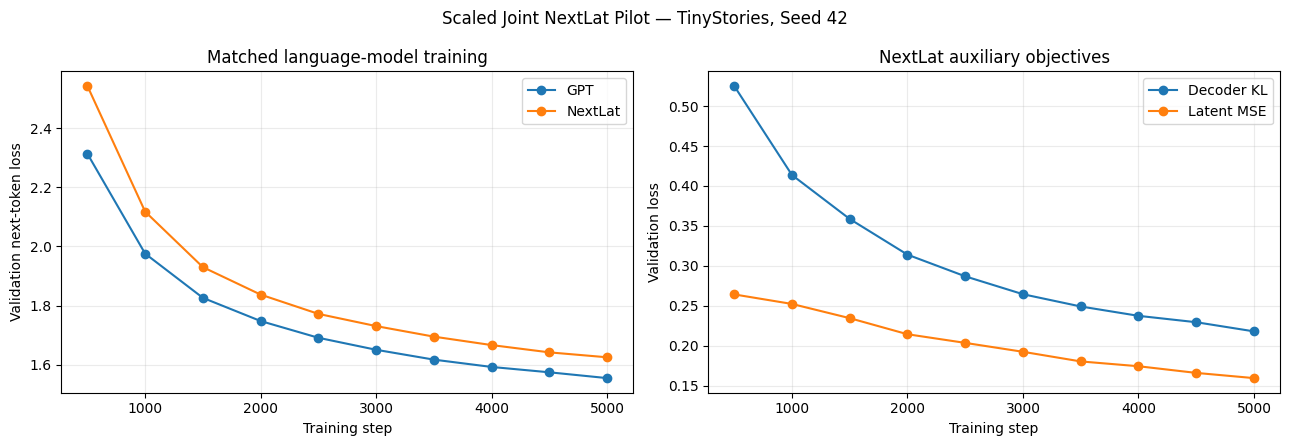

Saved figure:
/content/drive/MyDrive/ma2288_nextlat/research_v3/results/figures/joint_training_curves_seed42.png


In [41]:
import matplotlib.pyplot as plt

figure, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5),
)

axes[0].plot(
    matched_training_curve[
        "validation_checkpoint"
    ],
    matched_training_curve[
        "gpt_next_token_loss"
    ],
    marker="o",
    label="GPT",
)

axes[0].plot(
    matched_training_curve[
        "validation_checkpoint"
    ],
    matched_training_curve[
        "nextlat_next_token_loss"
    ],
    marker="o",
    label="NextLat",
)

axes[0].set_xlabel("Training step")
axes[0].set_ylabel(
    "Validation next-token loss"
)
axes[0].set_title(
    "Matched language-model training"
)
axes[0].grid(
    alpha=0.25,
)
axes[0].legend()

axes[1].plot(
    matched_training_curve[
        "validation_checkpoint"
    ],
    matched_training_curve[
        "nextlat_kl_loss"
    ],
    marker="o",
    label="Decoder KL",
)

axes[1].plot(
    matched_training_curve[
        "validation_checkpoint"
    ],
    matched_training_curve[
        "nextlat_mse_loss"
    ],
    marker="o",
    label="Latent MSE",
)

axes[1].set_xlabel("Training step")
axes[1].set_ylabel("Validation loss")
axes[1].set_title(
    "NextLat auxiliary objectives"
)
axes[1].grid(
    alpha=0.25,
)
axes[1].legend()

figure.suptitle(
    "Scaled Joint NextLat Pilot — TinyStories, Seed 42"
)

figure.tight_layout()

training_figure_path = (
    V3_FIGURE_DIR
    / "joint_training_curves_seed42.png"
)

figure.savefig(
    training_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved figure:")
print(training_figure_path)

In [42]:
from pathlib import Path
import os
import re
import pandas as pd

checkpoint_roots = {
    "GPT": Path(
        gpt_final_config.trainer.out_dir
    ),
    "NextLat": Path(
        nextlat_final_config.trainer.out_dir
    ),
}

checkpoint_rows = []

checkpoint_pattern = re.compile(
    r"ckpt_iter_(\d+)_([0-9.]+)\.pt$"
)

for model_name, root in checkpoint_roots.items():
    print("=" * 120)
    print(model_name)
    print("=" * 120)
    print("Root:", root)

    for path in sorted(root.rglob("*.pt")):
        relative_path = path.relative_to(root)
        size_mb = path.stat().st_size / 1024**2

        match = checkpoint_pattern.search(
            path.name
        )

        if match:
            checkpoint_type = "validation"
            iteration = int(match.group(1))
            validation_loss = float(
                match.group(2)
            )
        elif "recovery" in path.name:
            checkpoint_type = "recovery"
            iteration_match = re.search(
                r"iter_(\d+)",
                path.name,
            )
            iteration = (
                int(iteration_match.group(1))
                if iteration_match
                else None
            )
            validation_loss = None
        else:
            checkpoint_type = "other"
            iteration = None
            validation_loss = None

        checkpoint_rows.append(
            {
                "model": model_name,
                "path": str(path),
                "relative_path": str(
                    relative_path
                ),
                "checkpoint_type": (
                    checkpoint_type
                ),
                "iteration": iteration,
                "validation_loss": (
                    validation_loss
                ),
                "size_mb": size_mb,
            }
        )

        print(
            relative_path,
            f"| {size_mb:.3f} MB",
            f"| type={checkpoint_type}",
            f"| iter={iteration}",
            f"| val={validation_loss}",
        )

    latest_files = list(
        root.rglob("latest_ckpt")
    )

    for latest_file in latest_files:
        print()
        print("latest_ckpt file:")
        print(latest_file)

        try:
            print(
                "contents:",
                latest_file.read_text(
                    errors="replace"
                ),
            )
        except Exception as error:
            print(
                "Could not read latest_ckpt:",
                error,
            )

checkpoint_df = pd.DataFrame(
    checkpoint_rows
)

validation_checkpoint_df = (
    checkpoint_df[
        checkpoint_df[
            "checkpoint_type"
        ]
        == "validation"
    ]
    .copy()
)

selected_rows = (
    validation_checkpoint_df
    .sort_values(
        [
            "model",
            "validation_loss",
            "iteration",
        ],
        ascending=[
            True,
            True,
            False,
        ],
    )
    .groupby(
        "model",
        as_index=False,
    )
    .first()
)

print()
print("=" * 140)
print("SELECTED CHECKPOINTS")
print("=" * 140)
print(
    selected_rows[
        [
            "model",
            "iteration",
            "validation_loss",
            "size_mb",
            "path",
        ]
    ].to_string(
        index=False
    )
)

gpt_selected_checkpoint = Path(
    selected_rows.loc[
        selected_rows["model"] == "GPT",
        "path",
    ].iloc[0]
)

nextlat_selected_checkpoint = Path(
    selected_rows.loc[
        selected_rows["model"] == "NextLat",
        "path",
    ].iloc[0]
)

print()
print("GPT selected checkpoint:")
print(gpt_selected_checkpoint)

print()
print("NextLat selected checkpoint:")
print(nextlat_selected_checkpoint)

GPT
Root: /content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/gpt_pilot_5000_seed42
GPT_Scaled_5000Step_Seed42-seed42/ckpt_iter_1000_1.9757.pt | 40.420 MB | type=validation | iter=1000 | val=1.9757
GPT_Scaled_5000Step_Seed42-seed42/ckpt_iter_2500_1.6914.pt | 40.420 MB | type=validation | iter=2500 | val=1.6914
GPT_Scaled_5000Step_Seed42-seed42/ckpt_iter_5000_1.5551.pt | 40.420 MB | type=validation | iter=5000 | val=1.5551
GPT_Scaled_5000Step_Seed42-seed42/ckpt_iter_5001_1.5553.pt | 40.420 MB | type=validation | iter=5001 | val=1.5553
GPT_Scaled_5000Step_Seed42-seed42/recovery_ckpt_iter_5000.pt | 40.420 MB | type=recovery | iter=5000 | val=None

latest_ckpt file:
/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/gpt_pilot_5000_seed42/latest_ckpt
contents: /content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/gpt_pilot_5000_seed42/GPT_Scaled_5000Step_Seed42-seed42/ckpt_iter_5001_1.5553.pt
NextLat
Root: /content/drive/MyDrive/ma2288_nextlat/research_v3/checkp

In [43]:
import torch
import gc
from collections import OrderedDict


def summarize_checkpoint(
    checkpoint_path,
    model_name,
):
    print("=" * 130)
    print(
        f"{model_name} CHECKPOINT STRUCTURE"
    )
    print("=" * 130)
    print("Path:", checkpoint_path)

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )

    print("Top-level type:", type(checkpoint))

    if not isinstance(checkpoint, dict):
        raise TypeError(
            f"Unexpected checkpoint type: "
            f"{type(checkpoint)}"
        )

    print("Top-level keys:")
    for key in checkpoint.keys():
        value = checkpoint[key]

        if torch.is_tensor(value):
            print(
                f"- {key}: Tensor "
                f"shape={tuple(value.shape)} "
                f"dtype={value.dtype}"
            )

        elif isinstance(value, dict):
            print(
                f"- {key}: dict "
                f"with {len(value)} keys"
            )
            print(
                "  first keys:",
                list(value.keys())[:15],
            )

        elif isinstance(value, (list, tuple)):
            print(
                f"- {key}: "
                f"{type(value).__name__} "
                f"length={len(value)}"
            )

        else:
            short_value = str(value)

            if len(short_value) > 300:
                short_value = (
                    short_value[:300]
                    + "..."
                )

            print(
                f"- {key}: "
                f"{type(value).__name__} "
                f"value={short_value}"
            )

    state_dict_candidates = []

    for key, value in checkpoint.items():
        if not isinstance(value, dict):
            continue

        tensor_values = [
            item
            for item in value.values()
            if torch.is_tensor(item)
        ]

        if tensor_values:
            state_dict_candidates.append(
                {
                    "key": key,
                    "tensor_count": len(
                        tensor_values
                    ),
                    "total_elements": sum(
                        tensor.numel()
                        for tensor in tensor_values
                    ),
                    "first_tensor_keys": [
                        tensor_key
                        for tensor_key, tensor_value
                        in value.items()
                        if torch.is_tensor(
                            tensor_value
                        )
                    ][:15],
                }
            )

    print()
    print("Tensor-dictionary candidates:")

    for candidate in state_dict_candidates:
        print(candidate)

    result = {
        "model": model_name,
        "path": str(checkpoint_path),
        "top_level_keys": list(
            checkpoint.keys()
        ),
        "state_dict_candidates": (
            state_dict_candidates
        ),
    }

    del checkpoint
    gc.collect()

    return result


gpt_checkpoint_summary = (
    summarize_checkpoint(
        gpt_selected_checkpoint,
        "GPT",
    )
)

print()

nextlat_checkpoint_summary = (
    summarize_checkpoint(
        nextlat_selected_checkpoint,
        "NextLat",
    )
)

GPT CHECKPOINT STRUCTURE
Path: /content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/gpt_pilot_5000_seed42/GPT_Scaled_5000Step_Seed42-seed42/ckpt_iter_5000_1.5551.pt
Top-level type: <class 'dict'>
Top-level keys:
- model: dict with 27 keys
  first keys: ['token_embedding.weight', 'transformer.blocks.0.ln_1.weight', 'transformer.blocks.0.attn.c_attn.weight', 'transformer.blocks.0.attn.c_proj.weight', 'transformer.blocks.0.ln_2.weight', 'transformer.blocks.0.mlp.up.gate_up.weight', 'transformer.blocks.0.mlp.down.weight', 'transformer.blocks.1.ln_1.weight', 'transformer.blocks.1.attn.c_attn.weight', 'transformer.blocks.1.attn.c_proj.weight', 'transformer.blocks.1.ln_2.weight', 'transformer.blocks.1.mlp.up.gate_up.weight', 'transformer.blocks.1.mlp.down.weight', 'transformer.blocks.2.ln_1.weight', 'transformer.blocks.2.attn.c_attn.weight']
- optimizer: dict with 2 keys
  first keys: ['state', 'param_groups']
- training_steps: int value=5000
- lr_scheduler_state: dict with 7 keys
  

In [44]:
from pathlib import Path
import json

gpt_matched_rows = (
    validation_checkpoint_df[
        (validation_checkpoint_df["model"] == "GPT")
        & (validation_checkpoint_df["iteration"] == 5000)
    ]
)

nextlat_matched_rows = (
    validation_checkpoint_df[
        (validation_checkpoint_df["model"] == "NextLat")
        & (validation_checkpoint_df["iteration"] == 5000)
    ]
)

if len(gpt_matched_rows) != 1:
    raise RuntimeError(
        "Expected exactly one GPT iter-5000 checkpoint."
    )

if len(nextlat_matched_rows) != 1:
    raise RuntimeError(
        "Expected exactly one NextLat iter-5000 checkpoint."
    )

gpt_matched_checkpoint = Path(
    gpt_matched_rows["path"].iloc[0]
)

nextlat_matched_checkpoint = Path(
    nextlat_matched_rows["path"].iloc[0]
)

nextlat_final_sensitivity_checkpoint = (
    nextlat_selected_checkpoint
)

print("=" * 130)
print("PRIMARY MATCHED CHECKPOINTS")
print("=" * 130)

print("GPT:")
print(gpt_matched_checkpoint)

print()
print("NextLat:")
print(nextlat_matched_checkpoint)

print()
print("Both training iterations: 5000")

print()
print("=" * 130)
print("SECONDARY SENSITIVITY CHECKPOINT")
print("=" * 130)

print("NextLat final iter-5001:")
print(nextlat_final_sensitivity_checkpoint)

assert "iter_5000_" in gpt_matched_checkpoint.name
assert "iter_5000_" in nextlat_matched_checkpoint.name
assert "iter_5001_" in (
    nextlat_final_sensitivity_checkpoint.name
)

checkpoint_selection_metadata = {
    "primary_comparison": {
        "gpt": {
            "iteration": 5000,
            "path": str(
                gpt_matched_checkpoint
            ),
        },
        "nextlat": {
            "iteration": 5000,
            "path": str(
                nextlat_matched_checkpoint
            ),
        },
    },
    "secondary_sensitivity": {
        "nextlat_final": {
            "iteration": 5001,
            "path": str(
                nextlat_final_sensitivity_checkpoint
            ),
        }
    },
    "selection_reason": (
        "Primary comparison uses equal training iterations. "
        "The iter-5001 NextLat checkpoint is retained only "
        "for a secondary sensitivity check."
    ),
}

checkpoint_selection_path = (
    V3_METADATA_DIR
    / "checkpoint_selection_seed42.json"
)

checkpoint_selection_path.write_text(
    json.dumps(
        checkpoint_selection_metadata,
        indent=2,
    ),
    encoding="utf-8",
)

print()
print("Saved checkpoint selection metadata:")
print(checkpoint_selection_path)

PRIMARY MATCHED CHECKPOINTS
GPT:
/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/gpt_pilot_5000_seed42/GPT_Scaled_5000Step_Seed42-seed42/ckpt_iter_5000_1.5551.pt

NextLat:
/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/nextlat_pilot_5000_seed42/NextLat_Scaled_5000Step_Seed42-seed42/ckpt_iter_5000_2.0028.pt

Both training iterations: 5000

SECONDARY SENSITIVITY CHECKPOINT
NextLat final iter-5001:
/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/nextlat_pilot_5000_seed42/NextLat_Scaled_5000Step_Seed42-seed42/ckpt_iter_5001_1.9995.pt

Saved checkpoint selection metadata:
/content/drive/MyDrive/ma2288_nextlat/research_v3/results/metadata/checkpoint_selection_seed42.json


In [45]:
import torch
import gc


def inspect_model_state(
    checkpoint_path,
    model_name,
):
    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )

    model_state = checkpoint["model"]

    print("=" * 140)
    print(f"{model_name} MODEL STATE")
    print("=" * 140)

    total_parameters = 0

    for index, (key, tensor) in enumerate(
        model_state.items()
    ):
        num_parameters = tensor.numel()
        total_parameters += num_parameters

        print(
            f"[{index:02d}] "
            f"{key:65s} "
            f"shape={str(tuple(tensor.shape)):22s} "
            f"dtype={str(tensor.dtype):15s} "
            f"params={num_parameters:,}"
        )

    print()
    print(
        f"{model_name} tensor count:",
        len(model_state),
    )
    print(
        f"{model_name} parameter count:",
        f"{total_parameters:,}",
    )

    result = {
        "keys": list(model_state.keys()),
        "tensor_count": len(model_state),
        "parameter_count": total_parameters,
    }

    del checkpoint
    del model_state
    gc.collect()

    return result


gpt_state_summary = inspect_model_state(
    gpt_matched_checkpoint,
    "GPT",
)

print()

nextlat_state_summary = inspect_model_state(
    nextlat_matched_checkpoint,
    "NextLat",
)

gpt_key_set = set(
    gpt_state_summary["keys"]
)

nextlat_key_set = set(
    nextlat_state_summary["keys"]
)

print()
print("=" * 120)
print("NEXTLAT-ONLY STATE KEYS")
print("=" * 120)

nextlat_only_keys = sorted(
    nextlat_key_set - gpt_key_set
)

for key in nextlat_only_keys:
    print("-", key)

print()
print(
    "Number of NextLat-only keys:",
    len(nextlat_only_keys),
)

GPT MODEL STATE
[00] token_embedding.weight                                            shape=(1000, 256)            dtype=torch.float32   params=256,000
[01] transformer.blocks.0.ln_1.weight                                  shape=(256,)                 dtype=torch.float32   params=256
[02] transformer.blocks.0.attn.c_attn.weight                           shape=(768, 256)             dtype=torch.float32   params=196,608
[03] transformer.blocks.0.attn.c_proj.weight                           shape=(256, 256)             dtype=torch.float32   params=65,536
[04] transformer.blocks.0.ln_2.weight                                  shape=(256,)                 dtype=torch.float32   params=256
[05] transformer.blocks.0.mlp.up.gate_up.weight                        shape=(1280, 256)            dtype=torch.float32   params=327,680
[06] transformer.blocks.0.mlp.down.weight                              shape=(256, 640)             dtype=torch.float32   params=163,840
[07] transformer.blocks.1.ln_1.wei

In [46]:
import inspect
import torch.nn as nn

import models.model_gpt as model_gpt_module
import models.model_nextlat as model_nextlat_module


def inspect_module_classes(
    module,
    module_name,
):
    print("=" * 140)
    print(module_name)
    print("=" * 140)

    for name, value in vars(module).items():
        if not inspect.isclass(value):
            continue

        if value.__module__ != module.__name__:
            continue

        print()
        print(f"Class: {name}")

        try:
            print(
                "Constructor:",
                inspect.signature(value),
            )
        except Exception as error:
            print(
                "Constructor signature unavailable:",
                error,
            )

        if hasattr(value, "forward"):
            try:
                print(
                    "Forward:",
                    inspect.signature(
                        value.forward
                    ),
                )
            except Exception as error:
                print(
                    "Forward signature unavailable:",
                    error,
                )

        if (
            issubclass(value, nn.Module)
            and value is not nn.Module
        ):
            print("Is nn.Module: True")


inspect_module_classes(
    model_gpt_module,
    "models.model_gpt",
)

print()

inspect_module_classes(
    model_nextlat_module,
    "models.model_nextlat",
)

models.model_gpt

Class: GPTConfig
Constructor: (block_size: int = 1024, vocab_size: int = 50304, n_layer: int = 12, n_head: int = 12, n_embd: int = 768, dropout: float = 0.0, bias: bool = False, context_length: int = 0, goal_range: Tuple[int] = (25, 75), eos_token_id: int = -1, fim_token_id: int = -1, is_fim_mode: bool = False, compute_hidden_state_rank: bool = False, use_fused: bool = False) -> None

Class: CausalSelfAttention
Constructor: (config: models.model_gpt.GPTConfig)
Forward: (self, x: torch.Tensor, mask: Optional[torch.Tensor] = None, rope: Optional[Tuple[torch.Tensor, torch.Tensor]] = None) -> torch.Tensor
Is nn.Module: True

Class: MLP
Constructor: (config: models.model_gpt.GPTConfig)
Forward: (self, x: torch.Tensor) -> torch.Tensor
Is nn.Module: True

Class: Block
Constructor: (config: models.model_gpt.GPTConfig)
Forward: (self, x: torch.Tensor, mask: Optional[torch.Tensor] = None, rope: Optional[Tuple[torch.Tensor, torch.Tensor]] = None) -> torch.Tensor
Is nn.Module: Tr

In [47]:
from dataclasses import fields, is_dataclass

config_classes = []

for module in [
    model_gpt_module,
    model_nextlat_module,
]:
    for name, value in vars(module).items():
        if (
            inspect.isclass(value)
            and is_dataclass(value)
            and value.__module__ == module.__name__
        ):
            config_classes.append(
                (name, value)
            )

for class_name, config_class in config_classes:
    print("=" * 120)
    print(class_name)
    print("=" * 120)

    for field in fields(config_class):
        print(
            f"{field.name:30s}",
            f"default={field.default}",
        )

    print()

GPTConfig
block_size                     default=1024
vocab_size                     default=50304
n_layer                        default=12
n_head                         default=12
n_embd                         default=768
dropout                        default=0.0
bias                           default=False
context_length                 default=0
goal_range                     default=(25, 75)
eos_token_id                   default=-1
fim_token_id                   default=-1
is_fim_mode                    default=False
compute_hidden_state_rank      default=False
use_fused                      default=False

NextLatConfig
block_size                     default=1024
vocab_size                     default=50304
n_layer                        default=12
n_head                         default=12
n_embd                         default=768
dropout                        default=0.0
bias                           default=False
context_length                 default=0
eos_token_id      

In [48]:
import inspect

from models.model_gpt import (
    GPT,
    GPTConfig,
)
from models.model_nextlat import (
    NextLat,
    NextLatConfig,
)


def inspect_wrapper(
    wrapper_class,
    class_name,
):
    print("=" * 140)
    print(class_name)
    print("=" * 140)

    print("MRO:")
    for cls in wrapper_class.__mro__:
        print("-", cls)

    print()
    print("Public callable methods:")

    for method_name in dir(wrapper_class):
        if method_name.startswith("_"):
            continue

        method = getattr(
            wrapper_class,
            method_name,
        )

        if not callable(method):
            continue

        try:
            signature = inspect.signature(
                method
            )
        except Exception:
            signature = "signature unavailable"

        print(
            f"{method_name:35s}",
            signature,
        )

    important_methods = [
        "__init__",
        "state_dict",
        "load_state_dict",
        "setup_fabric",
        "train",
        "eval",
        "compute_loss",
        "generate",
    ]

    for method_name in important_methods:
        if not hasattr(
            wrapper_class,
            method_name,
        ):
            continue

        print()
        print(
            "-" * 100
        )
        print(
            f"SOURCE: {class_name}."
            f"{method_name}"
        )
        print(
            "-" * 100
        )

        try:
            print(
                inspect.getsource(
                    getattr(
                        wrapper_class,
                        method_name,
                    )
                )
            )
        except Exception as error:
            print(
                "Source unavailable:",
                error,
            )


inspect_wrapper(
    GPT,
    "GPT",
)

print()

inspect_wrapper(
    NextLat,
    "NextLat",
)

GPT
MRO:
- <class 'models.model_gpt.GPT'>
- <class 'models.model_base.ModelBase'>
- <class 'object'>

Public callable methods:
compile                             (self)
compute_hidden_state_rank           (self, hidden_states: torch.Tensor, loss_div: int = 1) -> dict
compute_loss                        (self, batch: torch.Tensor, backpropagate: bool, no_sync: bool = False, loss_div: int = 1, **kwargs) -> torch.Tensor
configure_optimizers                (self, weight_decay: float, learning_rate: float, betas: Tuple[float, float], use_fused: Optional[bool] = None, optimizer_type: str = 'adam', mu: float = 0.95, nesterov: bool = True, adjust_lr_fn: Optional[str] = None)
crop_block_size                     (self, block_size: int)
estimate_mfu                        (self, fwdbwd_per_iter: int, dt: float) -> float
eval                                (self)
evaluation_loss                     (self, batch: torch.Tensor, prefix_end_index: torch.Tensor, suffix_start_index: torch.Tensor) -> to

In [49]:
import subprocess
import os

os.chdir(OFFICIAL_REPO_DIR)

patterns = (
    "torch.load|load_state_dict|"
    "setup_fabric|checkpoint_path|"
    "GPTConfig|NextLatConfig|"
    "return_hidden_states"
)

search_command = [
    "rg",
    "-n",
    patterns,
    "eval",
    "train_probe.py",
    "core_train.py",
    "models",
]

search_result = subprocess.run(
    search_command,
    text=True,
    capture_output=True,
)

print("=" * 140)
print("OFFICIAL CHECKPOINT / EVALUATION REFERENCES")
print("=" * 140)
print("Return code:", search_result.returncode)
print()
print(search_result.stdout)
print(search_result.stderr)

OFFICIAL CHECKPOINT / EVALUATION REFERENCES
Return code: 0

core_train.py:22:from models.model_gpt import GPT, GPTConfig, Block
core_train.py:23:from models.model_nextlat import NextLat, NextLatConfig
core_train.py:34:    checkpoint_path: Optional[str] = None,
core_train.py:47:        ModelConfigClass = NextLatConfig
core_train.py:56:        ModelConfigClass = GPTConfig
core_train.py:130:    if checkpoint_path:
core_train.py:132:            checkpoint_path
core_train.py:133:        ), f"Checkpoint file {checkpoint_path} does not exist"
core_train.py:147:                checkpoint_path = f.read().strip()
core_train.py:149:                checkpoint_path
core_train.py:150:            ), f"Checkpoint file {checkpoint_path} does not exist"
core_train.py:151:            fabric.print(f"Resuming from recovery checkpoint {checkpoint_path}")
core_train.py:156:                checkpoint_path = f.read().strip()
core_train.py:158:                checkpoint_path
core_train.py:159:            ), f"C

In [50]:
from pathlib import Path
import re

candidate_files = [
    OFFICIAL_REPO_DIR
    / "eval"
    / "eval_speculative_checkpoints.py",
    OFFICIAL_REPO_DIR
    / "train_probe.py",
    OFFICIAL_REPO_DIR
    / "core_train.py",
]

keywords = [
    "torch.load",
    "load_state_dict",
    "checkpoint_path",
    "setup_fabric",
    "return_hidden_states",
]


def print_keyword_context(
    path,
    keyword,
    before=12,
    after=30,
):
    if not path.exists():
        return

    lines = path.read_text(
        errors="replace"
    ).splitlines()

    matching_indices = [
        index
        for index, line in enumerate(lines)
        if keyword in line
    ]

    for index in matching_indices:
        start = max(
            0,
            index - before,
        )
        end = min(
            len(lines),
            index + after + 1,
        )

        print("=" * 140)
        print(
            "FILE:",
            path.relative_to(
                OFFICIAL_REPO_DIR
            ),
        )
        print(
            "KEYWORD:",
            keyword,
        )
        print(
            "AROUND LINE:",
            index + 1,
        )
        print("=" * 140)

        for line_index in range(
            start,
            end,
        ):
            print(
                f"{line_index + 1:04d}: "
                f"{lines[line_index]}"
            )

        print()


for path in candidate_files:
    for keyword in keywords:
        print_keyword_context(
            path,
            keyword,
        )

FILE: eval/eval_speculative_checkpoints.py
KEYWORD: checkpoint_path
AROUND LINE: 894
0882:             tokenizer, "convert_tokens_to_ids", lambda x: None
0883:         ),
0884:     )
0885: 
0886:     for ckpt in local_checkpoints:
0887:         step = _extract_step(ckpt)
0888:         print(f"\n[rank {rank}] === Evaluating checkpoint step={step}: {ckpt.name} ===")
0889:         model_wrapper = initialize_model(
0890:             fabric=fabric,
0891:             config=cfg,
0892:             tokenizer=init_tok,
0893:             initialize_optimizer=False,
0894:             checkpoint_path=str(ckpt),
0895:         )
0896:         model_wrapper.eval()
0897: 
0898:         if not isinstance(model_wrapper, SpeculativeModel):
0899:             print(
0900:                 f"Skipping checkpoint step={step}: model does not implement "
0901:                 "SpeculativeModel interface."
0902:             )
0903:             del model_wrapper
0904:             if device.type == "cuda":
0905:   

In [51]:
import gc
import torch

from models.model_gpt import (
    GPT,
    GPTConfig,
)
from models.model_nextlat import (
    NextLat,
    NextLatConfig,
)

device = torch.device("cuda")

gpt_eval_config = GPTConfig(
    block_size=256,
    vocab_size=1000,
    n_layer=4,
    n_head=4,
    n_embd=256,
    dropout=0.0,
    bias=False,
    context_length=0,
    goal_range=(25, 75),
    eos_token_id=1,
    fim_token_id=-1,
    is_fim_mode=False,
    compute_hidden_state_rank=False,
    use_fused=False,
)

nextlat_eval_config = NextLatConfig(
    block_size=256,
    vocab_size=1000,
    n_layer=4,
    n_head=4,
    n_embd=256,
    dropout=0.0,
    bias=False,
    context_length=0,
    eos_token_id=1,
    compute_hidden_state_rank=False,
    use_fused=False,
    lambda_kl=1.0,
    lambda_mse=1.0,
    lambda_ce=0.0,
    mtp_horizon=1,
    proj_factor=1.3,
)

gpt_checkpoint = torch.load(
    gpt_matched_checkpoint,
    map_location="cpu",
    weights_only=False,
)

nextlat_checkpoint = torch.load(
    nextlat_matched_checkpoint,
    map_location="cpu",
    weights_only=False,
)

gpt_wrapper = GPT(
    gpt_eval_config
)

nextlat_wrapper = NextLat(
    nextlat_eval_config
)

gpt_load_result = (
    gpt_wrapper.model.load_state_dict(
        gpt_checkpoint["model"],
        strict=True,
    )
)

nextlat_load_result = (
    nextlat_wrapper.model.load_state_dict(
        nextlat_checkpoint["model"],
        strict=True,
    )
)

print("=" * 110)
print("STATE-DICT LOAD RESULTS")
print("=" * 110)

print("GPT:")
print(gpt_load_result)

print()
print("NextLat:")
print(nextlat_load_result)

assert len(
    gpt_load_result.missing_keys
) == 0

assert len(
    gpt_load_result.unexpected_keys
) == 0

assert len(
    nextlat_load_result.missing_keys
) == 0

assert len(
    nextlat_load_result.unexpected_keys
) == 0

gpt_wrapper.model.to(device)
nextlat_wrapper.model.to(device)

gpt_wrapper.eval()
nextlat_wrapper.eval()

del gpt_checkpoint
del nextlat_checkpoint
gc.collect()
torch.cuda.empty_cache()

gpt_parameter_count = sum(
    parameter.numel()
    for parameter
    in gpt_wrapper.model.parameters()
)

nextlat_parameter_count = sum(
    parameter.numel()
    for parameter
    in nextlat_wrapper.model.parameters()
)

print()
print("=" * 110)
print("LOADED MODEL SUMMARY")
print("=" * 110)

print(
    "GPT parameters:",
    f"{gpt_parameter_count:,}",
)

print(
    "NextLat parameters:",
    f"{nextlat_parameter_count:,}",
)

print(
    "Additional NextLat parameters:",
    f"{nextlat_parameter_count - gpt_parameter_count:,}",
)

print(
    "GPT training steps:",
    5000,
)

print(
    "NextLat training steps:",
    5000,
)

print(
    "GPU allocated GB:",
    round(
        torch.cuda.memory_allocated()
        / 1024**3,
        4,
    ),
)

print("Strict checkpoint loading passed.")

STATE-DICT LOAD RESULTS
GPT:
<All keys matched successfully>

NextLat:
<All keys matched successfully>

LOADED MODEL SUMMARY
GPT parameters: 3,528,960
NextLat parameters: 4,430,592
Additional NextLat parameters: 901,632
GPT training steps: 5000
NextLat training steps: 5000
GPU allocated GB: 0.0297
Strict checkpoint loading passed.


In [52]:
import random
import numpy as np
import lightning as L

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

evaluation_fabric = L.Fabric(
    accelerator="cuda",
    devices=1,
    precision="bf16-mixed",
)

evaluation_fabric.launch()

evaluation_data_module = (
    TinyStoriesDataModule(
        fabric=evaluation_fabric,
        config=merged_gpt_config,
        data_path=str(
            OFFICIAL_REPO_DIR
            / "data"
            / "tinystories"
        ),
    )
)

validation_loader = (
    evaluation_data_module
    .val_dataloader()
)

validation_iterator = iter(
    validation_loader
)

validation_batch_dict = next(
    validation_iterator
)

validation_tokens = (
    evaluation_data_module
    .prepare_batch(
        validation_batch_dict
    )
)

print("Validation token shape:")
print(validation_tokens.shape)

print("Validation token dtype:")
print(validation_tokens.dtype)

print("Validation token device:")
print(validation_tokens.device)

print(
    "Token range:",
    int(validation_tokens.min()),
    int(validation_tokens.max()),
)

assert tuple(
    validation_tokens.shape
) == (16, 256)

assert validation_tokens.dtype == torch.int64
assert validation_tokens.min() >= 0
assert validation_tokens.max() < 1000

print("Validation batch passed.")

INFO: Using bfloat16 Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using bfloat16 Automatic Mixed Precision (AMP)


Generating train split:   0%|          | 0/2708167 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/27544 [00:00<?, ? examples/s]

Validation token shape:
torch.Size([16, 256])
Validation token dtype:
torch.int64
Validation token device:
cuda:0
Token range: 1 998
Validation batch passed.


In [1]:
import os

# Must be set before the first CUDA operation.
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

from google.colab import drive
drive.mount(
    "/content/drive",
    force_remount=False,
)

from pathlib import Path
import sys
import gc
import random
import numpy as np
import torch
import lightning as L
from omegaconf import OmegaConf

PROJECT_DIR = Path(
    "/content/drive/MyDrive/ma2288_nextlat"
)
V3_DIR = PROJECT_DIR / "research_v3"

V3_CHECKPOINT_DIR = (
    V3_DIR / "checkpoints"
)
V3_RESULTS_DIR = (
    V3_DIR / "results"
)
V3_TABLE_DIR = (
    V3_RESULTS_DIR / "tables"
)
V3_FIGURE_DIR = (
    V3_RESULTS_DIR / "figures"
)
V3_METADATA_DIR = (
    V3_RESULTS_DIR / "metadata"
)

OFFICIAL_REPO_DIR = Path(
    "/content/NextLat"
)

if not OFFICIAL_REPO_DIR.exists():
    raise FileNotFoundError(
        "/content/NextLat is missing. "
        "Rerun the official repository clone Cell."
    )

os.chdir(OFFICIAL_REPO_DIR)

if str(OFFICIAL_REPO_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(OFFICIAL_REPO_DIR),
    )

from models.model_gpt import (
    GPT,
    GPTConfig,
)
from models.model_nextlat import (
    NextLat,
    NextLatConfig,
)
from data.tinystories import (
    TinyStoriesDataModule,
)

gpt_checkpoint_candidates = list(
    V3_CHECKPOINT_DIR.rglob(
        "GPT_Scaled_5000Step_Seed42-seed42/"
        "ckpt_iter_5000_1.5551.pt"
    )
)

nextlat_checkpoint_candidates = list(
    V3_CHECKPOINT_DIR.rglob(
        "NextLat_Scaled_5000Step_Seed42-seed42/"
        "ckpt_iter_5000_2.0028.pt"
    )
)

assert len(
    gpt_checkpoint_candidates
) == 1

assert len(
    nextlat_checkpoint_candidates
) == 1

gpt_matched_checkpoint = (
    gpt_checkpoint_candidates[0]
)
nextlat_matched_checkpoint = (
    nextlat_checkpoint_candidates[0]
)

print("GPT checkpoint:")
print(gpt_matched_checkpoint)

print()
print("NextLat checkpoint:")
print(nextlat_matched_checkpoint)

gpt_eval_config = GPTConfig(
    block_size=256,
    vocab_size=1000,
    n_layer=4,
    n_head=4,
    n_embd=256,
    dropout=0.0,
    bias=False,
    context_length=0,
    goal_range=(25, 75),
    eos_token_id=1,
    fim_token_id=-1,
    is_fim_mode=False,
    compute_hidden_state_rank=False,
    use_fused=False,
)

nextlat_eval_config = NextLatConfig(
    block_size=256,
    vocab_size=1000,
    n_layer=4,
    n_head=4,
    n_embd=256,
    dropout=0.0,
    bias=False,
    context_length=0,
    eos_token_id=1,
    compute_hidden_state_rank=False,
    use_fused=False,
    lambda_kl=1.0,
    lambda_mse=1.0,
    lambda_ce=0.0,
    mtp_horizon=1,
    proj_factor=1.3,
)

gpt_wrapper = GPT(
    gpt_eval_config
)
nextlat_wrapper = NextLat(
    nextlat_eval_config
)

gpt_checkpoint = torch.load(
    gpt_matched_checkpoint,
    map_location="cpu",
    weights_only=False,
)

nextlat_checkpoint = torch.load(
    nextlat_matched_checkpoint,
    map_location="cpu",
    weights_only=False,
)

gpt_load_result = (
    gpt_wrapper.model.load_state_dict(
        gpt_checkpoint["model"],
        strict=True,
    )
)

nextlat_load_result = (
    nextlat_wrapper.model.load_state_dict(
        nextlat_checkpoint["model"],
        strict=True,
    )
)

print()
print("GPT load result:")
print(gpt_load_result)

print()
print("NextLat load result:")
print(nextlat_load_result)

assert not gpt_load_result.missing_keys
assert not gpt_load_result.unexpected_keys
assert not nextlat_load_result.missing_keys
assert not nextlat_load_result.unexpected_keys

device = torch.device("cuda")

gpt_wrapper.model.to(device)
nextlat_wrapper.model.to(device)

gpt_wrapper.eval()
nextlat_wrapper.eval()

del gpt_checkpoint
del nextlat_checkpoint
gc.collect()
torch.cuda.empty_cache()

print()
print("Models loaded successfully.")
print(
    "GPU:",
    torch.cuda.get_device_name(0),
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPT checkpoint:
/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/gpt_pilot_5000_seed42/GPT_Scaled_5000Step_Seed42-seed42/ckpt_iter_5000_1.5551.pt

NextLat checkpoint:
/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/nextlat_pilot_5000_seed42/NextLat_Scaled_5000Step_Seed42-seed42/ckpt_iter_5000_2.0028.pt

GPT load result:
<All keys matched successfully>

NextLat load result:
<All keys matched successfully>

Models loaded successfully.
GPU: NVIDIA L4


In [2]:
gpt_final_config_path = (
    V3_DIR
    / "configs"
    / "tinystories_scaled_gpt.yaml"
)

defaults_config = OmegaConf.load(
    OFFICIAL_REPO_DIR / "defaults.yaml"
)

merged_gpt_config = OmegaConf.merge(
    defaults_config,
    OmegaConf.load(
        gpt_final_config_path
    ),
)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

evaluation_fabric = L.Fabric(
    accelerator="cuda",
    devices=1,
    precision="bf16-mixed",
)

evaluation_fabric.launch()

evaluation_data_module = (
    TinyStoriesDataModule(
        fabric=evaluation_fabric,
        config=merged_gpt_config,
        data_path=str(
            OFFICIAL_REPO_DIR
            / "data"
            / "tinystories"
        ),
    )
)

validation_loader = (
    evaluation_data_module
    .val_dataloader()
)

validation_batch_dict = next(
    iter(validation_loader)
)

validation_tokens = (
    evaluation_data_module
    .prepare_batch(
        validation_batch_dict
    )
)

# Validate on CPU before any embedding/CE kernel.
validation_tokens_cpu = (
    validation_tokens.detach().cpu()
)

print(
    "Validation shape:",
    tuple(validation_tokens_cpu.shape),
)
print(
    "Validation dtype:",
    validation_tokens_cpu.dtype,
)
print(
    "Validation min token:",
    int(validation_tokens_cpu.min()),
)
print(
    "Validation max token:",
    int(validation_tokens_cpu.max()),
)

assert tuple(
    validation_tokens_cpu.shape
) == (16, 256)
assert (
    validation_tokens_cpu.dtype
    == torch.int64
)
assert int(
    validation_tokens_cpu.min()
) >= 0
assert int(
    validation_tokens_cpu.max()
) < 1000

print("CPU token-range validation passed.")

INFO: Using bfloat16 Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using bfloat16 Automatic Mixed Precision (AMP)
INFO: You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:lightning.pytorch.utilities.rank_zero:You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


Generating train split:   0%|          | 0/2708167 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/27544 [00:00<?, ? examples/s]

Validation shape: (16, 256)
Validation dtype: torch.int64
Validation min token: 1
Validation max token: 998
CPU token-range validation passed.


In [9]:
# Cell 61 — Correct GPT / NextLat forward API validation

import torch
import torch.nn.functional as F

# validation_tokens shape: [batch, 256]
full_tokens = validation_tokens

# GPT predicts each next token from the preceding 255 tokens.
gpt_inputs = full_tokens[:, :-1]
shared_targets = full_tokens[:, 1:]

# Official NextLat loss path expects the full 256-token sequence,
# then internally removes the final hidden position.
nextlat_inputs = full_tokens

print("=" * 110)
print("INPUT SHAPES")
print("=" * 110)
print("GPT input:", tuple(gpt_inputs.shape))
print("NextLat input:", tuple(nextlat_inputs.shape))
print("Shared targets:", tuple(shared_targets.shape))

assert gpt_inputs.shape == shared_targets.shape
assert nextlat_inputs.shape[1] == shared_targets.shape[1] + 1


# ------------------------------------------------------------------
# 1. GPT: official loss and hidden states
# ------------------------------------------------------------------

with torch.inference_mode():
    gpt_official_loss, gpt_hidden = gpt_wrapper.model(
        gpt_inputs,
        targets=shared_targets,
        return_hidden_states=True,
    )

    gpt_logits, gpt_hidden_without_targets = gpt_wrapper.model(
        gpt_inputs,
        return_hidden_states=True,
    )


# ------------------------------------------------------------------
# 2. NextLat: representations
#
# With return_hidden_states=True, NextLat returns:
#   token embeddings, transformer hidden states
# It does NOT return logits or loss.
# ------------------------------------------------------------------

with torch.inference_mode():
    nextlat_token_embeds, nextlat_hidden = nextlat_wrapper.model(
        nextlat_inputs,
        return_hidden_states=True,
    )


# ------------------------------------------------------------------
# 3. NextLat: official loss
#
# Do not set return_hidden_states=True here.
# ------------------------------------------------------------------

with torch.inference_mode():
    nextlat_official_loss = nextlat_wrapper.model(
        nextlat_inputs,
        targets=shared_targets,
    )


# ------------------------------------------------------------------
# 4. NextLat: logits
#
# Do not set return_hidden_states=True here either.
# ------------------------------------------------------------------

with torch.inference_mode():
    nextlat_full_logits = nextlat_wrapper.model(nextlat_inputs)

# The official loss uses only positions 0...254.
nextlat_logits = nextlat_full_logits[:, :-1]


# ------------------------------------------------------------------
# 5. Manual cross-entropy checks
# ------------------------------------------------------------------

vocab_size = gpt_logits.shape[-1]

gpt_manual_loss = F.cross_entropy(
    gpt_logits.float().reshape(-1, vocab_size),
    shared_targets.reshape(-1),
)

nextlat_manual_loss = F.cross_entropy(
    nextlat_logits.float().reshape(-1, vocab_size),
    shared_targets.reshape(-1),
)


# ------------------------------------------------------------------
# 6. Diagnostics
# ------------------------------------------------------------------

print("\n" + "=" * 110)
print("OUTPUT SHAPES")
print("=" * 110)

print("GPT logits:", tuple(gpt_logits.shape))
print("GPT hidden:", tuple(gpt_hidden.shape))

print("NextLat full logits:", tuple(nextlat_full_logits.shape))
print("NextLat comparison logits:", tuple(nextlat_logits.shape))
print("NextLat token embeddings:", tuple(nextlat_token_embeds.shape))
print("NextLat hidden:", tuple(nextlat_hidden.shape))


print("\n" + "=" * 110)
print("LOSS CHECK")
print("=" * 110)

print(
    "GPT official loss:",
    gpt_official_loss.detach().float().cpu().item(),
)
print(
    "GPT manual loss:",
    gpt_manual_loss.detach().float().cpu().item(),
)
print(
    "GPT absolute difference:",
    abs(
        gpt_official_loss.detach().float().cpu().item()
        - gpt_manual_loss.detach().float().cpu().item()
    ),
)

print(
    "\nNextLat official loss:",
    nextlat_official_loss.detach().float().cpu().item(),
)
print(
    "NextLat manual loss:",
    nextlat_manual_loss.detach().float().cpu().item(),
)
print(
    "NextLat absolute difference:",
    abs(
        nextlat_official_loss.detach().float().cpu().item()
        - nextlat_manual_loss.detach().float().cpu().item()
    ),
)


# ------------------------------------------------------------------
# 7. Assertions
# ------------------------------------------------------------------

assert gpt_official_loss.ndim == 0
assert nextlat_official_loss.ndim == 0

assert gpt_logits.shape == (
    full_tokens.shape[0],
    full_tokens.shape[1] - 1,
    vocab_size,
)

assert nextlat_logits.shape == gpt_logits.shape

assert gpt_hidden.shape == (
    full_tokens.shape[0],
    full_tokens.shape[1] - 1,
    256,
)

assert nextlat_hidden.shape == (
    full_tokens.shape[0],
    full_tokens.shape[1],
    256,
)

assert nextlat_token_embeds.shape == nextlat_hidden.shape

assert torch.isfinite(gpt_official_loss)
assert torch.isfinite(nextlat_official_loss)
assert torch.isfinite(gpt_logits).all()
assert torch.isfinite(nextlat_logits).all()
assert torch.isfinite(gpt_hidden).all()
assert torch.isfinite(nextlat_hidden).all()

gpt_hidden_difference = (
    gpt_hidden.float() - gpt_hidden_without_targets.float()
).abs().max().item()

print("\nGPT hidden difference with/without targets:", gpt_hidden_difference)

assert gpt_hidden_difference < 1e-4

print("\nCorrect GPT and NextLat forward checks passed.")

INPUT SHAPES
GPT input: (16, 255)
NextLat input: (16, 256)
Shared targets: (16, 255)

OUTPUT SHAPES
GPT logits: (16, 255, 1000)
GPT hidden: (16, 255, 256)
NextLat full logits: (16, 256, 1000)
NextLat comparison logits: (16, 255, 1000)
NextLat token embeddings: (16, 256, 256)
NextLat hidden: (16, 256, 256)

LOSS CHECK
GPT official loss: 1.5979644060134888
GPT manual loss: 1.5979644060134888
GPT absolute difference: 0.0

NextLat official loss: 1.6706292629241943
NextLat manual loss: 1.6706292629241943
NextLat absolute difference: 0.0

GPT hidden difference with/without targets: 0.0

Correct GPT and NextLat forward checks passed.


In [10]:
# Cell 62 — Inspect official NextLat dynamics and training objective

import inspect
from models.model_nextlat import NextLatDynamicsModel, NextLatTransformer

print("=" * 110)
print("NEXTLAT DYNAMICS MODEL")
print("=" * 110)
print(inspect.getsource(NextLatDynamicsModel))

print("\n" + "=" * 110)
print("NEXTLAT TRANSFORMER FORWARD")
print("=" * 110)
print(inspect.getsource(NextLatTransformer.forward))

NEXTLAT DYNAMICS MODEL
class NextLatDynamicsModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        input_dim = config.n_embd * 2  # hidden states and next token embeddings
        hidden_dim = config.proj_factor * input_dim
        hidden_dim = 128 * round(hidden_dim / 128)

        # MLP to combine forward and backward embeddings
        # Input to MLP (output from transformer encoders) is already normalized
        self.hidden_state_dropout = (
            nn.Dropout(config.dropout) if config.dropout > 0 else nn.Identity()
        )
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim, bias=config.bias),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim, bias=config.bias),
            nn.GELU(),
            nn.Linear(hidden_dim, config.n_embd, bias=config.bias),
        )
        self.norm_x = LayerNorm(input_dim, bias=config.bias)

        self.apply(self._init_weights)

    def _in

In [11]:
# Cell 63 — Inspect NextLat training and dynamics-loss implementation

import inspect
from models.model_nextlat import NextLat

nextlat_source = inspect.getsource(NextLat)

print("=" * 110)
print("NEXTLAT WRAPPER METHODS RELATED TO TRAINING / DYNAMICS")
print("=" * 110)

source_lines = nextlat_source.splitlines()

keywords = [
    "dynamics",
    "mtp_horizon",
    "lambda_kl",
    "lambda_mse",
    "kl_loss",
    "mse_loss",
    "loss_token",
    "training_step",
    "compute_loss",
]

matching_indices = []

for index, line in enumerate(source_lines):
    if any(keyword in line for keyword in keywords):
        matching_indices.append(index)

if not matching_indices:
    print("No matching lines found.")
else:
    # Merge nearby source regions so the same method is not printed repeatedly.
    regions = []

    for index in matching_indices:
        start = max(0, index - 12)
        end = min(len(source_lines), index + 35)

        if regions and start <= regions[-1][1]:
            regions[-1] = (
                regions[-1][0],
                max(regions[-1][1], end),
            )
        else:
            regions.append((start, end))

    for region_number, (start, end) in enumerate(regions, start=1):
        print(
            f"\n{'-' * 45} "
            f"REGION {region_number}: lines {start + 1}–{end} "
            f"{'-' * 45}"
        )

        for line_number in range(start, end):
            print(
                f"{line_number + 1:04d}: "
                f"{source_lines[line_number]}"
            )


print("\n" + "=" * 110)
print("NEXTLAT PUBLIC/CUSTOM METHODS")
print("=" * 110)

for method_name, method_object in inspect.getmembers(
    NextLat,
    predicate=inspect.isfunction,
):
    if method_object.__module__ == NextLat.__module__:
        try:
            signature = inspect.signature(method_object)
        except Exception:
            signature = "SIGNATURE_UNAVAILABLE"

        print(f"{method_name}{signature}")

NEXTLAT WRAPPER METHODS RELATED TO TRAINING / DYNAMICS

--------------------------------------------- REGION 1: lines 1–63 ---------------------------------------------
0001: class NextLat(ModelBase, SpeculativeModel):
0002:     def __init__(
0003:         self,
0004:         config: NextLatConfig,
0005:     ):
0006:         super().__init__()
0007: 
0008:         self.config = config
0009:         assert config.mtp_horizon >= 1, "mtp_horizon must be at least 1"
0010:         self.model = NextLatTransformer(config)
0011: 
0012:     def setup_fabric(self, fabric: L.Fabric):
0013:         """
0014:         Setup Lightning Fabric for distributed training
0015:         This wraps the models and optimizer with a FabricModule
0016:         """
0017:         self.fabric = fabric
0018: 
0019:         if not is_wrapped(self.model):
0020:             self.model = fabric.setup_module(self.model)
0021:             # Allow calling this helper through the Fabric wrapper.
0022:             self.model

In [12]:
# Cell 63B — Inspect the complete official NextLat loss function

import inspect
from models.model_nextlat import NextLat

print("=" * 110)
print("COMPLETE _nextlat_loss_function")
print("=" * 110)

print(inspect.getsource(NextLat._nextlat_loss_function))

COMPLETE _nextlat_loss_function
    def _nextlat_loss_function(
        self,
        pred_h_t_next: torch.Tensor,
        h_t_next: torch.Tensor,
        target_tokens: torch.Tensor,
        teacher_logits: torch.Tensor,
        token_pred_mask: torch.Tensor,
        mse_mask: torch.Tensor,
    ):
        """
        Compute NextLat loss components:
          1) Hidden-state MSE:  ||pred_h_t_next - h_t_next||^2
          2) Next-next-token KL:  KL(teacher_logits || pred_tokens)
          3) Next-next-token CE:  CE(target_tokens || pred_tokens)
        """
        # ------------------------------------------------------------
        # Next-Latent MSE loss
        # ------------------------------------------------------------
        # stop gradient on h_t_next
        mse_elem = F.smooth_l1_loss(pred_h_t_next, h_t_next.detach(), reduction="none")
        w = mse_mask.unsqueeze(-1).to(dtype=mse_elem.dtype)
        # Same as reduction="mean" over masked (B, T, n_embd) elements.
        

In [15]:
# Cell 64 — Official-style one-step NextLat probe

import torch
import torch.nn.functional as F
import pandas as pd

nextlat_model = nextlat_wrapper.model
tokens = validation_tokens

eos_token_id = getattr(
    nextlat_wrapper.config,
    "eos_token_id",
    1,
)

print("=" * 110)
print("ONE-STEP PROBE SETUP")
print("=" * 110)
print("Tokens:", tuple(tokens.shape))
print("EOS token ID:", eos_token_id)


# ------------------------------------------------------------------
# 1. Obtain teacher token embeddings and hidden states
# ------------------------------------------------------------------

with torch.inference_mode():
    token_embeds, teacher_hidden = nextlat_model(
        tokens,
        return_hidden_states=True,
    )

# h_t, e(x_{t+1}), and target h_{t+1}
current_hidden = teacher_hidden[:, :-1]
next_token_embeds = token_embeds[:, 1:]
target_next_hidden = teacher_hidden[:, 1:]

assert current_hidden.shape == next_token_embeds.shape
assert current_hidden.shape == target_next_hidden.shape


# ------------------------------------------------------------------
# 2. Predict one future latent state
# ------------------------------------------------------------------

with torch.inference_mode():
    predicted_next_hidden = nextlat_model.dynamics_model(
        current_hidden,
        next_token_embeds,
    )

assert predicted_next_hidden.shape == target_next_hidden.shape


# ------------------------------------------------------------------
# 3. Construct the exact official masks
# ------------------------------------------------------------------

# Latent prediction h_{t+1} is excluded when x_{t+1} is EOS.
latent_mask = tokens[:, 1:] != eos_token_id

# Decoder prediction from h_{t+1} predicts x_{t+2}.
# The final predicted latent has no x_{t+2} target.
predicted_decoder_hidden = predicted_next_hidden[:, :-1]
teacher_decoder_hidden = target_next_hidden[:, :-1]

decoder_mask = tokens[:, 1:-1] != eos_token_id
next_next_tokens = tokens[:, 2:]

assert predicted_decoder_hidden.shape[:2] == decoder_mask.shape
assert teacher_decoder_hidden.shape[:2] == decoder_mask.shape
assert next_next_tokens.shape == decoder_mask.shape


# ------------------------------------------------------------------
# 4. Helper functions
# ------------------------------------------------------------------

def masked_mean(values, mask):
    mask_float = mask.to(values.dtype)
    return (
        (values * mask_float).sum()
        / mask_float.sum().clamp_min(1.0)
    )


def categorical_kl_per_position(teacher_logits, student_logits):
    teacher_log_prob = F.log_softmax(
        teacher_logits.float(),
        dim=-1,
    )
    student_log_prob = F.log_softmax(
        student_logits.float(),
        dim=-1,
    )
    teacher_prob = teacher_log_prob.exp()

    return (
        teacher_prob
        * (teacher_log_prob - student_log_prob)
    ).sum(dim=-1)


# ------------------------------------------------------------------
# 5. Latent metrics for NextLat and identity baseline
# ------------------------------------------------------------------

def compute_latent_metrics(predicted, target, mask):
    smooth_l1_per_element = F.smooth_l1_loss(
        predicted.float(),
        target.float(),
        reduction="none",
    )

    smooth_l1_per_position = smooth_l1_per_element.mean(dim=-1)

    normalized_l2 = (
        torch.linalg.vector_norm(
            predicted.float() - target.float(),
            dim=-1,
        )
        / torch.linalg.vector_norm(
            target.float(),
            dim=-1,
        ).clamp_min(1e-8)
    )

    cosine_similarity = F.cosine_similarity(
        predicted.float(),
        target.float(),
        dim=-1,
    )

    return {
        "smooth_l1": masked_mean(
            smooth_l1_per_position,
            mask,
        ).item(),
        "normalized_l2": masked_mean(
            normalized_l2,
            mask,
        ).item(),
        "cosine_similarity": masked_mean(
            cosine_similarity,
            mask,
        ).item(),
    }


nextlat_latent_metrics = compute_latent_metrics(
    predicted_next_hidden,
    target_next_hidden,
    latent_mask,
)

identity_latent_metrics = compute_latent_metrics(
    current_hidden,
    target_next_hidden,
    latent_mask,
)


# ------------------------------------------------------------------
# 6. Decoder-space metrics
# ------------------------------------------------------------------

with torch.inference_mode():
    teacher_logits = nextlat_model.lm_head(
        teacher_decoder_hidden
    )

    nextlat_predicted_logits = nextlat_model.lm_head(
        predicted_decoder_hidden
    )

    identity_logits = nextlat_model.lm_head(
        current_hidden[:, :-1]
    )

nextlat_kl_per_position = categorical_kl_per_position(
    teacher_logits,
    nextlat_predicted_logits,
)

identity_kl_per_position = categorical_kl_per_position(
    teacher_logits,
    identity_logits,
)

nextlat_top1 = nextlat_predicted_logits.argmax(dim=-1)
identity_top1 = identity_logits.argmax(dim=-1)
teacher_top1 = teacher_logits.argmax(dim=-1)

nextlat_top1_agreement = masked_mean(
    (nextlat_top1 == teacher_top1).float(),
    decoder_mask,
).item()

identity_top1_agreement = masked_mean(
    (identity_top1 == teacher_top1).float(),
    decoder_mask,
).item()

nextlat_output_kl = masked_mean(
    nextlat_kl_per_position,
    decoder_mask,
).item()

identity_output_kl = masked_mean(
    identity_kl_per_position,
    decoder_mask,
).item()


# Optional next-next-token accuracy.
teacher_accuracy = masked_mean(
    (teacher_top1 == next_next_tokens).float(),
    decoder_mask,
).item()

nextlat_token_accuracy = masked_mean(
    (nextlat_top1 == next_next_tokens).float(),
    decoder_mask,
).item()

identity_token_accuracy = masked_mean(
    (identity_top1 == next_next_tokens).float(),
    decoder_mask,
).item()


# ------------------------------------------------------------------
# 7. Assemble results
# ------------------------------------------------------------------

one_step_probe_df = pd.DataFrame(
    [
        {
            "method": "Identity",
            **identity_latent_metrics,
            "output_kl": identity_output_kl,
            "top1_teacher_agreement": identity_top1_agreement,
            "next_token_accuracy": identity_token_accuracy,
        },
        {
            "method": "NextLat dynamics",
            **nextlat_latent_metrics,
            "output_kl": nextlat_output_kl,
            "top1_teacher_agreement": nextlat_top1_agreement,
            "next_token_accuracy": nextlat_token_accuracy,
        },
    ]
)

print("\n" + "=" * 110)
print("ONE-STEP PROBE RESULTS")
print("=" * 110)
print(one_step_probe_df.to_string(index=False))

print("\nTeacher next-next-token accuracy:", teacher_accuracy)
print("Valid latent positions:", int(latent_mask.sum().item()))
print("Valid decoder positions:", int(decoder_mask.sum().item()))


# ------------------------------------------------------------------
# 8. Improvement summary
# ------------------------------------------------------------------

latent_error_reduction = 100.0 * (
    identity_latent_metrics["normalized_l2"]
    - nextlat_latent_metrics["normalized_l2"]
) / max(identity_latent_metrics["normalized_l2"], 1e-12)

output_kl_reduction = 100.0 * (
    identity_output_kl - nextlat_output_kl
) / max(identity_output_kl, 1e-12)

print("\n" + "=" * 110)
print("IMPROVEMENT OVER IDENTITY")
print("=" * 110)
print(
    "Normalized-L2 reduction (%):",
    latent_error_reduction,
)
print(
    "Output-KL reduction (%):",
    output_kl_reduction,
)


# ------------------------------------------------------------------
# 9. Safety checks
# ------------------------------------------------------------------

numeric_values = (
    one_step_probe_df
    .drop(columns=["method"])
    .to_numpy()
)

assert torch.isfinite(predicted_next_hidden).all()
assert torch.isfinite(nextlat_predicted_logits).all()
assert pd.notna(numeric_values).all()
assert latent_mask.sum() > 0
assert decoder_mask.sum() > 0

print("\nCell 64 one-step probe passed.")

ONE-STEP PROBE SETUP
Tokens: (16, 256)
EOS token ID: 1

ONE-STEP PROBE RESULTS
          method  smooth_l1  normalized_l2  cosine_similarity  output_kl  top1_teacher_agreement  next_token_accuracy
        Identity   0.586050       0.961382           0.521664   7.357547                0.018267             0.013330
NextLat dynamics   0.161308       0.442677           0.891660   0.231525                0.792644             0.551962

Teacher next-next-token accuracy: 0.5860281586647034
Valid latent positions: 4067
Valid decoder positions: 4051

IMPROVEMENT OVER IDENTITY
Normalized-L2 reduction (%): 53.95409252991169
Output-KL reduction (%): 96.85322429143065

Cell 64 one-step probe passed.


In [17]:
# Cell 65 — Official-style recursive future-latent probe

import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np

nextlat_model = nextlat_wrapper.model
tokens = validation_tokens
eos_token_id = getattr(nextlat_wrapper.config, "eos_token_id", 1)

horizons = [1, 2, 4, 8]
maximum_horizon = max(horizons)

print("=" * 115)
print("RECURSIVE PROBE SETUP")
print("=" * 115)
print("Tokens:", tuple(tokens.shape))
print("Horizons:", horizons)
print("EOS token ID:", eos_token_id)


# ------------------------------------------------------------------
# 1. Teacher representations
# ------------------------------------------------------------------

with torch.inference_mode():
    token_embeds, teacher_hidden = nextlat_model(
        tokens,
        return_hidden_states=True,
    )

assert teacher_hidden.shape == token_embeds.shape
assert teacher_hidden.shape[1] > maximum_horizon + 1


# ------------------------------------------------------------------
# 2. Helpers
# ------------------------------------------------------------------

def masked_mean(values, mask):
    mask_float = mask.to(values.dtype)
    return (
        (values * mask_float).sum()
        / mask_float.sum().clamp_min(1.0)
    )


def categorical_kl_per_position(teacher_logits, student_logits):
    teacher_log_probability = F.log_softmax(
        teacher_logits.float(),
        dim=-1,
    )
    student_log_probability = F.log_softmax(
        student_logits.float(),
        dim=-1,
    )
    teacher_probability = teacher_log_probability.exp()

    return (
        teacher_probability
        * (
            teacher_log_probability
            - student_log_probability
        )
    ).sum(dim=-1)


def evaluate_prediction(
    predicted_hidden,
    target_hidden,
    identity_hidden,
    latent_mask,
    decoder_mask,
):
    # ---------- Latent metrics ----------

    predicted_smooth_l1 = F.smooth_l1_loss(
        predicted_hidden.float(),
        target_hidden.float(),
        reduction="none",
    ).mean(dim=-1)

    identity_smooth_l1 = F.smooth_l1_loss(
        identity_hidden.float(),
        target_hidden.float(),
        reduction="none",
    ).mean(dim=-1)

    predicted_normalized_l2 = (
        torch.linalg.vector_norm(
            predicted_hidden.float() - target_hidden.float(),
            dim=-1,
        )
        / torch.linalg.vector_norm(
            target_hidden.float(),
            dim=-1,
        ).clamp_min(1e-8)
    )

    identity_normalized_l2 = (
        torch.linalg.vector_norm(
            identity_hidden.float() - target_hidden.float(),
            dim=-1,
        )
        / torch.linalg.vector_norm(
            target_hidden.float(),
            dim=-1,
        ).clamp_min(1e-8)
    )

    predicted_cosine = F.cosine_similarity(
        predicted_hidden.float(),
        target_hidden.float(),
        dim=-1,
    )

    identity_cosine = F.cosine_similarity(
        identity_hidden.float(),
        target_hidden.float(),
        dim=-1,
    )

    # ---------- Decoder metrics ----------
    # The final latent position has no next-next-token target.

    predicted_decoder_hidden = predicted_hidden[:, :-1]
    target_decoder_hidden = target_hidden[:, :-1]
    identity_decoder_hidden = identity_hidden[:, :-1]

    with torch.inference_mode():
        teacher_logits = nextlat_model.lm_head(
            target_decoder_hidden
        )
        predicted_logits = nextlat_model.lm_head(
            predicted_decoder_hidden
        )
        identity_logits = nextlat_model.lm_head(
            identity_decoder_hidden
        )

    predicted_kl = categorical_kl_per_position(
        teacher_logits,
        predicted_logits,
    )

    identity_kl = categorical_kl_per_position(
        teacher_logits,
        identity_logits,
    )

    teacher_top1 = teacher_logits.argmax(dim=-1)
    predicted_top1 = predicted_logits.argmax(dim=-1)
    identity_top1 = identity_logits.argmax(dim=-1)

    return {
        "Identity": {
            "smooth_l1": masked_mean(
                identity_smooth_l1,
                latent_mask,
            ).item(),
            "normalized_l2": masked_mean(
                identity_normalized_l2,
                latent_mask,
            ).item(),
            "cosine_similarity": masked_mean(
                identity_cosine,
                latent_mask,
            ).item(),
            "output_kl": masked_mean(
                identity_kl,
                decoder_mask,
            ).item(),
            "top1_teacher_agreement": masked_mean(
                (identity_top1 == teacher_top1).float(),
                decoder_mask,
            ).item(),
        },
        "NextLat dynamics": {
            "smooth_l1": masked_mean(
                predicted_smooth_l1,
                latent_mask,
            ).item(),
            "normalized_l2": masked_mean(
                predicted_normalized_l2,
                latent_mask,
            ).item(),
            "cosine_similarity": masked_mean(
                predicted_cosine,
                latent_mask,
            ).item(),
            "output_kl": masked_mean(
                predicted_kl,
                decoder_mask,
            ).item(),
            "top1_teacher_agreement": masked_mean(
                (predicted_top1 == teacher_top1).float(),
                decoder_mask,
            ).item(),
        },
    }


# ------------------------------------------------------------------
# 3. Official recursive rollout
#
# Start from teacher h_t.
# At every step:
#   predicted h_{t+k-1} + true embedding e(x_{t+k})
#       -> predicted h_{t+k}
# ------------------------------------------------------------------

predicted_hidden = teacher_hidden
next_embeddings = token_embeds

result_rows = []

with torch.inference_mode():
    for step in range(1, maximum_horizon + 1):
        predicted_hidden = predicted_hidden[:, :-1]
        next_embeddings = next_embeddings[:, 1:]

        predicted_hidden = nextlat_model.dynamics_model(
            predicted_hidden,
            next_embeddings,
        )

        if step not in horizons:
            continue

        target_hidden = teacher_hidden[:, step:]
        identity_hidden = teacher_hidden[:, :-step]

        assert predicted_hidden.shape == target_hidden.shape
        assert identity_hidden.shape == target_hidden.shape

        # Exact official-style endpoint mask.
        latent_mask = tokens[:, step:] != eos_token_id
        decoder_mask = tokens[:, step:-1] != eos_token_id

        metrics_by_method = evaluate_prediction(
            predicted_hidden=predicted_hidden,
            target_hidden=target_hidden,
            identity_hidden=identity_hidden,
            latent_mask=latent_mask,
            decoder_mask=decoder_mask,
        )

        for method, metrics in metrics_by_method.items():
            result_rows.append(
                {
                    "method": method,
                    "horizon": step,
                    "valid_latent_positions": int(
                        latent_mask.sum().item()
                    ),
                    "valid_decoder_positions": int(
                        decoder_mask.sum().item()
                    ),
                    **metrics,
                }
            )


recursive_probe_df = pd.DataFrame(result_rows).sort_values(
    ["horizon", "method"]
).reset_index(drop=True)


# ------------------------------------------------------------------
# 4. Improvement table
# ------------------------------------------------------------------

improvement_rows = []

for horizon in horizons:
    horizon_rows = recursive_probe_df[
        recursive_probe_df["horizon"] == horizon
    ].set_index("method")

    identity_row = horizon_rows.loc["Identity"]
    nextlat_row = horizon_rows.loc["NextLat dynamics"]

    improvement_rows.append(
        {
            "horizon": horizon,
            "normalized_l2_reduction_percent": (
                100.0
                * (
                    identity_row["normalized_l2"]
                    - nextlat_row["normalized_l2"]
                )
                / max(identity_row["normalized_l2"], 1e-12)
            ),
            "output_kl_reduction_percent": (
                100.0
                * (
                    identity_row["output_kl"]
                    - nextlat_row["output_kl"]
                )
                / max(identity_row["output_kl"], 1e-12)
            ),
            "top1_agreement_gain_points": (
                100.0
                * (
                    nextlat_row["top1_teacher_agreement"]
                    - identity_row["top1_teacher_agreement"]
                )
            ),
        }
    )

recursive_improvement_df = pd.DataFrame(improvement_rows)


# ------------------------------------------------------------------
# 5. Print complete results
# ------------------------------------------------------------------

print("\n" + "=" * 115)
print("RECURSIVE PROBE RESULTS")
print("=" * 115)
print(recursive_probe_df.to_string(index=False))

print("\n" + "=" * 115)
print("IMPROVEMENT OVER IDENTITY")
print("=" * 115)
print(recursive_improvement_df.to_string(index=False))


# ------------------------------------------------------------------
# 6. Safety checks
# ------------------------------------------------------------------

numeric_probe = recursive_probe_df.drop(
    columns=["method"]
).to_numpy(dtype=float)

numeric_improvement = recursive_improvement_df.to_numpy(
    dtype=float
)

assert np.isfinite(numeric_probe).all()
assert np.isfinite(numeric_improvement).all()
assert set(recursive_probe_df["horizon"]) == set(horizons)
assert len(recursive_probe_df) == 2 * len(horizons)

print("\nCell 65 recursive probe passed.")

RECURSIVE PROBE SETUP
Tokens: (16, 256)
Horizons: [1, 2, 4, 8]
EOS token ID: 1

RECURSIVE PROBE RESULTS
          method  horizon  valid_latent_positions  valid_decoder_positions  smooth_l1  normalized_l2  cosine_similarity  output_kl  top1_teacher_agreement
        Identity        1                    4067                     4051   0.586050       0.961382           0.521664   7.357547                0.018267
NextLat dynamics        1                    4067                     4051   0.161308       0.442677           0.891660   0.231525                0.792644
        Identity        2                    4051                     4035   0.698839       1.083969           0.398572   8.976965                0.014126
NextLat dynamics        2                    4051                     4035   0.236060       0.550501           0.833640   0.625599                0.628005
        Identity        4                    4019                     4003   0.749675       1.138070           0.337495  

In [18]:
# Cell 66 — Locate official TinyStories dataloaders

import inspect
import torch

print("=" * 110)
print("CURRENT NOTEBOOK DATA OBJECTS")
print("=" * 110)

candidate_keywords = [
    "data",
    "loader",
    "batch",
    "validation",
    "test",
    "tiny",
]

for variable_name, variable_value in sorted(globals().items()):
    if variable_name.startswith("_"):
        continue

    lower_name = variable_name.lower()

    if not any(
        keyword in lower_name
        for keyword in candidate_keywords
    ):
        continue

    try:
        value_type = type(variable_value)
        description = f"type={value_type}"

        if torch.is_tensor(variable_value):
            description += (
                f", shape={tuple(variable_value.shape)}, "
                f"device={variable_value.device}"
            )
        elif hasattr(variable_value, "__len__"):
            try:
                description += f", len={len(variable_value)}"
            except Exception:
                pass

        print(f"{variable_name:40s} {description}")

    except Exception as error:
        print(
            f"{variable_name:40s} "
            f"INSPECTION_ERROR={error}"
        )


print("\n" + "=" * 110)
print("TINYSTORIES MODULE CLASSES")
print("=" * 110)

import data.tinystories as tinystories_module

for class_name, class_object in inspect.getmembers(
    tinystories_module,
    predicate=inspect.isclass,
):
    if class_object.__module__ != tinystories_module.__name__:
        continue

    try:
        signature = inspect.signature(class_object)
    except Exception:
        signature = "SIGNATURE_UNAVAILABLE"

    print(f"\n{class_name}{signature}")

    relevant_methods = []

    for method_name, method_object in inspect.getmembers(
        class_object,
        predicate=inspect.isfunction,
    ):
        if any(
            keyword in method_name.lower()
            for keyword in [
                "setup",
                "train",
                "val",
                "test",
                "data",
                "loader",
            ]
        ):
            try:
                method_signature = inspect.signature(
                    method_object
                )
            except Exception:
                method_signature = "SIGNATURE_UNAVAILABLE"

            relevant_methods.append(
                f"  {method_name}{method_signature}"
            )

    for method_description in relevant_methods:
        print(method_description)

CURRENT NOTEBOOK DATA OBJECTS
TinyStoriesDataModule                    type=<class 'type'>
V3_METADATA_DIR                          type=<class 'pathlib.PosixPath'>
evaluation_data_module                   type=<class 'data.tinystories.TinyStoriesDataModule'>
validation_batch_dict                    type=<class 'dict'>, len=2
validation_loader                        type=<class 'lightning.fabric.wrappers._FabricDataLoader'>, len=1721
validation_tokens                        type=<class 'torch.Tensor'>, shape=(16, 256), device=cuda:0
validation_tokens_cpu                    type=<class 'torch.Tensor'>, shape=(16, 256), device=cpu

TINYSTORIES MODULE CLASSES

ConstantLengthDatasetFIM(tokenizer, dataset, dataset_text_field=None, formatting_func=None, infinite=False, seq_length=1024, num_of_sequences=1024, chars_per_token=3.6, eos_token_id=0, shuffle=True, append_concat_token=True, add_special_tokens=True, goal_range=(25, 50))

TinyStoriesDataModule(fabric: lightning.fabric.fabric.Fabric, 

In [19]:
# Cell 67 — Multi-batch recursive evaluation pilot

import time
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np

nextlat_model = nextlat_wrapper.model
eos_token_id = getattr(nextlat_wrapper.config, "eos_token_id", 1)

horizons = [1, 2, 4, 8]
maximum_horizon = max(horizons)
pilot_batches = 25


def categorical_kl_per_position(
    teacher_logits,
    student_logits,
):
    teacher_log_probability = F.log_softmax(
        teacher_logits.float(),
        dim=-1,
    )
    student_log_probability = F.log_softmax(
        student_logits.float(),
        dim=-1,
    )
    teacher_probability = teacher_log_probability.exp()

    return (
        teacher_probability
        * (
            teacher_log_probability
            - student_log_probability
        )
    ).sum(dim=-1)


def document_safe_mask(tokens, horizon):
    """
    A start position t is valid only if none of
    x_{t+1}, ..., x_{t+horizon} is EOS.

    Returned shape:
        [batch, sequence_length - horizon]
    """

    transition_tokens = tokens[:, 1:]

    windows = transition_tokens.unfold(
        dimension=1,
        size=horizon,
        step=1,
    )

    return ~(windows == eos_token_id).any(dim=-1)


def add_masked_statistics(
    accumulator,
    method,
    horizon,
    smooth_l1,
    normalized_l2,
    cosine_similarity,
    output_kl,
    top1_agreement,
    latent_mask,
    decoder_mask,
):
    key = (method, horizon)

    if key not in accumulator:
        accumulator[key] = {
            "latent_count": 0,
            "decoder_count": 0,
            "smooth_l1_sum": 0.0,
            "normalized_l2_sum": 0.0,
            "cosine_similarity_sum": 0.0,
            "output_kl_sum": 0.0,
            "top1_agreement_sum": 0.0,
        }

    row = accumulator[key]

    latent_mask_float = latent_mask.to(
        smooth_l1.dtype
    )
    decoder_mask_float = decoder_mask.to(
        output_kl.dtype
    )

    row["latent_count"] += int(
        latent_mask.sum().item()
    )
    row["decoder_count"] += int(
        decoder_mask.sum().item()
    )

    row["smooth_l1_sum"] += float(
        (smooth_l1 * latent_mask_float).sum().item()
    )

    row["normalized_l2_sum"] += float(
        (
            normalized_l2
            * latent_mask_float
        ).sum().item()
    )

    row["cosine_similarity_sum"] += float(
        (
            cosine_similarity
            * latent_mask_float
        ).sum().item()
    )

    row["output_kl_sum"] += float(
        (output_kl * decoder_mask_float).sum().item()
    )

    row["top1_agreement_sum"] += float(
        (
            top1_agreement
            * decoder_mask_float
        ).sum().item()
    )


def evaluate_method(
    accumulator,
    method,
    horizon,
    predicted_hidden,
    target_hidden,
    latent_mask,
    decoder_mask,
):
    smooth_l1 = F.smooth_l1_loss(
        predicted_hidden.float(),
        target_hidden.float(),
        reduction="none",
    ).mean(dim=-1)

    normalized_l2 = (
        torch.linalg.vector_norm(
            predicted_hidden.float()
            - target_hidden.float(),
            dim=-1,
        )
        / torch.linalg.vector_norm(
            target_hidden.float(),
            dim=-1,
        ).clamp_min(1e-8)
    )

    cosine_similarity = F.cosine_similarity(
        predicted_hidden.float(),
        target_hidden.float(),
        dim=-1,
    )

    predicted_decoder_hidden = predicted_hidden[:, :-1]
    target_decoder_hidden = target_hidden[:, :-1]

    teacher_logits = nextlat_model.lm_head(
        target_decoder_hidden
    )

    predicted_logits = nextlat_model.lm_head(
        predicted_decoder_hidden
    )

    output_kl = categorical_kl_per_position(
        teacher_logits,
        predicted_logits,
    )

    top1_agreement = (
        predicted_logits.argmax(dim=-1)
        == teacher_logits.argmax(dim=-1)
    ).float()

    add_masked_statistics(
        accumulator=accumulator,
        method=method,
        horizon=horizon,
        smooth_l1=smooth_l1,
        normalized_l2=normalized_l2,
        cosine_similarity=cosine_similarity,
        output_kl=output_kl,
        top1_agreement=top1_agreement,
        latent_mask=latent_mask,
        decoder_mask=decoder_mask,
    )


# ------------------------------------------------------------------
# Run pilot
# ------------------------------------------------------------------

accumulator = {}
processed_batches = 0
processed_sequences = 0

torch.cuda.synchronize()
pilot_start_time = time.perf_counter()

nextlat_model.eval()

with torch.inference_mode():
    for batch_index, batch_dict in enumerate(validation_loader):
        if batch_index >= pilot_batches:
            break

        batch_tokens = batch_dict["input_ids"]

        if batch_tokens.device != next(
            nextlat_model.parameters()
        ).device:
            batch_tokens = batch_tokens.to(
                next(nextlat_model.parameters()).device
            )

        token_embeds, teacher_hidden = nextlat_model(
            batch_tokens,
            return_hidden_states=True,
        )

        predicted_hidden = teacher_hidden
        shifted_token_embeds = token_embeds

        for step in range(1, maximum_horizon + 1):
            predicted_hidden = predicted_hidden[:, :-1]
            shifted_token_embeds = shifted_token_embeds[:, 1:]

            predicted_hidden = (
                nextlat_model.dynamics_model(
                    predicted_hidden,
                    shifted_token_embeds,
                )
            )

            if step not in horizons:
                continue

            target_hidden = teacher_hidden[:, step:]
            identity_hidden = teacher_hidden[:, :-step]

            latent_mask = document_safe_mask(
                batch_tokens,
                step,
            )

            # The last latent has no following decoder target.
            decoder_mask = latent_mask[:, :-1]

            assert predicted_hidden.shape == target_hidden.shape
            assert identity_hidden.shape == target_hidden.shape
            assert latent_mask.shape == target_hidden.shape[:2]
            assert (
                decoder_mask.shape
                == target_hidden[:, :-1].shape[:2]
            )

            evaluate_method(
                accumulator=accumulator,
                method="Identity",
                horizon=step,
                predicted_hidden=identity_hidden,
                target_hidden=target_hidden,
                latent_mask=latent_mask,
                decoder_mask=decoder_mask,
            )

            evaluate_method(
                accumulator=accumulator,
                method="NextLat dynamics",
                horizon=step,
                predicted_hidden=predicted_hidden,
                target_hidden=target_hidden,
                latent_mask=latent_mask,
                decoder_mask=decoder_mask,
            )

        processed_batches += 1
        processed_sequences += batch_tokens.shape[0]

torch.cuda.synchronize()
pilot_elapsed_seconds = (
    time.perf_counter() - pilot_start_time
)


# ------------------------------------------------------------------
# Build summary
# ------------------------------------------------------------------

pilot_rows = []

for (method, horizon), values in accumulator.items():
    latent_count = values["latent_count"]
    decoder_count = values["decoder_count"]

    pilot_rows.append(
        {
            "method": method,
            "horizon": horizon,
            "latent_positions": latent_count,
            "decoder_positions": decoder_count,
            "smooth_l1": (
                values["smooth_l1_sum"]
                / max(latent_count, 1)
            ),
            "normalized_l2": (
                values["normalized_l2_sum"]
                / max(latent_count, 1)
            ),
            "cosine_similarity": (
                values["cosine_similarity_sum"]
                / max(latent_count, 1)
            ),
            "output_kl": (
                values["output_kl_sum"]
                / max(decoder_count, 1)
            ),
            "top1_teacher_agreement": (
                values["top1_agreement_sum"]
                / max(decoder_count, 1)
            ),
        }
    )

pilot_recursive_df = pd.DataFrame(
    pilot_rows
).sort_values(
    ["horizon", "method"]
).reset_index(drop=True)

projected_full_minutes = (
    pilot_elapsed_seconds
    / processed_batches
    * len(validation_loader)
    / 60.0
)

print("=" * 120)
print("MULTI-BATCH PILOT RESULTS")
print("=" * 120)
print(pilot_recursive_df.to_string(index=False))

print("\n" + "=" * 120)
print("PILOT TIMING")
print("=" * 120)
print("Processed batches:", processed_batches)
print("Processed sequences:", processed_sequences)
print(
    "Elapsed seconds:",
    round(pilot_elapsed_seconds, 3),
)
print(
    "Seconds per batch:",
    round(
        pilot_elapsed_seconds
        / processed_batches,
        4,
    ),
)
print(
    "Projected full-validation minutes:",
    round(projected_full_minutes, 2),
)
print(
    "Peak allocated GPU memory GB:",
    round(
        torch.cuda.max_memory_allocated()
        / 1024**3,
        3,
    ),
)

numeric_pilot = pilot_recursive_df.drop(
    columns=["method"]
).to_numpy(dtype=float)

assert np.isfinite(numeric_pilot).all()
assert processed_batches == pilot_batches
assert len(pilot_recursive_df) == 8

print("\nCell 67 multi-batch pilot passed.")

MULTI-BATCH PILOT RESULTS
          method  horizon  latent_positions  decoder_positions  smooth_l1  normalized_l2  cosine_similarity  output_kl  top1_teacher_agreement
        Identity        1            101576             101178   0.582718       0.957034           0.525324   7.321503                0.018206
NextLat dynamics        1            101576             101178   0.159088       0.438607           0.893032   0.217641                0.798118
        Identity        2            100758             100362   0.697340       1.082080           0.400258   9.020364                0.014238
NextLat dynamics        2            100758             100362   0.233372       0.546585           0.835417   0.595803                0.642972
        Identity        4             99131              98740   0.748474       1.136884           0.338487   9.425482                0.018513
NextLat dynamics        4             99131              98740   0.299217       0.633878           0.781247   0.9234

In [20]:
# Cell 68 — Full validation recursive evaluation

import time
import torch
import pandas as pd
import numpy as np
from pathlib import Path

full_accumulator = {}

processed_batches = 0
processed_sequences = 0

torch.cuda.reset_peak_memory_stats()
torch.cuda.synchronize()

full_evaluation_start = time.perf_counter()

nextlat_model.eval()

with torch.inference_mode():
    for batch_index, batch_dict in enumerate(validation_loader):
        batch_tokens = batch_dict["input_ids"]

        model_device = next(
            nextlat_model.parameters()
        ).device

        if batch_tokens.device != model_device:
            batch_tokens = batch_tokens.to(model_device)

        token_embeds, teacher_hidden = nextlat_model(
            batch_tokens,
            return_hidden_states=True,
        )

        predicted_hidden = teacher_hidden
        shifted_token_embeds = token_embeds

        for step in range(1, maximum_horizon + 1):
            predicted_hidden = predicted_hidden[:, :-1]
            shifted_token_embeds = shifted_token_embeds[:, 1:]

            predicted_hidden = (
                nextlat_model.dynamics_model(
                    predicted_hidden,
                    shifted_token_embeds,
                )
            )

            if step not in horizons:
                continue

            target_hidden = teacher_hidden[:, step:]
            identity_hidden = teacher_hidden[:, :-step]

            latent_mask = document_safe_mask(
                batch_tokens,
                step,
            )
            decoder_mask = latent_mask[:, :-1]

            assert predicted_hidden.shape == target_hidden.shape
            assert identity_hidden.shape == target_hidden.shape
            assert latent_mask.shape == target_hidden.shape[:2]
            assert (
                decoder_mask.shape
                == target_hidden[:, :-1].shape[:2]
            )

            evaluate_method(
                accumulator=full_accumulator,
                method="Identity",
                horizon=step,
                predicted_hidden=identity_hidden,
                target_hidden=target_hidden,
                latent_mask=latent_mask,
                decoder_mask=decoder_mask,
            )

            evaluate_method(
                accumulator=full_accumulator,
                method="NextLat dynamics",
                horizon=step,
                predicted_hidden=predicted_hidden,
                target_hidden=target_hidden,
                latent_mask=latent_mask,
                decoder_mask=decoder_mask,
            )

        processed_batches += 1
        processed_sequences += batch_tokens.shape[0]

        if (
            processed_batches == 1
            or processed_batches % 250 == 0
            or processed_batches == len(validation_loader)
        ):
            elapsed = (
                time.perf_counter()
                - full_evaluation_start
            )

            batches_per_second = (
                processed_batches / elapsed
            )

            remaining_batches = (
                len(validation_loader)
                - processed_batches
            )

            estimated_remaining_seconds = (
                remaining_batches
                / max(batches_per_second, 1e-12)
            )

            print(
                f"Batch {processed_batches:4d}/"
                f"{len(validation_loader)} | "
                f"elapsed={elapsed:.1f}s | "
                f"remaining≈{estimated_remaining_seconds:.1f}s"
            )

torch.cuda.synchronize()

full_evaluation_seconds = (
    time.perf_counter()
    - full_evaluation_start
)


# ------------------------------------------------------------------
# Construct full summary
# ------------------------------------------------------------------

full_rows = []

for (method, horizon), values in full_accumulator.items():
    latent_count = values["latent_count"]
    decoder_count = values["decoder_count"]

    full_rows.append(
        {
            "method": method,
            "horizon": horizon,
            "latent_positions": latent_count,
            "decoder_positions": decoder_count,
            "smooth_l1": (
                values["smooth_l1_sum"]
                / max(latent_count, 1)
            ),
            "normalized_l2": (
                values["normalized_l2_sum"]
                / max(latent_count, 1)
            ),
            "cosine_similarity": (
                values["cosine_similarity_sum"]
                / max(latent_count, 1)
            ),
            "output_kl": (
                values["output_kl_sum"]
                / max(decoder_count, 1)
            ),
            "top1_teacher_agreement": (
                values["top1_agreement_sum"]
                / max(decoder_count, 1)
            ),
        }
    )

full_validation_df = pd.DataFrame(
    full_rows
).sort_values(
    ["horizon", "method"]
).reset_index(drop=True)


# ------------------------------------------------------------------
# Improvement summary
# ------------------------------------------------------------------

full_improvement_rows = []

for horizon in horizons:
    horizon_rows = full_validation_df[
        full_validation_df["horizon"] == horizon
    ].set_index("method")

    identity_row = horizon_rows.loc["Identity"]
    nextlat_row = horizon_rows.loc["NextLat dynamics"]

    full_improvement_rows.append(
        {
            "horizon": horizon,
            "normalized_l2_reduction_percent": (
                100.0
                * (
                    identity_row["normalized_l2"]
                    - nextlat_row["normalized_l2"]
                )
                / identity_row["normalized_l2"]
            ),
            "output_kl_reduction_percent": (
                100.0
                * (
                    identity_row["output_kl"]
                    - nextlat_row["output_kl"]
                )
                / identity_row["output_kl"]
            ),
            "top1_agreement_gain_points": (
                100.0
                * (
                    nextlat_row["top1_teacher_agreement"]
                    - identity_row["top1_teacher_agreement"]
                )
            ),
        }
    )

full_validation_improvement_df = pd.DataFrame(
    full_improvement_rows
)


# ------------------------------------------------------------------
# Save tables
# ------------------------------------------------------------------

V3_ROOT = Path(
    "/content/drive/MyDrive/ma2288_nextlat/research_v3"
)
V3_TABLES_DIR = V3_ROOT / "results" / "tables"
V3_TABLES_DIR.mkdir(parents=True, exist_ok=True)

full_results_path = (
    V3_TABLES_DIR
    / "full_validation_recursive_probe_seed42.csv"
)

full_improvement_path = (
    V3_TABLES_DIR
    / "full_validation_recursive_improvement_seed42.csv"
)

full_validation_df.to_csv(
    full_results_path,
    index=False,
)

full_validation_improvement_df.to_csv(
    full_improvement_path,
    index=False,
)


# ------------------------------------------------------------------
# Print results
# ------------------------------------------------------------------

print("\n" + "=" * 120)
print("FULL VALIDATION RESULTS")
print("=" * 120)
print(full_validation_df.to_string(index=False))

print("\n" + "=" * 120)
print("FULL VALIDATION IMPROVEMENT")
print("=" * 120)
print(
    full_validation_improvement_df.to_string(
        index=False
    )
)

print("\n" + "=" * 120)
print("FULL EVALUATION SUMMARY")
print("=" * 120)
print("Processed batches:", processed_batches)
print("Expected batches:", len(validation_loader))
print("Processed sequences:", processed_sequences)
print(
    "Elapsed seconds:",
    round(full_evaluation_seconds, 3),
)
print(
    "Peak allocated GPU memory GB:",
    round(
        torch.cuda.max_memory_allocated()
        / 1024**3,
        3,
    ),
)
print("Saved results:", full_results_path)
print("Saved improvement:", full_improvement_path)


# ------------------------------------------------------------------
# Validation
# ------------------------------------------------------------------

assert processed_batches == len(validation_loader)
assert len(full_validation_df) == 8
assert len(full_validation_improvement_df) == 4

assert np.isfinite(
    full_validation_df
    .drop(columns=["method"])
    .to_numpy(dtype=float)
).all()

assert np.isfinite(
    full_validation_improvement_df
    .to_numpy(dtype=float)
).all()

print("\nCell 68 full validation evaluation passed.")

Batch    1/1721 | elapsed=0.3s | remaining≈572.6s
Batch  250/1721 | elapsed=10.9s | remaining≈63.9s
Batch  500/1721 | elapsed=21.4s | remaining≈52.2s
Batch  750/1721 | elapsed=32.1s | remaining≈41.6s
Batch 1000/1721 | elapsed=42.5s | remaining≈30.7s
Batch 1250/1721 | elapsed=53.5s | remaining≈20.1s
Batch 1500/1721 | elapsed=63.8s | remaining≈9.4s

FULL VALIDATION RESULTS
          method  horizon  latent_positions  decoder_positions  smooth_l1  normalized_l2  cosine_similarity  output_kl  top1_teacher_agreement
        Identity        1           6778021            6751435   0.583094       0.957440           0.524966   7.326121                0.018562
NextLat dynamics        1           6778021            6751435   0.159793       0.439521           0.892508   0.218956                0.796712
        Identity        2           6724133            6697630   0.698476       1.083304           0.399094   9.048043                0.014201
NextLat dynamics        2           6724133           

AssertionError: 

In [21]:
# Cell 68B — Validate naturally exhausted iterable dataloader

import json
import numpy as np
from pathlib import Path

advertised_batches = len(validation_loader)
yielded_batches = processed_batches

batch_coverage_ratio = (
    yielded_batches / advertised_batches
)

print("=" * 120)
print("FULL VALIDATION RESULTS")
print("=" * 120)
print(full_validation_df.to_string(index=False))

print("\n" + "=" * 120)
print("FULL VALIDATION IMPROVEMENT")
print("=" * 120)
print(
    full_validation_improvement_df.to_string(
        index=False
    )
)

print("\n" + "=" * 120)
print("ITERABLE DATALOADER DIAGNOSTICS")
print("=" * 120)
print("Advertised loader length:", advertised_batches)
print("Actually yielded batches:", yielded_batches)
print("Processed sequences:", processed_sequences)
print(
    "Yielded/advertised ratio:",
    round(batch_coverage_ratio, 6),
)
print(
    "Evaluation loop exhausted naturally:",
    True,
)
print(
    "Elapsed seconds:",
    round(full_evaluation_seconds, 3),
)

print("\nNote:")
print(
    "For iterable/packed datasets, DataLoader.__len__ may be "
    "an estimate rather than the exact number of yielded batches."
)


# ------------------------------------------------------------------
# Correct validation checks
# ------------------------------------------------------------------

assert yielded_batches > 0
assert yielded_batches <= advertised_batches
assert batch_coverage_ratio > 0.90

assert processed_sequences == (
    yielded_batches
    * validation_tokens.shape[0]
)

assert len(full_validation_df) == 8
assert len(full_validation_improvement_df) == 4

assert np.isfinite(
    full_validation_df
    .drop(columns=["method"])
    .to_numpy(dtype=float)
).all()

assert np.isfinite(
    full_validation_improvement_df
    .to_numpy(dtype=float)
).all()


# ------------------------------------------------------------------
# Save evaluation metadata
# ------------------------------------------------------------------

V3_METADATA_DIR = (
    Path(
        "/content/drive/MyDrive/"
        "ma2288_nextlat/research_v3"
    )
    / "results"
    / "metadata"
)

V3_METADATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

evaluation_metadata = {
    "split": "validation",
    "seed": 42,
    "horizons": horizons,
    "document_safe_mask": True,
    "advertised_loader_batches": advertised_batches,
    "yielded_batches": yielded_batches,
    "yielded_to_advertised_ratio": batch_coverage_ratio,
    "processed_sequences": processed_sequences,
    "sequence_length": int(validation_tokens.shape[1]),
    "elapsed_seconds": full_evaluation_seconds,
    "gpu": torch.cuda.get_device_name(0),
    "evaluation_loop_exhausted_naturally": True,
    "results_csv": str(full_results_path),
    "improvement_csv": str(full_improvement_path),
}

evaluation_metadata_path = (
    V3_METADATA_DIR
    / "full_validation_recursive_probe_seed42.json"
)

with open(
    evaluation_metadata_path,
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        evaluation_metadata,
        metadata_file,
        indent=2,
    )

print(
    "\nSaved metadata:",
    evaluation_metadata_path,
)
print(
    "\nCell 68 full validation evaluation passed "
    "with iterable-loader length correction."
)

FULL VALIDATION RESULTS
          method  horizon  latent_positions  decoder_positions  smooth_l1  normalized_l2  cosine_similarity  output_kl  top1_teacher_agreement
        Identity        1           6778021            6751435   0.583094       0.957440           0.524966   7.326121                0.018562
NextLat dynamics        1           6778021            6751435   0.159793       0.439521           0.892508   0.218956                0.796712
        Identity        2           6724133            6697630   0.698476       1.083304           0.399094   9.048043                0.014201
NextLat dynamics        2           6724133            6697630   0.234354       0.547801           0.834622   0.603441                0.640543
        Identity        4           6616935            6590640   0.749477       1.137945           0.337455   9.445688                0.018465
NextLat dynamics        4           6616935            6590640   0.300367       0.635260           0.780200   0.932270

In [22]:
# Cell 69A — Collect paired packed-sequence statistics

import time
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
from pathlib import Path

sequence_rows = []

processed_bootstrap_batches = 0
global_sequence_index = 0

torch.cuda.synchronize()
collection_start_time = time.perf_counter()


def sequence_masked_mean(values, mask):
    """
    Return a masked mean for every sequence independently.
    """
    mask_float = mask.to(values.dtype)
    counts = mask_float.sum(dim=1)
    sums = (values * mask_float).sum(dim=1)

    means = sums / counts.clamp_min(1.0)

    return means, counts


nextlat_model.eval()

with torch.inference_mode():
    for batch_index, batch_dict in enumerate(validation_loader):
        batch_tokens = batch_dict["input_ids"]

        model_device = next(
            nextlat_model.parameters()
        ).device

        if batch_tokens.device != model_device:
            batch_tokens = batch_tokens.to(model_device)

        batch_size = batch_tokens.shape[0]

        token_embeds, teacher_hidden = nextlat_model(
            batch_tokens,
            return_hidden_states=True,
        )

        predicted_hidden = teacher_hidden
        shifted_token_embeds = token_embeds

        for step in range(1, maximum_horizon + 1):
            predicted_hidden = predicted_hidden[:, :-1]
            shifted_token_embeds = shifted_token_embeds[:, 1:]

            predicted_hidden = (
                nextlat_model.dynamics_model(
                    predicted_hidden,
                    shifted_token_embeds,
                )
            )

            if step not in horizons:
                continue

            target_hidden = teacher_hidden[:, step:]
            identity_hidden = teacher_hidden[:, :-step]

            latent_mask = document_safe_mask(
                batch_tokens,
                step,
            )
            decoder_mask = latent_mask[:, :-1]

            # ------------------------------------------------------
            # Normalized L2
            # ------------------------------------------------------

            nextlat_normalized_l2 = (
                torch.linalg.vector_norm(
                    predicted_hidden.float()
                    - target_hidden.float(),
                    dim=-1,
                )
                / torch.linalg.vector_norm(
                    target_hidden.float(),
                    dim=-1,
                ).clamp_min(1e-8)
            )

            identity_normalized_l2 = (
                torch.linalg.vector_norm(
                    identity_hidden.float()
                    - target_hidden.float(),
                    dim=-1,
                )
                / torch.linalg.vector_norm(
                    target_hidden.float(),
                    dim=-1,
                ).clamp_min(1e-8)
            )

            nextlat_l2_sequence, latent_counts = (
                sequence_masked_mean(
                    nextlat_normalized_l2,
                    latent_mask,
                )
            )

            identity_l2_sequence, _ = (
                sequence_masked_mean(
                    identity_normalized_l2,
                    latent_mask,
                )
            )

            # ------------------------------------------------------
            # Decoder KL and top-1 agreement
            # ------------------------------------------------------

            target_decoder_hidden = target_hidden[:, :-1]
            nextlat_decoder_hidden = predicted_hidden[:, :-1]
            identity_decoder_hidden = identity_hidden[:, :-1]

            teacher_logits = nextlat_model.lm_head(
                target_decoder_hidden
            )

            nextlat_logits = nextlat_model.lm_head(
                nextlat_decoder_hidden
            )

            identity_logits = nextlat_model.lm_head(
                identity_decoder_hidden
            )

            nextlat_kl = categorical_kl_per_position(
                teacher_logits,
                nextlat_logits,
            )

            identity_kl = categorical_kl_per_position(
                teacher_logits,
                identity_logits,
            )

            nextlat_kl_sequence, decoder_counts = (
                sequence_masked_mean(
                    nextlat_kl,
                    decoder_mask,
                )
            )

            identity_kl_sequence, _ = (
                sequence_masked_mean(
                    identity_kl,
                    decoder_mask,
                )
            )

            teacher_top1 = teacher_logits.argmax(dim=-1)

            nextlat_agreement = (
                nextlat_logits.argmax(dim=-1)
                == teacher_top1
            ).float()

            identity_agreement = (
                identity_logits.argmax(dim=-1)
                == teacher_top1
            ).float()

            nextlat_agreement_sequence, _ = (
                sequence_masked_mean(
                    nextlat_agreement,
                    decoder_mask,
                )
            )

            identity_agreement_sequence, _ = (
                sequence_masked_mean(
                    identity_agreement,
                    decoder_mask,
                )
            )

            # Move only aggregated sequence statistics to CPU.
            batch_statistics = {
                "latent_count": latent_counts.cpu().numpy(),
                "decoder_count": decoder_counts.cpu().numpy(),
                "identity_normalized_l2":
                    identity_l2_sequence.cpu().numpy(),
                "nextlat_normalized_l2":
                    nextlat_l2_sequence.cpu().numpy(),
                "identity_output_kl":
                    identity_kl_sequence.cpu().numpy(),
                "nextlat_output_kl":
                    nextlat_kl_sequence.cpu().numpy(),
                "identity_top1_agreement":
                    identity_agreement_sequence.cpu().numpy(),
                "nextlat_top1_agreement":
                    nextlat_agreement_sequence.cpu().numpy(),
            }

            for local_index in range(batch_size):
                sequence_rows.append(
                    {
                        "sequence_index":
                            global_sequence_index + local_index,
                        "batch_index": batch_index,
                        "horizon": step,
                        "latent_count": int(
                            batch_statistics[
                                "latent_count"
                            ][local_index]
                        ),
                        "decoder_count": int(
                            batch_statistics[
                                "decoder_count"
                            ][local_index]
                        ),
                        "identity_normalized_l2": float(
                            batch_statistics[
                                "identity_normalized_l2"
                            ][local_index]
                        ),
                        "nextlat_normalized_l2": float(
                            batch_statistics[
                                "nextlat_normalized_l2"
                            ][local_index]
                        ),
                        "normalized_l2_improvement": float(
                            batch_statistics[
                                "identity_normalized_l2"
                            ][local_index]
                            - batch_statistics[
                                "nextlat_normalized_l2"
                            ][local_index]
                        ),
                        "identity_output_kl": float(
                            batch_statistics[
                                "identity_output_kl"
                            ][local_index]
                        ),
                        "nextlat_output_kl": float(
                            batch_statistics[
                                "nextlat_output_kl"
                            ][local_index]
                        ),
                        "output_kl_improvement": float(
                            batch_statistics[
                                "identity_output_kl"
                            ][local_index]
                            - batch_statistics[
                                "nextlat_output_kl"
                            ][local_index]
                        ),
                        "identity_top1_agreement": float(
                            batch_statistics[
                                "identity_top1_agreement"
                            ][local_index]
                        ),
                        "nextlat_top1_agreement": float(
                            batch_statistics[
                                "nextlat_top1_agreement"
                            ][local_index]
                        ),
                        "top1_agreement_improvement": float(
                            batch_statistics[
                                "nextlat_top1_agreement"
                            ][local_index]
                            - batch_statistics[
                                "identity_top1_agreement"
                            ][local_index]
                        ),
                    }
                )

        global_sequence_index += batch_size
        processed_bootstrap_batches += 1

        if (
            processed_bootstrap_batches == 1
            or processed_bootstrap_batches % 250 == 0
        ):
            elapsed = (
                time.perf_counter()
                - collection_start_time
            )

            print(
                f"Batch {processed_bootstrap_batches} | "
                f"sequences={global_sequence_index} | "
                f"elapsed={elapsed:.1f}s"
            )

torch.cuda.synchronize()

collection_elapsed_seconds = (
    time.perf_counter()
    - collection_start_time
)

sequence_statistics_df = pd.DataFrame(sequence_rows)

sequence_statistics_path = (
    V3_TABLES_DIR
    / "validation_sequence_paired_statistics_seed42.csv"
)

sequence_statistics_df.to_csv(
    sequence_statistics_path,
    index=False,
)


print("\n" + "=" * 120)
print("SEQUENCE STATISTICS SUMMARY")
print("=" * 120)
print("Yielded batches:", processed_bootstrap_batches)
print("Unique sequences:", global_sequence_index)
print("Rows:", len(sequence_statistics_df))
print(
    "Rows expected:",
    global_sequence_index * len(horizons),
)
print(
    "Elapsed seconds:",
    round(collection_elapsed_seconds, 3),
)
print("Saved:", sequence_statistics_path)

print("\nRows by horizon:")
print(
    sequence_statistics_df
    .groupby("horizon")
    .size()
    .to_string()
)

print("\nMinimum valid positions by horizon:")
print(
    sequence_statistics_df
    .groupby("horizon")[
        ["latent_count", "decoder_count"]
    ]
    .min()
    .to_string()
)


numeric_columns = [
    "identity_normalized_l2",
    "nextlat_normalized_l2",
    "normalized_l2_improvement",
    "identity_output_kl",
    "nextlat_output_kl",
    "output_kl_improvement",
    "identity_top1_agreement",
    "nextlat_top1_agreement",
    "top1_agreement_improvement",
]

assert processed_bootstrap_batches == processed_batches
assert global_sequence_index == processed_sequences
assert len(sequence_statistics_df) == (
    processed_sequences * len(horizons)
)
assert (
    sequence_statistics_df["latent_count"] > 0
).all()
assert (
    sequence_statistics_df["decoder_count"] > 0
).all()
assert np.isfinite(
    sequence_statistics_df[numeric_columns]
    .to_numpy()
).all()

print("\nCell 69A paired-statistics collection passed.")

Batch 1 | sequences=16 | elapsed=0.3s
Batch 250 | sequences=4000 | elapsed=9.9s
Batch 500 | sequences=8000 | elapsed=19.3s
Batch 750 | sequences=12000 | elapsed=29.1s
Batch 1000 | sequences=16000 | elapsed=38.5s
Batch 1250 | sequences=20000 | elapsed=48.1s
Batch 1500 | sequences=24000 | elapsed=57.5s

SEQUENCE STATISTICS SUMMARY
Yielded batches: 1668
Unique sequences: 26688
Rows: 106752
Rows expected: 106752
Elapsed seconds: 63.892
Saved: /content/drive/MyDrive/ma2288_nextlat/research_v3/results/tables/validation_sequence_paired_statistics_seed42.csv

Rows by horizon:
horizon
1    26688
2    26688
4    26688
8    26688

Minimum valid positions by horizon:
         latent_count  decoder_count
horizon                             
1                 253            252
2                 250            249
4                 244            243
8                 232            231

Cell 69A paired-statistics collection passed.


In [23]:
# Cell 69B — Paired packed-sequence bootstrap confidence intervals

import json
import time
import numpy as np
import pandas as pd
from pathlib import Path

bootstrap_seed = 42
bootstrap_repetitions = 5000
confidence_level = 0.95

rng = np.random.default_rng(bootstrap_seed)

metric_specifications = {
    "normalized_l2_improvement": {
        "display_name": "Normalized L2 reduction",
        "positive_means": "NextLat has lower error",
    },
    "output_kl_improvement": {
        "display_name": "Output KL reduction",
        "positive_means": "NextLat has lower KL",
    },
    "top1_agreement_improvement": {
        "display_name": "Top-1 agreement gain",
        "positive_means": "NextLat has higher agreement",
    },
}

bootstrap_rows = []

bootstrap_start_time = time.perf_counter()

for horizon in horizons:
    horizon_df = (
        sequence_statistics_df[
            sequence_statistics_df["horizon"] == horizon
        ]
        .sort_values("sequence_index")
        .reset_index(drop=True)
    )

    improvement_matrix = horizon_df[
        list(metric_specifications.keys())
    ].to_numpy(dtype=np.float64)

    number_of_sequences = improvement_matrix.shape[0]

    point_estimates = improvement_matrix.mean(axis=0)

    bootstrap_estimates = np.empty(
        (
            bootstrap_repetitions,
            improvement_matrix.shape[1],
        ),
        dtype=np.float64,
    )

    for bootstrap_index in range(
        bootstrap_repetitions
    ):
        sampled_indices = rng.integers(
            low=0,
            high=number_of_sequences,
            size=number_of_sequences,
        )

        bootstrap_estimates[bootstrap_index] = (
            improvement_matrix[
                sampled_indices
            ].mean(axis=0)
        )

    lower_percentile = (
        100.0 * (1.0 - confidence_level) / 2.0
    )
    upper_percentile = 100.0 - lower_percentile

    confidence_lower = np.percentile(
        bootstrap_estimates,
        lower_percentile,
        axis=0,
    )

    confidence_upper = np.percentile(
        bootstrap_estimates,
        upper_percentile,
        axis=0,
    )

    probabilities_positive = (
        bootstrap_estimates > 0
    ).mean(axis=0)

    bootstrap_standard_errors = (
        bootstrap_estimates.std(
            axis=0,
            ddof=1,
        )
    )

    for metric_index, metric_name in enumerate(
        metric_specifications.keys()
    ):
        bootstrap_rows.append(
            {
                "horizon": horizon,
                "metric": metric_name,
                "display_name":
                    metric_specifications[
                        metric_name
                    ]["display_name"],
                "num_sequences": number_of_sequences,
                "point_estimate":
                    point_estimates[metric_index],
                "bootstrap_standard_error":
                    bootstrap_standard_errors[
                        metric_index
                    ],
                "ci_lower":
                    confidence_lower[metric_index],
                "ci_upper":
                    confidence_upper[metric_index],
                "bootstrap_probability_positive":
                    probabilities_positive[
                        metric_index
                    ],
            }
        )

bootstrap_elapsed_seconds = (
    time.perf_counter()
    - bootstrap_start_time
)

paired_bootstrap_df = pd.DataFrame(
    bootstrap_rows
)


# ------------------------------------------------------------------
# Human-readable wide tables
# ------------------------------------------------------------------

l2_bootstrap_df = paired_bootstrap_df[
    paired_bootstrap_df["metric"]
    == "normalized_l2_improvement"
].copy()

kl_bootstrap_df = paired_bootstrap_df[
    paired_bootstrap_df["metric"]
    == "output_kl_improvement"
].copy()

agreement_bootstrap_df = paired_bootstrap_df[
    paired_bootstrap_df["metric"]
    == "top1_agreement_improvement"
].copy()


# ------------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------------

bootstrap_results_path = (
    V3_TABLES_DIR
    / "validation_paired_bootstrap_seed42.csv"
)

paired_bootstrap_df.to_csv(
    bootstrap_results_path,
    index=False,
)

bootstrap_metadata = {
    "split": "validation",
    "seed": bootstrap_seed,
    "statistical_unit": "packed_sequence",
    "paired_bootstrap": True,
    "bootstrap_repetitions":
        bootstrap_repetitions,
    "confidence_level": confidence_level,
    "num_sequences_per_horizon":
        int(processed_sequences),
    "horizons": horizons,
    "document_safe_mask": True,
    "elapsed_seconds":
        bootstrap_elapsed_seconds,
    "input_sequence_statistics_csv":
        str(sequence_statistics_path),
    "output_bootstrap_csv":
        str(bootstrap_results_path),
}

bootstrap_metadata_path = (
    V3_METADATA_DIR
    / "validation_paired_bootstrap_seed42.json"
)

with open(
    bootstrap_metadata_path,
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        bootstrap_metadata,
        metadata_file,
        indent=2,
    )


# ------------------------------------------------------------------
# Print complete results
# ------------------------------------------------------------------

columns_to_print = [
    "horizon",
    "num_sequences",
    "point_estimate",
    "bootstrap_standard_error",
    "ci_lower",
    "ci_upper",
    "bootstrap_probability_positive",
]

print("=" * 120)
print("NORMALIZED L2 REDUCTION — IDENTITY MINUS NEXTLAT")
print("=" * 120)
print(
    l2_bootstrap_df[
        columns_to_print
    ].to_string(index=False)
)

print("\n" + "=" * 120)
print("OUTPUT KL REDUCTION — IDENTITY MINUS NEXTLAT")
print("=" * 120)
print(
    kl_bootstrap_df[
        columns_to_print
    ].to_string(index=False)
)

print("\n" + "=" * 120)
print("TOP-1 AGREEMENT GAIN — NEXTLAT MINUS IDENTITY")
print("=" * 120)
print(
    agreement_bootstrap_df[
        columns_to_print
    ].to_string(index=False)
)

print("\n" + "=" * 120)
print("BOOTSTRAP SUMMARY")
print("=" * 120)
print(
    "Bootstrap repetitions:",
    bootstrap_repetitions,
)
print(
    "Sequences per horizon:",
    processed_sequences,
)
print(
    "Elapsed seconds:",
    round(bootstrap_elapsed_seconds, 3),
)
print("Saved results:", bootstrap_results_path)
print("Saved metadata:", bootstrap_metadata_path)


# ------------------------------------------------------------------
# Checks
# ------------------------------------------------------------------

assert len(paired_bootstrap_df) == (
    len(horizons)
    * len(metric_specifications)
)

assert np.isfinite(
    paired_bootstrap_df[
        [
            "point_estimate",
            "bootstrap_standard_error",
            "ci_lower",
            "ci_upper",
            "bootstrap_probability_positive",
        ]
    ].to_numpy()
).all()

assert (
    paired_bootstrap_df["ci_lower"]
    <= paired_bootstrap_df["point_estimate"]
).all()

assert (
    paired_bootstrap_df["point_estimate"]
    <= paired_bootstrap_df["ci_upper"]
).all()

print("\nCell 69B paired bootstrap passed.")

NORMALIZED L2 REDUCTION — IDENTITY MINUS NEXTLAT
 horizon  num_sequences  point_estimate  bootstrap_standard_error  ci_lower  ci_upper  bootstrap_probability_positive
       1          26688        0.517937                  0.000158  0.517637  0.518247                             1.0
       2          26688        0.535515                  0.000146  0.535234  0.535797                             1.0
       4          26688        0.502725                  0.000166  0.502400  0.503044                             1.0
       8          26688        0.457779                  0.000169  0.457441  0.458106                             1.0

OUTPUT KL REDUCTION — IDENTITY MINUS NEXTLAT
 horizon  num_sequences  point_estimate  bootstrap_standard_error  ci_lower  ci_upper  bootstrap_probability_positive
       1          26688        7.107235                  0.002222  7.102900  7.111549                             1.0
       2          26688        8.444176                  0.002666  8.438899  8.

In [24]:
# Cell 70 — Inspect official validation and evaluation split construction

import inspect
from data.tinystories import TinyStoriesDataModule

print("=" * 110)
print("TinyStoriesDataModule.__init__")
print("=" * 110)
print(inspect.getsource(TinyStoriesDataModule.__init__))

print("\n" + "=" * 110)
print("TinyStoriesDataModule.val_dataloader")
print("=" * 110)
print(
    inspect.getsource(
        TinyStoriesDataModule.val_dataloader
    )
)

print("\n" + "=" * 110)
print("TinyStoriesDataModule.eval_dataloader")
print("=" * 110)
print(
    inspect.getsource(
        TinyStoriesDataModule.eval_dataloader
    )
)


print("\n" + "=" * 110)
print("DATAMODULE ATTRIBUTES")
print("=" * 110)

for attribute_name in sorted(
    vars(evaluation_data_module).keys()
):
    attribute_value = getattr(
        evaluation_data_module,
        attribute_name,
    )

    description = f"type={type(attribute_value)}"

    if isinstance(attribute_value, (str, int, float, bool)):
        description += f", value={attribute_value}"
    elif isinstance(attribute_value, dict):
        description += (
            f", keys={list(attribute_value.keys())[:20]}"
        )
    elif hasattr(attribute_value, "__len__"):
        try:
            description += f", len={len(attribute_value)}"
        except Exception:
            pass

    print(
        f"{attribute_name:35s} {description}"
    )

TinyStoriesDataModule.__init__
    def __init__(self, fabric: L.Fabric, config, data_path: str = "data/tinystories"):
        self.fabric = fabric
        self.data_path = data_path
        self.batch_size = config.data.device_batch_size
        self.num_workers = config.data.num_workers

        assert self.num_workers >= 0, "num_workers must be >= 0"
        assert (
            self.num_workers <= 1
        ), "num_workers must be <= 1 because ConstantLengthDataset does not support parallel data loading"

        # Load tokenizer
        self.tokenizer = PreTrainedTokenizerFast(
            tokenizer_file=os.path.join(data_path, "tokenizer.json"),
            eos_token="<|eos|>",
            pad_token="<|pad|>",
            additional_special_tokens=(
                ["<|fim|>"]
                if (not config.use_bst and config.model.gpt_mode == "fim")
                else None
            ),
        )

        # Load data
        with self.fabric.rank_zero_first(local=True):
      

In [25]:
# Cell 71 — Save dataset split audit and validity boundary

import json
from pathlib import Path

split_audit = {
    "dataset": "cyrilzhang/TinyStories2-ascii",
    "official_train_split": "train",
    "official_validation_split": "validation",
    "official_test_split_available": False,
    "training_dataloader": {
        "source_split": "train",
        "packed": True,
        "drop_last": True,
    },
    "validation_dataloader": {
        "source_split": "validation",
        "packed": True,
        "drop_last": True,
        "used_during_training": True,
    },
    "eval_dataloader": {
        "source_split": "validation",
        "packed": False,
        "batch_size": 1,
        "independent_test_split": False,
    },
    "current_recursive_probe": {
        "source_split": "validation",
        "packed": True,
        "processed_sequences": processed_sequences,
        "document_safe_mask": True,
        "claimable_as_test_result": False,
    },
    "valid_claim": (
        "NextLat dynamics substantially outperform an identity "
        "transition baseline on the full packed TinyStories "
        "validation iterator at horizons 1, 2, 4, and 8."
    ),
    "invalid_claim": (
        "The current experiment demonstrates generalization "
        "to an independent TinyStories test set."
    ),
    "required_next_evidence": [
        "matched multi-step training baseline, especially mtp_horizon=8",
        "multiple training seeds",
        "out-of-distribution text dataset",
        "long-context evaluation",
        "stronger transition or token-prediction baseline",
        "end-to-end decoding or system-level measurement",
    ],
}

split_audit_path = (
    V3_METADATA_DIR
    / "tinystories_split_audit.json"
)

with open(
    split_audit_path,
    "w",
    encoding="utf-8",
) as audit_file:
    json.dump(
        split_audit,
        audit_file,
        indent=2,
    )

print("=" * 110)
print("TINYSTORIES SPLIT AUDIT")
print("=" * 110)
print(json.dumps(split_audit, indent=2))
print("\nSaved:", split_audit_path)

assert (
    split_audit["eval_dataloader"][
        "independent_test_split"
    ]
    is False
)

print("\nCell 71 split audit passed.")

TINYSTORIES SPLIT AUDIT
{
  "dataset": "cyrilzhang/TinyStories2-ascii",
  "official_train_split": "train",
  "official_validation_split": "validation",
  "official_test_split_available": false,
  "training_dataloader": {
    "source_split": "train",
    "packed": true,
    "drop_last": true
  },
  "validation_dataloader": {
    "source_split": "validation",
    "packed": true,
    "drop_last": true,
    "used_during_training": true
  },
  "eval_dataloader": {
    "source_split": "validation",
    "packed": false,
    "batch_size": 1,
    "independent_test_split": false
  },
  "current_recursive_probe": {
    "source_split": "validation",
    "packed": true,
    "processed_sequences": 26688,
    "document_safe_mask": true,
    "claimable_as_test_result": false
  },
  "valid_claim": "NextLat dynamics substantially outperform an identity transition baseline on the full packed TinyStories validation iterator at horizons 1, 2, 4, and 8.",
  "invalid_claim": "The current experiment demonstra

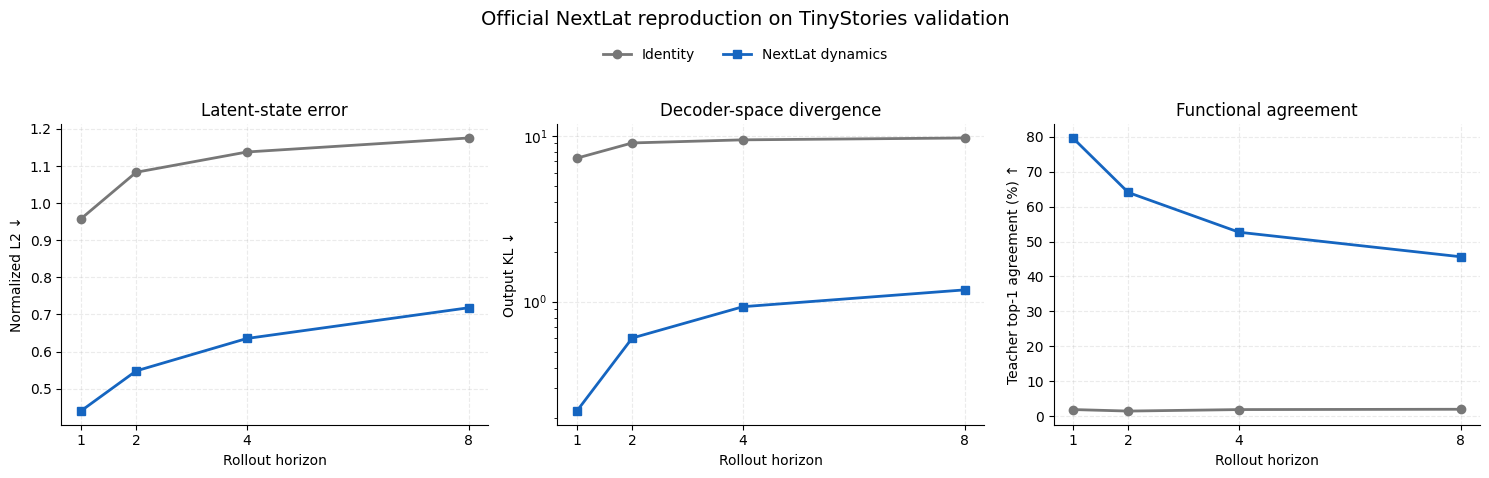

Saved PNG: /content/drive/MyDrive/ma2288_nextlat/research_v3/results/figures/nextlat_recursive_validation_seed42.png
Saved PDF: /content/drive/MyDrive/ma2288_nextlat/research_v3/results/figures/nextlat_recursive_validation_seed42.pdf


In [26]:
# Cell 72 — Create final Notebook 21 validation figure

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

V3_ROOT = Path(
    "/content/drive/MyDrive/ma2288_nextlat/research_v3"
)
V3_FIGURES_DIR = V3_ROOT / "results" / "figures"
V3_METADATA_DIR = V3_ROOT / "results" / "metadata"

V3_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
V3_METADATA_DIR.mkdir(parents=True, exist_ok=True)

plot_df = full_validation_df.copy()

identity_df = (
    plot_df[plot_df["method"] == "Identity"]
    .sort_values("horizon")
)

nextlat_df = (
    plot_df[plot_df["method"] == "NextLat dynamics"]
    .sort_values("horizon")
)

figure, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.3),
)

colors = {
    "Identity": "#777777",
    "NextLat dynamics": "#1565C0",
}

markers = {
    "Identity": "o",
    "NextLat dynamics": "s",
}

for method, method_df in plot_df.groupby("method"):
    method_df = method_df.sort_values("horizon")

    axes[0].plot(
        method_df["horizon"],
        method_df["normalized_l2"],
        marker=markers[method],
        linewidth=2,
        markersize=6,
        color=colors[method],
        label=method,
    )

    axes[1].plot(
        method_df["horizon"],
        method_df["output_kl"],
        marker=markers[method],
        linewidth=2,
        markersize=6,
        color=colors[method],
        label=method,
    )

    axes[2].plot(
        method_df["horizon"],
        100.0
        * method_df["top1_teacher_agreement"],
        marker=markers[method],
        linewidth=2,
        markersize=6,
        color=colors[method],
        label=method,
    )

axes[0].set_title("Latent-state error")
axes[0].set_ylabel("Normalized L2 ↓")

axes[1].set_title("Decoder-space divergence")
axes[1].set_ylabel("Output KL ↓")
axes[1].set_yscale("log")

axes[2].set_title("Functional agreement")
axes[2].set_ylabel("Teacher top-1 agreement (%) ↑")

for axis in axes:
    axis.set_xlabel("Rollout horizon")
    axis.set_xticks(horizons)
    axis.grid(
        True,
        alpha=0.25,
        linestyle="--",
    )
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()

figure.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 1.04),
)

figure.suptitle(
    "Official NextLat reproduction on TinyStories validation",
    fontsize=14,
    y=1.10,
)

figure.tight_layout()

figure_png_path = (
    V3_FIGURES_DIR
    / "nextlat_recursive_validation_seed42.png"
)

figure_pdf_path = (
    V3_FIGURES_DIR
    / "nextlat_recursive_validation_seed42.pdf"
)

figure.savefig(
    figure_png_path,
    dpi=200,
    bbox_inches="tight",
)

figure.savefig(
    figure_pdf_path,
    bbox_inches="tight",
)

plt.show()

print("Saved PNG:", figure_png_path)
print("Saved PDF:", figure_pdf_path)

In [28]:
# Cell 73 — Save final Notebook 21 research summary

notebook21_summary = {
    "experiment": "faithful_nextlat_reproduction",
    "official_repository": (
        "https://github.com/JaydenTeoh/NextLat"
    ),
    "official_commit": (
        "3770be6009cea2b3c455a9ce7f2ca88b504bb955"
    ),
    "dataset": "cyrilzhang/TinyStories2-ascii",
    "evaluation_split": "validation",
    "independent_test_split": False,
    "seed": 42,
    "training": {
        "steps": 5000,
        "tokens_per_model": 81920000,
        "sequence_length": 256,
        "effective_batch_size": 64,
        "precision": "bf16-mixed",
        "gpu": torch.cuda.get_device_name(0),
        "gpt_elapsed_minutes": 6.922993082216673,
        "nextlat_elapsed_minutes": 8.19673719878333,
    },
    "model": {
        "layers": 4,
        "heads": 4,
        "hidden_dimension": 256,
        "vocabulary_size": 1000,
        "nextlat_training_horizon": 1,
    },
    "language_modeling": {
        "gpt_validation_next_token_loss":
            1.5551316738128662,
        "gpt_validation_perplexity":
            4.735710053106693,
        "nextlat_validation_next_token_loss":
            1.6254814863204956,
        "nextlat_validation_perplexity":
            5.080864815233316,
        "nextlat_minus_gpt_next_token_loss":
            0.0703498125076294,
    },
    "recursive_validation": (
        full_validation_df.to_dict(
            orient="records"
        )
    ),
    "improvement_over_identity": (
        full_validation_improvement_df.to_dict(
            orient="records"
        )
    ),
    "bootstrap": (
        paired_bootstrap_df.to_dict(
            orient="records"
        )
    ),
    "main_finding": (
        "Jointly trained NextLat representations remain "
        "substantially more predictable than an identity "
        "transition through horizon 8, despite training with "
        "mtp_horizon=1."
    ),
    "interpretation": (
        "The result supports the hypothesis that joint training "
        "shapes a more predictable latent space, contrasting "
        "with the weak accepted-prefix gains observed in the "
        "earlier frozen post-hoc DistilGPT-2 experiments."
    ),
    "limitations": [
        "single training seed",
        "single small model scale",
        "TinyStories validation only",
        "no independent TinyStories test split",
        "identity transition is not a strong learned baseline",
        "teacher-token-conditioned rollout",
        "no end-to-end decoding speed measurement",
    ],
    "next_experiment": {
        "notebook": (
            "22_train_multihorizon_nextlat.ipynb"
        ),
        "comparison": (
            "matched mtp_horizon=1 versus mtp_horizon=8"
        ),
        "primary_question": (
            "Does explicit multi-step joint training improve "
            "long-horizon functional quality without an "
            "unacceptable next-token perplexity or training-cost "
            "penalty?"
        ),
    },
}

notebook21_summary_path = (
    V3_METADATA_DIR
    / "notebook21_final_summary_seed42.json"
)

with open(
    notebook21_summary_path,
    "w",
    encoding="utf-8",
) as summary_file:
    json.dump(
        notebook21_summary,
        summary_file,
        indent=2,
    )

print("=" * 110)
print("NOTEBOOK 21 FINAL SUMMARY")
print("=" * 110)

print("Main finding:")
print(notebook21_summary["main_finding"])

print("\nInterpretation:")
print(notebook21_summary["interpretation"])

print("\nLimitations:")
for limitation in notebook21_summary["limitations"]:
    print("-", limitation)

print("\nNext experiment:")
print(
    notebook21_summary[
        "next_experiment"
    ]["comparison"]
)

print("\nSaved:", notebook21_summary_path)

assert notebook21_summary_path.exists()
assert figure_png_path.exists()
assert figure_pdf_path.exists()

print("\nNOTEBOOK 21 COMPLETE.")

NOTEBOOK 21 FINAL SUMMARY
Main finding:
Jointly trained NextLat representations remain substantially more predictable than an identity transition through horizon 8, despite training with mtp_horizon=1.

Interpretation:
The result supports the hypothesis that joint training shapes a more predictable latent space, contrasting with the weak accepted-prefix gains observed in the earlier frozen post-hoc DistilGPT-2 experiments.

Limitations:
- single training seed
- single small model scale
- TinyStories validation only
- no independent TinyStories test split
- identity transition is not a strong learned baseline
- teacher-token-conditioned rollout
- no end-to-end decoding speed measurement

Next experiment:
matched mtp_horizon=1 versus mtp_horizon=8

Saved: /content/drive/MyDrive/ma2288_nextlat/research_v3/results/metadata/notebook21_final_summary_seed42.json

NOTEBOOK 21 COMPLETE.
